# Vehicle Type Classification Project

This project aims to classify vehicle types (CAR, LCV, HCV, BUS) using machine learning based on trip characteristics, road types, speed patterns, and acceleration data.


## 1. Import Libraries

Import necessary libraries for data processing, machine learning, and visualization.


In [ ]:
import pandas as pd
import numpy as np
from shapely import wkt
import shap
import ast
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.metrics import classification_report, f1_score, confusion_matrix, make_scorer, accuracy_score
import xgboost as xgb
from xgboost import XGBClassifier
from xgboost import plot_importance
from skopt import BayesSearchCV
from skopt.space import Real, Integer
from sklearn.model_selection import train_test_split
from google.colab import drive
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 107.8/107.8 kB 3.4 MB/s eta 0:00:00


## 2. Load Data from Multiple Groups

Load datasets from different groups that contain various features:
- **Group 6**: Density, turns, rush hour information
- **Group 3**: Road type percentages, speed metrics, trip duration
- **Group 2**: Summary statistics
- **Group 5**: Geospatial features (bounding box, straightness, sinuosity)
- **Group 7**: Acceleration features (X and Y axis statistics)


In [ ]:
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
df_6 = pd.read_csv('/content/drive/MyDrive/DATA3001 Modelling/vehicle_data_final_group6.csv')

In [ ]:
# Group 3
df_3 = pd.read_csv('/content/drive/MyDrive/DATA3001 Modelling/vehicle_data_cleaned_group3.csv')

In [ ]:
# Group 5: Only geopspatial because previous data products already have the rest
df_5 = pd.read_csv('/content/drive/MyDrive/DATA3001 Modelling/Group5_total_data.csv')

In [ ]:
df_7 = pd.read_csv('/content/drive/MyDrive/DATA3001 Modelling/Group-7-TripFeatures_Summary.csv')

## 3. Data Merging and Feature Selection

Merge all datasets on `TripID` and select important features:
- **Road features**: Percentages of different road types (motorway, trunk, primary, etc.)
- **Speed features**: Maximum, average, median, 85th percentile, and range
- **Trip features**: Duration, distance, density, number of turns
- **Geospatial features**: Bounding box area, straightness, sinuosity
- **Acceleration features**: X and Y axis acceleration statistics

After merging, we filter out missing values and remove motorcycle class, keeping only CAR, LCV, HCV, and BUS.


## 4. Data Preprocessing

- **Label Encoding**: Convert vehicle type classes to numerical labels
- **Train-Test Split**: 80/20 split with stratification to maintain class distribution
- **Feature Scaling**: Standardize all numerical features using StandardScaler to ensure all features are on the same scale


In [ ]:
# Merge important features into one table
df_3_filtered = df_3[['TripID', 'VehicleType_class', 'pct_motorway', 'pct_trunk',
                      'pct_primary', 'pct_secondary', 'pct_residential', 'pct_service',
                      'SpeedMax', 'SpeedAvg', 'SpeedMedian', 'trip_duration_sec',
                      'TravelDistance_m']].copy()

df_6_filtered = df_6[['TripID', 'Density', 'Turns', 'RushHourFlag']].copy()

df_5_filtered = df_5[['TripID', 'bbox_area_m2', 'straightness', 'sinuosity', 'Speed85P',
                      'speed_range',
                      ]].copy()

df_7_filtered = df_7[['TripID', 'X_AccMax', 'X_AccMin', 'X_MeanAcc', 'X_StdAcc',
                      'Y_AccMax','Y_AccMin', 'Y_MeanAcc',
                      'Y_StdAcc', 'StdAcc_Total']].copy()

df = pd.merge(df_3_filtered, df_6_filtered, on='TripID', how='inner')
df = pd.merge(df, df_5_filtered, on='TripID', how='inner')
df = pd.merge(df, df_7_filtered, on='TripID', how='inner')


# Remove TripID as not used for modelling
df = df[df['VehicleType_class'].notna()]
df = df[df['pct_motorway'].notna()]

df = df.drop(columns=['TripID'])

# Drop motorbike
df = df[df['VehicleType_class'].isin(['CAR', 'LCV', 'HCV', 'BUS'])].copy()
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 43634 entries, 0 to 45337
Data columns (total 29 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   VehicleType_class  43634 non-null  object 
 1   pct_motorway       43634 non-null  float64
 2   pct_trunk          43634 non-null  float64
 3   pct_primary        43634 non-null  float64
 4   pct_secondary      43634 non-null  float64
 5   pct_residential    43634 non-null  float64
 6   pct_service        43634 non-null  float64
 7   SpeedMax           43634 non-null  float64
 8   SpeedAvg           43634 non-null  float64
 9   SpeedMedian        43634 non-null  float64
 10  trip_duration_sec  43634 non-null  float64
 11  TravelDistance_m   43634 non-null  float64
 12  Density            43634 non-null  float64
 13  Turns              43634 non-null  int64  
 14  RushHourFlag       43634 non-null  int64  
 15  bbox_area_m2       43634 non-null  float64
 16  straightness       43634 no

## 5. Model Configuration

Configure XGBoost classifier with optimized hyperparameters:
- **Learning rate**: 0.2
- **Max depth**: 3 (prevents overfitting)
- **N estimators**: 900 trees
- **Regularization**: Alpha and lambda for L1 and L2 regularization
- **Subsampling**: 0.71 for rows, 0.84 for columns

The model uses macro F1 score as the evaluation metric to handle class imbalance.


In [ ]:
#create train-test split with encoder for vehicletype_class
X = df.drop(columns=['VehicleType_class'])
y = df['VehicleType_class']

labelEncoder = LabelEncoder()
y = labelEncoder.fit_transform(y)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=8)

# Scaler numerical features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)


## 6. Model Training

Train the XGBoost classifier on the training data.


In [ ]:
best_parameters = {
    'booster': 'gbtree',
    'learning_rate': 0.2,
    'max_depth': 3,
    'min_child_weight': 6,
    'subsample': 0.71,
    'colsample_bytree': 0.84,
    'gamma': 0.5,
    'reg_alpha': 0.012,
    'reg_lambda': 1.23,
    'n_estimators': 900
}

#f1_score for scoring the model
f1_macro = make_scorer(f1_score, average='macro')

# pipeline.set_params(**best_parameters)
opt = XGBClassifier(**best_parameters)

## 7. Model Evaluation

Evaluate the model performance on both test and training sets:
- **Test Accuracy**: 82.53%
- **Test Macro F1**: 62.39%

**Key Observations**:
- HCV (Heavy Commercial Vehicle) performs best with F1 score of 0.92
- BUS performs well with F1 score of 0.75
- LCV has moderate performance (F1: 0.64)
- CAR is the most challenging class (F1: 0.18), often confused with LCV


In [ ]:
opt.fit(X_train, y_train)

XGBClassifier(base_score=None, booster='gbtree', callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.84, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=0.5, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.2, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=3,
              max_leaves=None, min_child_weight=6, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=900,
              n_jobs=None, num_parallel_tree=None, ...)

## 8. Confusion Matrix

Visualize the confusion matrix to understand classification errors:
- Rows represent true labels
- Columns represent predicted labels
- Diagonal values show correct predictions
- Off-diagonal values show misclassifications

The confusion matrix reveals that CAR is frequently misclassified as LCV, which is expected as these vehicle types share similar characteristics.


In [ ]:
y_pred = opt.predict(X_test)
y_train_pred = opt.predict(X_train)

print("\n" + "="*80)
print("XGBoost 4-Class Model - Test Set")
print("="*80)
print(classification_report(y_test, y_pred, target_names=labelEncoder.classes_))
test_accuracy = accuracy_score(y_test, y_pred)
test_f1 = f1_score(y_test, y_pred, average='macro')
print(f"Test Accuracy: {test_accuracy:.4f}")
print(f"Test Macro F1 Score: {test_f1:.4f}")

print("\n" + "="*80)
print("XGBoost 4-Class Model - Train Set")
print("="*80)
print(classification_report(y_train, y_train_pred, target_names=labelEncoder.classes_))
train_accuracy = accuracy_score(y_train, y_train_pred)
train_f1 = f1_score(y_train, y_train_pred, average='macro')
print(f"Train Accuracy: {train_accuracy:.4f}")
print(f"Train Macro F1 Score: {train_f1:.4f}")


XGBoost 4-Class Model - Test Set
              precision    recall  f1-score   support

         BUS       0.88      0.68      0.76       257
         CAR       0.37      0.11      0.17       607
         HCV       0.89      0.95      0.92      6162
         LCV       0.63      0.67      0.65      1701

    accuracy                           0.83      8727
   macro avg       0.69      0.60      0.63      8727
weighted avg       0.81      0.83      0.81      8727

Test Accuracy: 0.8272
Test Macro F1 Score: 0.6265

XGBoost 4-Class Model - Train Set
              precision    recall  f1-score   support

         BUS       0.99      0.92      0.95      1030
         CAR       0.97      0.53      0.68      2427
         HCV       0.94      0.98      0.96     24646
         LCV       0.82      0.84      0.83      6804

    accuracy                           0.92     34907
   macro avg       0.93      0.81      0.85     34907
weighted avg       0.92      0.92      0.91     34907

Train Accur

## 9. Feature Engineering for CAR vs LCV Analysis

Create derived features to better distinguish between CAR and LCV:
- **Highway/Urban Ratio**: Ratio of highway roads to urban roads
- **Turns per km**: Number of turns normalized by distance
- **Acceleration features**: Used as proxy for driving patterns

These features help identify differences in driving behavior between passenger cars and light commercial vehicles.


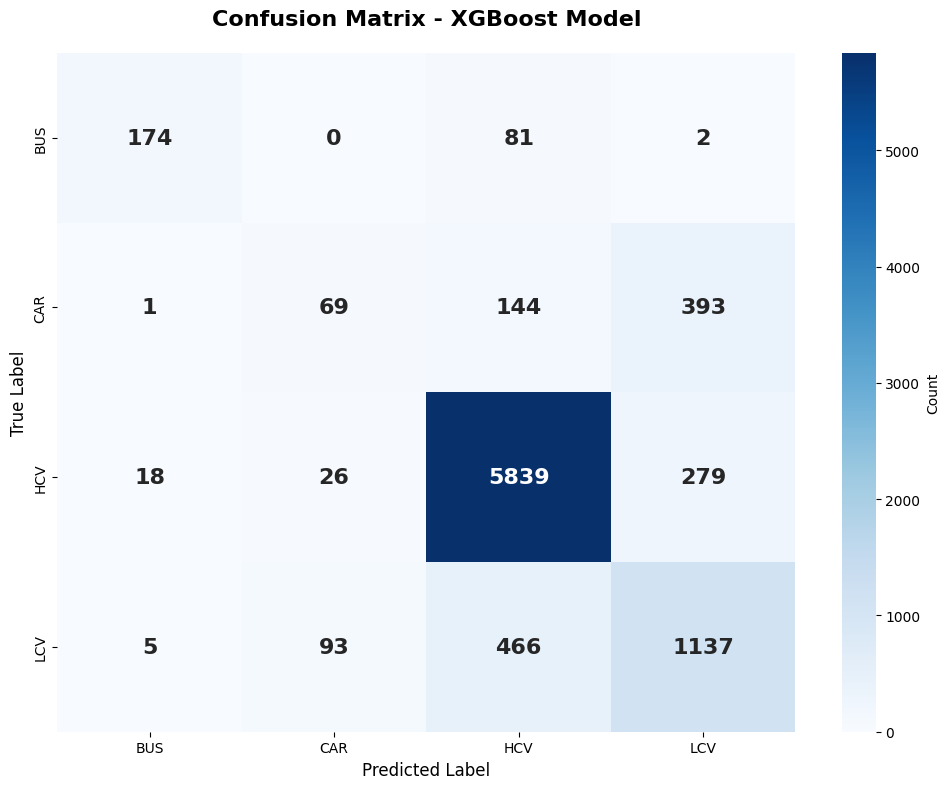


Confusion Matrix (rows=true, cols=predicted):
     BUS  CAR   HCV   LCV
BUS  174    0    81     2
CAR    1   69   144   393
HCV   18   26  5839   279
LCV    5   93   466  1137


In [ ]:
# Confusion Matrix Visualization
cm = confusion_matrix(y_test, y_pred)
labels = labelEncoder.classes_

# Create confusion matrix heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=labels, yticklabels=labels,
            cbar_kws={'label': 'Count'},
            annot_kws={'size': 16, 'weight': 'bold'})  # Increase font size and make bold
plt.title('Confusion Matrix - XGBoost Model', fontsize=16, fontweight='bold', pad=20)
plt.ylabel('True Label', fontsize=12)
plt.xlabel('Predicted Label', fontsize=12)
plt.tight_layout()
plt.show()

# Print confusion matrix as DataFrame
cm_df = pd.DataFrame(cm, index=labels, columns=labels)
print("\nConfusion Matrix (rows=true, cols=predicted):")
print(cm_df)

CAR samples: 3034
LCV samples: 8505
Total samples for pair plot: 11539

Sampling to 5000 samples for visualization...


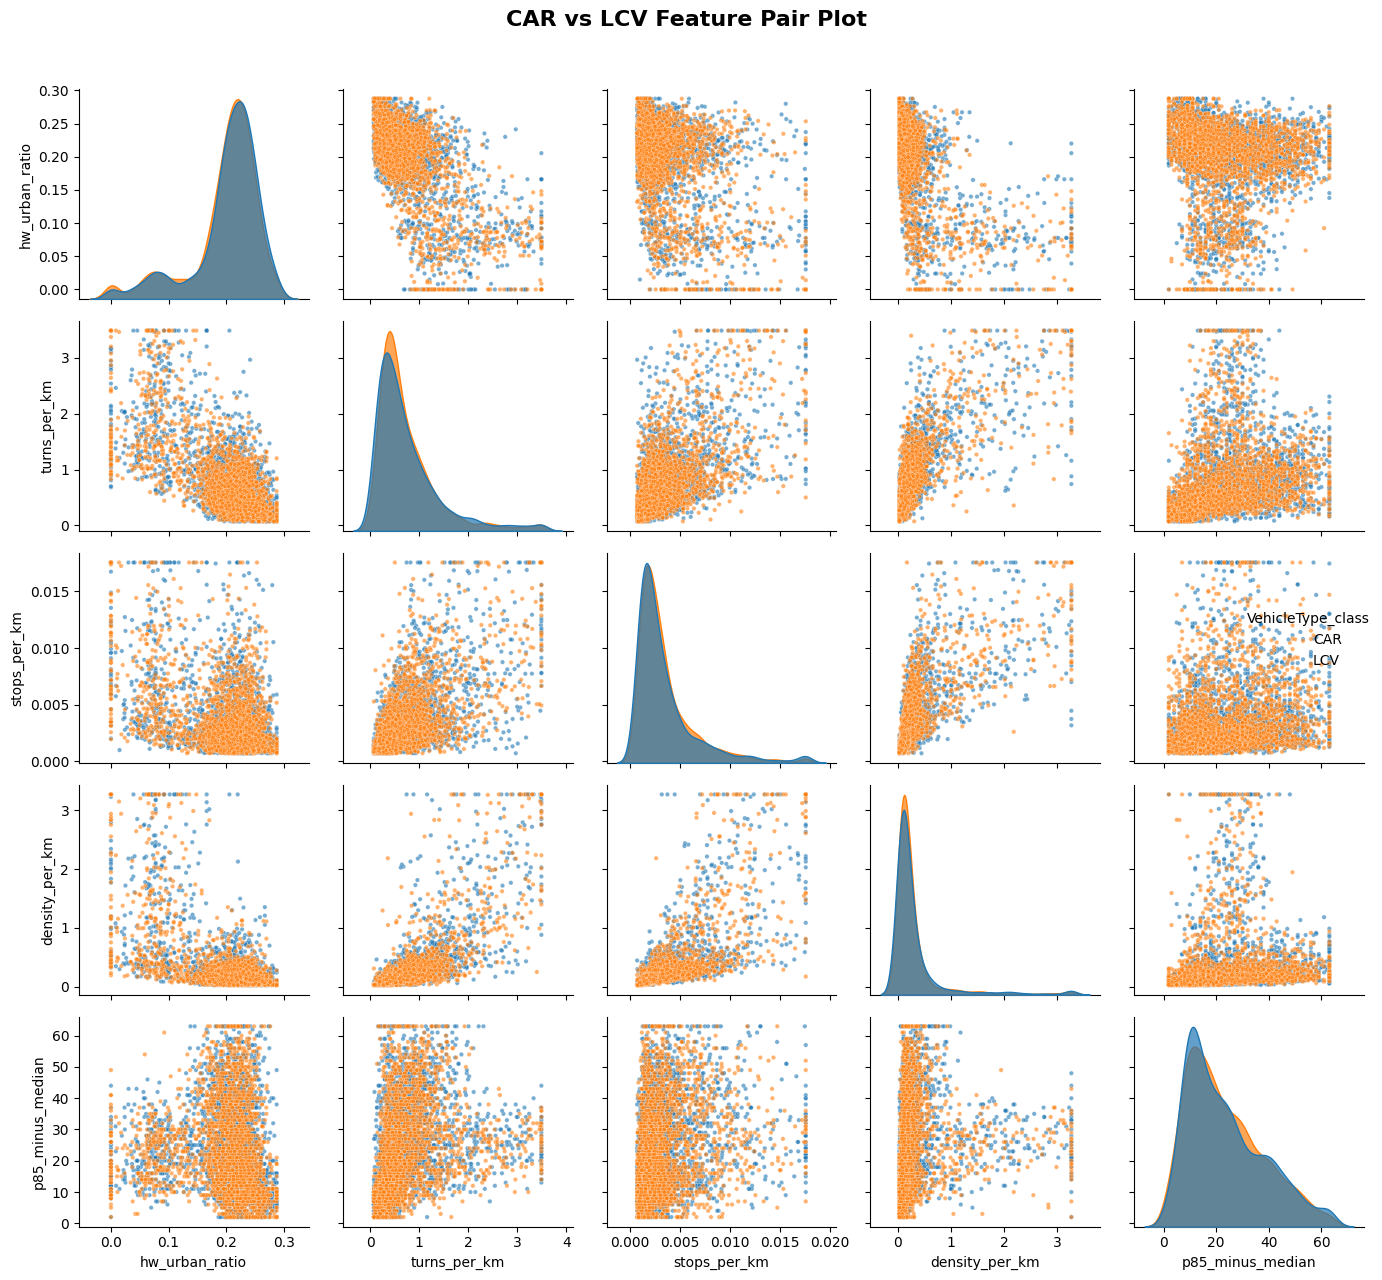


Summary Statistics for Pair Plot Features

CAR Statistics:
       hw_urban_ratio  turns_per_km  stops_per_km  density_per_km  \
count     3034.000000   3034.000000   3034.000000     3034.000000   
mean         0.200905      0.756336      0.003494        0.314393   
std          0.058642      0.680107      0.003252        0.552106   
min          0.000000      0.074346      0.000723        0.024614   
25%          0.187518      0.295894      0.001458        0.070665   
50%          0.214719      0.548004      0.002371        0.130179   
75%          0.237845      0.961858      0.004115        0.280777   
max          0.287529      3.488745      0.017553        3.269240   

       p85_minus_median  
count       3034.000000  
mean          23.499670  
std           14.739976  
min            2.000000  
25%           11.000000  
50%           20.000000  
75%           33.000000  
max           63.000000  

LCV Statistics:
       hw_urban_ratio  turns_per_km  stops_per_km  density_per_km  

In [ ]:
# CAR vs LCV Pair Plot (Similar to the reference image)

# Extract CAR and LCV data
df_car_lcv = df[df['VehicleType_class'].isin(['CAR', 'LCV'])].copy()

# Create derived features similar to the reference image
# 1. Highway/Urban Ratioz
df_car_lcv['hw_urban_ratio'] = (df_car_lcv['pct_motorway'] + df_car_lcv['pct_trunk'] + df_car_lcv['pct_primary']) / \
                                (df_car_lcv['pct_motorway'] + df_car_lcv['pct_trunk'] + df_car_lcv['pct_primary'] +
                                 df_car_lcv['pct_residential'] + df_car_lcv['pct_service'] + 1e-6)  # Add small epsilon to avoid division by zero

# 2. Turns per km
df_car_lcv['turns_per_km'] = df_car_lcv['Turns'] / (df_car_lcv['TravelDistance_m'] / 1000 + 1e-6)

# 3. Stops per km (using acceleration changes as proxy - negative acceleration indicates stopping)
# Alternative: use sinuosity or other features, or create from acceleration data
# For now, we'll use a combination of acceleration features as a proxy
df_car_lcv['stops_per_km'] = (df_car_lcv['X_AccMin'].abs() + df_car_lcv['Y_AccMin'].abs()) / (df_car_lcv['TravelDistance_m'] / 1000 + 1e-6) / 10
# Alternative: if you have actual stop data, use that instead

# 4. Density per km
df_car_lcv['density_per_km'] = df_car_lcv['Density'] / (df_car_lcv['TravelDistance_m'] / 1000 + 1e-6)

# 5. P85 minus Median (Speed85P - SpeedMedian)
df_car_lcv['p85_minus_median'] = df_car_lcv['Speed85P'] - df_car_lcv['SpeedMedian']

# Select features for pair plot
pair_features = ['hw_urban_ratio', 'turns_per_km', 'stops_per_km', 'density_per_km', 'p85_minus_median']

# Create a subset dataframe with only CAR and LCV and selected features
df_pair = df_car_lcv[['VehicleType_class'] + pair_features].copy()

# Remove infinite and very large values
for col in pair_features:
    df_pair[col] = df_pair[col].replace([np.inf, -np.inf], np.nan)
    # Cap extreme values at 99th percentile
    q99 = df_pair[col].quantile(0.99)
    q01 = df_pair[col].quantile(0.01)
    df_pair[col] = df_pair[col].clip(lower=q01, upper=q99)

# Drop rows with NaN values
df_pair = df_pair.dropna()

print(f"CAR samples: {len(df_pair[df_pair['VehicleType_class'] == 'CAR'])}")
print(f"LCV samples: {len(df_pair[df_pair['VehicleType_class'] == 'LCV'])}")
print(f"Total samples for pair plot: {len(df_pair)}")

# Create pair plot using seaborn
# Use a sample if dataset is too large for better visualization
if len(df_pair) > 5000:
    df_pair_sample = pd.concat([
        df_pair[df_pair['VehicleType_class'] == 'CAR'].sample(n=min(2500, len(df_pair[df_pair['VehicleType_class'] == 'CAR'])), random_state=42),
        df_pair[df_pair['VehicleType_class'] == 'LCV'].sample(n=min(2500, len(df_pair[df_pair['VehicleType_class'] == 'LCV'])), random_state=42)
    ])
    print(f"\nSampling to {len(df_pair_sample)} samples for visualization...")
else:
    df_pair_sample = df_pair.copy()

# Create pair plot
g = sns.pairplot(df_pair_sample,
                 vars=pair_features,
                 hue='VehicleType_class',
                 diag_kind='kde',  # Use KDE for diagonal plots
                 plot_kws={'alpha': 0.6, 's': 10},  # Transparency and point size
                 diag_kws={'alpha': 0.7, 'fill': True},  # Fill KDE plots
                 palette={'CAR': '#1f77b4', 'LCV': '#ff7f0e'},  # Blue for CAR, Orange for LCV
                 height=2.5,
                 aspect=1)

# Customize the plot
g.fig.suptitle('CAR vs LCV Feature Pair Plot', fontsize=16, fontweight='bold', y=1.02)

# Adjust layout
plt.tight_layout()
plt.show()

# Print summary statistics
print("\n" + "="*80)
print("Summary Statistics for Pair Plot Features")
print("="*80)
print("\nCAR Statistics:")
print(df_pair[df_pair['VehicleType_class'] == 'CAR'][pair_features].describe())
print("\nLCV Statistics:")
print(df_pair[df_pair['VehicleType_class'] == 'LCV'][pair_features].describe())


In [ ]:
# Cross validation for XGBoost 4-Class Model
print("="*80)
print("XGBoost 4-Class Model - 5-Fold Cross Validation")
print("="*80)

# F1 Macro Score CV
cv_scores_f1 = cross_val_score(opt, X, y, cv=5, scoring=f1_macro)
print(f"\nF1 Macro scores for each fold: {cv_scores_f1}")
print(f"Mean F1 Macro score: {np.mean(cv_scores_f1):.4f} ± {np.std(cv_scores_f1):.4f}")

# Accuracy CV
cv_scores_acc = cross_val_score(opt, X, y, cv=5, scoring='accuracy')
print(f"\nAccuracy scores for each fold: {cv_scores_acc}")
print(f"Mean Accuracy: {np.mean(cv_scores_acc):.4f} ± {np.std(cv_scores_acc):.4f}")

XGBoost 4-Class Model - 5-Fold Cross Validation

F1 Macro scores for each fold: [0.61953992 0.64179759 0.62099161 0.61243421 0.62684624]
Mean F1 Macro score: 0.6243 ± 0.0099

Accuracy scores for each fold: [0.82651541 0.83339063 0.8257133  0.82193194 0.82764153]
Mean Accuracy: 0.8270 ± 0.0037


In [ ]:
# Create a copy of the merged dataframe for 3-class classification
df_3class = df.copy()

# Merge CAR and LCV into a single class called 'CAR_LCV'
df_3class['VehicleType_class'] = df_3class['VehicleType_class'].replace({'CAR': 'CAR_LCV', 'LCV': 'CAR_LCV'})

print("Vehicle type distribution after merging CAR and LCV:")
print(df_3class['VehicleType_class'].value_counts())
print(f"\nTotal samples: {len(df_3class)}")
print(f"\nNumber of classes: {df_3class['VehicleType_class'].nunique()}")
print(f"\nClasses: {df_3class['VehicleType_class'].unique()}")
df_3class.info()


Vehicle type distribution after merging CAR and LCV:
VehicleType_class
HCV        30808
CAR_LCV    11539
BUS         1287
Name: count, dtype: int64

Total samples: 43634

Number of classes: 3

Classes: ['HCV' 'CAR_LCV' 'BUS']
<class 'pandas.core.frame.DataFrame'>
Index: 43634 entries, 0 to 45337
Data columns (total 29 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   VehicleType_class  43634 non-null  object 
 1   pct_motorway       43634 non-null  float64
 2   pct_trunk          43634 non-null  float64
 3   pct_primary        43634 non-null  float64
 4   pct_secondary      43634 non-null  float64
 5   pct_residential    43634 non-null  float64
 6   pct_service        43634 non-null  float64
 7   SpeedMax           43634 non-null  float64
 8   SpeedAvg           43634 non-null  float64
 9   SpeedMedian        43634 non-null  float64
 10  trip_duration_sec  43634 non-null  float64
 11  TravelDistance_m   43634 non-null  float6

In [ ]:
# Prepare data for 3-class XGBoost model
X_3class = df_3class.drop(columns=['VehicleType_class'])
y_3class = df_3class['VehicleType_class']

# Encode labels for 3 classes
labelEncoder_3class = LabelEncoder()
y_3class_encoded = labelEncoder_3class.fit_transform(y_3class)

print("Class mapping:")
for i, class_name in enumerate(labelEncoder_3class.classes_):
    print(f"  {i}: {class_name}")

# Create train-test split with stratification
X_train_3class, X_test_3class, y_train_3class, y_test_3class = train_test_split(
    X_3class, y_3class_encoded, test_size=0.2, stratify=y_3class_encoded, random_state=8
)

print(f"\nTraining set size: {len(X_train_3class)}")
print(f"Test set size: {len(X_test_3class)}")
print(f"\nTraining set class distribution:")
unique, counts = np.unique(y_train_3class, return_counts=True)
for u, c in zip(unique, counts):
    print(f"  {labelEncoder_3class.classes_[u]}: {c}")

# Scale numerical features
scaler_3class = StandardScaler()
X_train_3class_scaled = scaler_3class.fit_transform(X_train_3class)
X_test_3class_scaled = scaler_3class.transform(X_test_3class)


Class mapping:
  0: BUS
  1: CAR_LCV
  2: HCV

Training set size: 34907
Test set size: 8727

Training set class distribution:
  BUS: 1030
  CAR_LCV: 9231
  HCV: 24646


In [ ]:
# XGBoost parameters for 3-class classification
best_parameters_3class = {
    'booster': 'gbtree',
    'learning_rate': 0.2,
    'max_depth': 3,
    'min_child_weight': 6,
    'subsample': 0.71,
    'colsample_bytree': 0.84,
    'gamma': 0.5,
    'reg_alpha': 0.012,
    'reg_lambda': 1.23,
    'n_estimators': 900,
    'objective': 'multi:softprob',  # Multi-class classification
    'eval_metric': 'mlogloss'  # Multi-class log loss
}

# Create XGBoost classifier for 3-class classification
opt_3class = XGBClassifier(**best_parameters_3class)

# Train the model
opt_3class.fit(X_train_3class_scaled, y_train_3class)
print("3-class XGBoost model trained successfully!")


3-class XGBoost model trained successfully!


In [ ]:
# Make predictions
y_pred_3class = opt_3class.predict(X_test_3class_scaled)
y_train_pred_3class = opt_3class.predict(X_train_3class_scaled)

# Classification reports
print("="*80)
print("3-Class XGBoost Model (CAR+LCV merged) - Test Set")
print("="*80)
print(classification_report(y_test_3class, y_pred_3class, target_names=labelEncoder_3class.classes_))
test_accuracy_3class = accuracy_score(y_test_3class, y_pred_3class)
test_f1_3class = f1_score(y_test_3class, y_pred_3class, average='macro')
print(f"Test Accuracy: {test_accuracy_3class:.4f}")
print(f"Test Macro F1 Score: {test_f1_3class:.4f}")

print("\n" + "="*80)
print("3-Class XGBoost Model (CAR+LCV merged) - Train Set")
print("="*80)
print(classification_report(y_train_3class, y_train_pred_3class, target_names=labelEncoder_3class.classes_))
train_accuracy_3class = accuracy_score(y_train_3class, y_train_pred_3class)
train_f1_3class = f1_score(y_train_3class, y_train_pred_3class, average='macro')
print(f"Train Accuracy: {train_accuracy_3class:.4f}")
print(f"Train Macro F1 Score: {train_f1_3class:.4f}")


3-Class XGBoost Model (CAR+LCV merged) - Test Set
              precision    recall  f1-score   support

         BUS       0.88      0.68      0.77       257
     CAR_LCV       0.83      0.76      0.80      2308
         HCV       0.90      0.94      0.92      6162

    accuracy                           0.89      8727
   macro avg       0.87      0.79      0.83      8727
weighted avg       0.88      0.89      0.88      8727

Test Accuracy: 0.8853
Test Macro F1 Score: 0.8286

3-Class XGBoost Model (CAR+LCV merged) - Train Set
              precision    recall  f1-score   support

         BUS       0.99      0.91      0.94      1030
     CAR_LCV       0.92      0.87      0.90      9231
         HCV       0.95      0.97      0.96     24646

    accuracy                           0.94     34907
   macro avg       0.95      0.92      0.93     34907
weighted avg       0.94      0.94      0.94     34907

Train Accuracy: 0.9429
Train Macro F1 Score: 0.9330


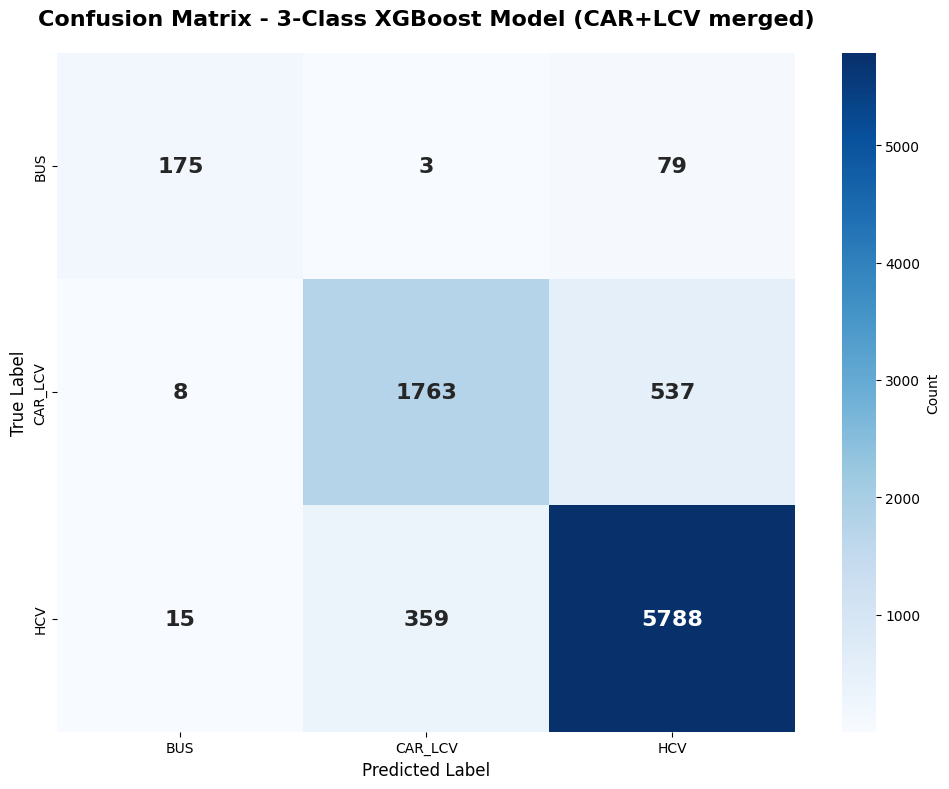


Confusion Matrix (rows=true, cols=predicted):
         BUS  CAR_LCV   HCV
BUS      175        3    79
CAR_LCV    8     1763   537
HCV       15      359  5788


In [ ]:
# Confusion Matrix Visualization for 3-class model
cm_3class = confusion_matrix(y_test_3class, y_pred_3class)
labels_3class = labelEncoder_3class.classes_

# Create confusion matrix heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(cm_3class, annot=True, fmt='d', cmap='Blues',
            xticklabels=labels_3class, yticklabels=labels_3class,
            cbar_kws={'label': 'Count'},
            annot_kws={'size': 16, 'weight': 'bold'})
plt.title('Confusion Matrix - 3-Class XGBoost Model (CAR+LCV merged)',
          fontsize=16, fontweight='bold', pad=20)
plt.ylabel('True Label', fontsize=12)
plt.xlabel('Predicted Label', fontsize=12)
plt.tight_layout()
plt.show()

# Print confusion matrix as DataFrame
cm_df_3class = pd.DataFrame(cm_3class, index=labels_3class, columns=labels_3class)
print("\nConfusion Matrix (rows=true, cols=predicted):")
print(cm_df_3class)


In [ ]:
# Cross validation for 3-class model
print("="*80)
print("3-Class XGBoost Model (CAR+LCV merged) - 5-Fold Cross Validation")
print("="*80)

f1_macro_3class = make_scorer(f1_score, average='macro')

# F1 Macro Score CV
cv_scores_3class_f1 = cross_val_score(opt_3class, X_3class, y_3class_encoded, cv=5, scoring=f1_macro_3class)
print(f"\nF1 Macro scores for each fold: {cv_scores_3class_f1}")
print(f"Mean F1 Macro score: {np.mean(cv_scores_3class_f1):.4f} ± {np.std(cv_scores_3class_f1):.4f}")

# Accuracy CV
cv_scores_3class_acc = cross_val_score(opt_3class, X_3class, y_3class_encoded, cv=5, scoring='accuracy')
print(f"\nAccuracy scores for each fold: {cv_scores_3class_acc}")
print(f"Mean Accuracy: {np.mean(cv_scores_3class_acc):.4f} ± {np.std(cv_scores_3class_acc):.4f}")


3-Class XGBoost Model (CAR+LCV merged) - 5-Fold Cross Validation

F1 Macro scores for each fold: [0.81822585 0.82968756 0.81788759 0.81228839 0.82309184]
Mean F1 Macro score: 0.8202 ± 0.0058

Accuracy scores for each fold: [0.88587143 0.88736106 0.87956915 0.88220465 0.88402475]
Mean Accuracy: 0.8838 ± 0.0027


In [ ]:
# ============================================================================
# Random Forest Model for 3-class classification
# ============================================================================
from sklearn.ensemble import RandomForestClassifier
# Random Forest parameters
rf_params_3class = {
    'n_estimators': 200,
    'max_depth': 15,
    'min_samples_split': 5,
    'min_samples_leaf': 2,
    'max_features': 'sqrt',
    'bootstrap': True,
    'random_state': 8,
    'n_jobs': -1,
    'class_weight': 'balanced'
}

# Create and train Random Forest classifier
rf_model_3class = RandomForestClassifier(**rf_params_3class)
print("Training Random Forest 3-class model...")
rf_model_3class.fit(X_train_3class_scaled, y_train_3class)
print("Random Forest 3-class model trained successfully!")

# Make predictions
y_pred_rf_3class = rf_model_3class.predict(X_test_3class_scaled)
y_train_pred_rf_3class = rf_model_3class.predict(X_train_3class_scaled)

# Classification reports
print("\n" + "="*80)
print("Random Forest 3-Class Model - Test Set")
print("="*80)
print(classification_report(y_test_3class, y_pred_rf_3class, target_names=labelEncoder_3class.classes_))
test_accuracy_rf_3class = accuracy_score(y_test_3class, y_pred_rf_3class)
test_f1_rf_3class = f1_score(y_test_3class, y_pred_rf_3class, average='macro')
print(f"Test Accuracy: {test_accuracy_rf_3class:.4f}")
print(f"Test Macro F1 Score: {test_f1_rf_3class:.4f}")

print("\n" + "="*80)
print("Random Forest 3-Class Model - Train Set")
print("="*80)
print(classification_report(y_train_3class, y_train_pred_rf_3class, target_names=labelEncoder_3class.classes_))
train_accuracy_rf_3class = accuracy_score(y_train_3class, y_train_pred_rf_3class)
train_f1_rf_3class = f1_score(y_train_3class, y_train_pred_rf_3class, average='macro')
print(f"Train Accuracy: {train_accuracy_rf_3class:.4f}")
print(f"Train Macro F1 Score: {train_f1_rf_3class:.4f}")


Training Random Forest 3-class model...
Random Forest 3-class model trained successfully!

Random Forest 3-Class Model - Test Set
              precision    recall  f1-score   support

         BUS       0.68      0.68      0.68       257
     CAR_LCV       0.80      0.78      0.79      2308
         HCV       0.91      0.92      0.92      6162

    accuracy                           0.88      8727
   macro avg       0.80      0.79      0.80      8727
weighted avg       0.88      0.88      0.88      8727

Test Accuracy: 0.8758
Test Macro F1 Score: 0.7952

Random Forest 3-Class Model - Train Set
              precision    recall  f1-score   support

         BUS       0.84      0.99      0.91      1030
     CAR_LCV       0.90      0.91      0.91      9231
         HCV       0.97      0.96      0.96     24646

    accuracy                           0.95     34907
   macro avg       0.90      0.95      0.93     34907
weighted avg       0.95      0.95      0.95     34907

Train Accuracy: 0

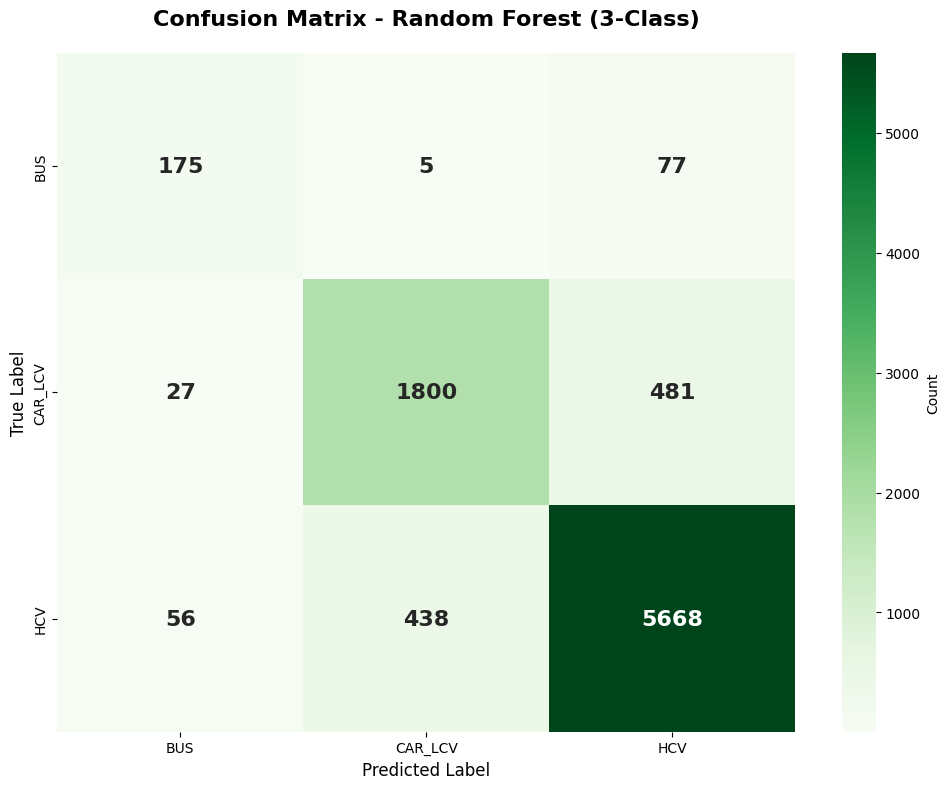


Random Forest 3-Class Confusion Matrix (rows=true, cols=predicted):
         BUS  CAR_LCV   HCV
BUS      175        5    77
CAR_LCV   27     1800   481
HCV       56      438  5668


In [ ]:
# Random Forest 3-class Confusion Matrix
cm_rf_3class = confusion_matrix(y_test_3class, y_pred_rf_3class)
labels_3class = labelEncoder_3class.classes_

# Create confusion matrix heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(cm_rf_3class, annot=True, fmt='d', cmap='Greens',
            xticklabels=labels_3class, yticklabels=labels_3class,
            cbar_kws={'label': 'Count'},
            annot_kws={'size': 16, 'weight': 'bold'})
plt.title('Confusion Matrix - Random Forest (3-Class)',
          fontsize=16, fontweight='bold', pad=20)
plt.ylabel('True Label', fontsize=12)
plt.xlabel('Predicted Label', fontsize=12)
plt.tight_layout()
plt.show()

# Print confusion matrix as DataFrame
cm_df_rf_3class = pd.DataFrame(cm_rf_3class, index=labels_3class, columns=labels_3class)
print("\nRandom Forest 3-Class Confusion Matrix (rows=true, cols=predicted):")
print(cm_df_rf_3class)


In [ ]:
# ============================================================================
# LightGBM Model for 3-class classification
# ============================================================================
import lightgbm as lgb
from lightgbm import LGBMClassifier
# LightGBM parameters
lgb_params_3class = {
    'objective': 'multiclass',
    'num_class': 3,
    'metric': 'multi_logloss',
    'boosting_type': 'gbdt',
    'num_leaves': 31,
    'learning_rate': 0.05,
    'feature_fraction': 0.8,
    'bagging_fraction': 0.8,
    'bagging_freq': 5,
    'max_depth': 7,
    'min_child_samples': 20,
    'reg_alpha': 0.1,
    'reg_lambda': 0.1,
    'random_state': 8,
    'n_jobs': -1,
    'verbosity': -1
}

# Create and train LightGBM classifier
lgb_model_3class = LGBMClassifier(**lgb_params_3class)
print("Training LightGBM 3-class model...")
lgb_model_3class.fit(
    X_train_3class_scaled,
    y_train_3class,
    eval_set=[(X_test_3class_scaled, y_test_3class)],
    callbacks=[lgb.early_stopping(stopping_rounds=50), lgb.log_evaluation(period=0)]
)
print("LightGBM 3-class model trained successfully!")
print(f"Best iteration: {lgb_model_3class.best_iteration_}")


Training LightGBM 3-class model...
Training until validation scores don't improve for 50 rounds
Did not meet early stopping. Best iteration is:
[100]	valid_0's multi_logloss: 0.319185
LightGBM 3-class model trained successfully!
Best iteration: 100


In [ ]:
# LightGBM 3-class predictions
y_pred_lgb_3class = lgb_model_3class.predict(X_test_3class_scaled)
y_train_pred_lgb_3class = lgb_model_3class.predict(X_train_3class_scaled)

# Classification reports
print("="*80)
print("LightGBM 3-Class Model - Test Set")
print("="*80)
print(classification_report(y_test_3class, y_pred_lgb_3class, target_names=labelEncoder_3class.classes_))
test_accuracy_lgb_3class = accuracy_score(y_test_3class, y_pred_lgb_3class)
test_f1_lgb_3class = f1_score(y_test_3class, y_pred_lgb_3class, average='macro')
print(f"Test Accuracy: {test_accuracy_lgb_3class:.4f}")
print(f"Test Macro F1 Score: {test_f1_lgb_3class:.4f}")

print("\n" + "="*80)
print("LightGBM 3-Class Model - Train Set")
print("="*80)
print(classification_report(y_train_3class, y_train_pred_lgb_3class, target_names=labelEncoder_3class.classes_))
train_accuracy_lgb_3class = accuracy_score(y_train_3class, y_train_pred_lgb_3class)
train_f1_lgb_3class = f1_score(y_train_3class, y_train_pred_lgb_3class, average='macro')
print(f"Train Accuracy: {train_accuracy_lgb_3class:.4f}")
print(f"Train Macro F1 Score: {train_f1_lgb_3class:.4f}")


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


LightGBM 3-Class Model - Test Set
              precision    recall  f1-score   support

         BUS       0.89      0.64      0.74       257
     CAR_LCV       0.83      0.75      0.79      2308
         HCV       0.90      0.94      0.92      6162

    accuracy                           0.88      8727
   macro avg       0.87      0.78      0.82      8727
weighted avg       0.88      0.88      0.88      8727

Test Accuracy: 0.8809
Test Macro F1 Score: 0.8162

LightGBM 3-Class Model - Train Set
              precision    recall  f1-score   support

         BUS       0.92      0.72      0.81      1030
     CAR_LCV       0.85      0.79      0.82      9231
         HCV       0.91      0.95      0.93     24646

    accuracy                           0.90     34907
   macro avg       0.90      0.82      0.85     34907
weighted avg       0.90      0.90      0.90     34907

Train Accuracy: 0.8982
Train Macro F1 Score: 0.8528


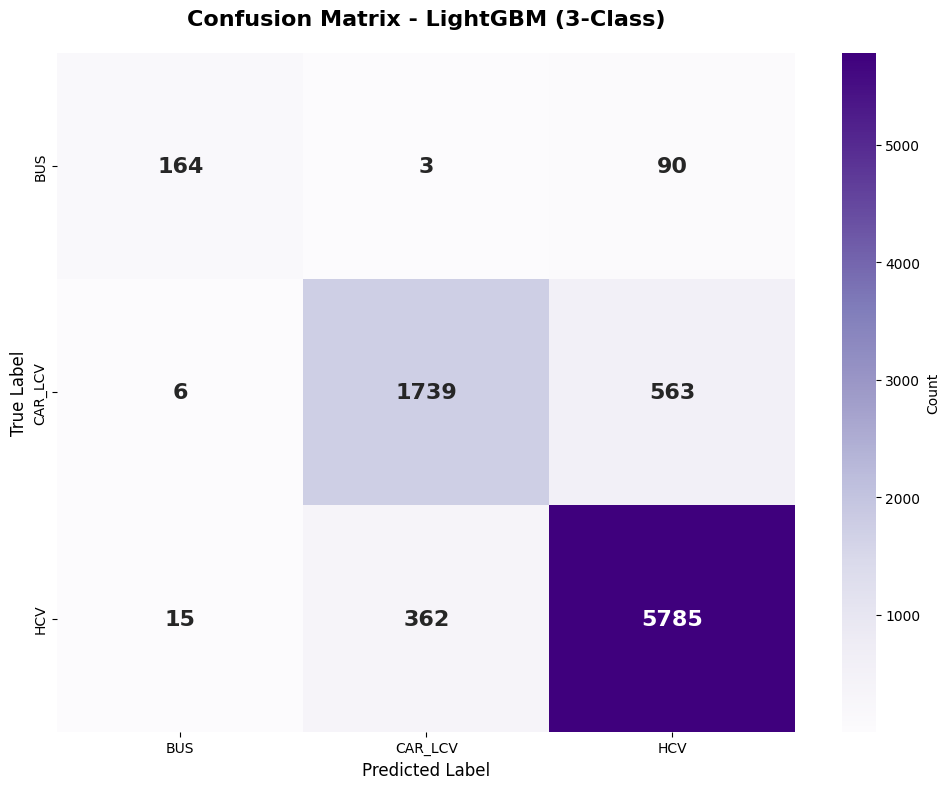


LightGBM 3-Class Confusion Matrix (rows=true, cols=predicted):
         BUS  CAR_LCV   HCV
BUS      164        3    90
CAR_LCV    6     1739   563
HCV       15      362  5785


In [ ]:
# LightGBM 3-class Confusion Matrix
cm_lgb_3class = confusion_matrix(y_test_3class, y_pred_lgb_3class)

# Create confusion matrix heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(cm_lgb_3class, annot=True, fmt='d', cmap='Purples',
            xticklabels=labels_3class, yticklabels=labels_3class,
            cbar_kws={'label': 'Count'},
            annot_kws={'size': 16, 'weight': 'bold'})
plt.title('Confusion Matrix - LightGBM (3-Class)',
          fontsize=16, fontweight='bold', pad=20)
plt.ylabel('True Label', fontsize=12)
plt.xlabel('Predicted Label', fontsize=12)
plt.tight_layout()
plt.show()

# Print confusion matrix as DataFrame
cm_df_lgb_3class = pd.DataFrame(cm_lgb_3class, index=labels_3class, columns=labels_3class)
print("\nLightGBM 3-Class Confusion Matrix (rows=true, cols=predicted):")
print(cm_df_lgb_3class)


In [ ]:
# Cross validation for 3-class Random Forest and LightGBM
print("="*80)
print("Cross Validation Results - 3-Class Models")
print("="*80)

f1_macro_3class = make_scorer(f1_score, average='macro')

# Random Forest CV
print("\n" + "-"*80)
print("Random Forest 3-Class Model - 5-Fold Cross Validation")
print("-"*80)

# F1 Macro Score CV
cv_scores_rf_3class_f1 = cross_val_score(rf_model_3class, X_3class, y_3class_encoded, cv=5, scoring=f1_macro_3class)
print(f"\nF1 Macro scores for each fold: {cv_scores_rf_3class_f1}")
print(f"Mean F1 Macro score: {np.mean(cv_scores_rf_3class_f1):.4f} ± {np.std(cv_scores_rf_3class_f1):.4f}")

# Accuracy CV
cv_scores_rf_3class_acc = cross_val_score(rf_model_3class, X_3class, y_3class_encoded, cv=5, scoring='accuracy')
print(f"\nAccuracy scores for each fold: {cv_scores_rf_3class_acc}")
print(f"Mean Accuracy: {np.mean(cv_scores_rf_3class_acc):.4f} ± {np.std(cv_scores_rf_3class_acc):.4f}")

# LightGBM CV
print("\n" + "-"*80)
print("LightGBM 3-Class Model - 5-Fold Cross Validation")
print("-"*80)

# F1 Macro Score CV
cv_scores_lgb_3class_f1 = cross_val_score(lgb_model_3class, X_3class, y_3class_encoded, cv=5, scoring=f1_macro_3class)
print(f"\nF1 Macro scores for each fold: {cv_scores_lgb_3class_f1}")
print(f"Mean F1 Macro score: {np.mean(cv_scores_lgb_3class_f1):.4f} ± {np.std(cv_scores_lgb_3class_f1):.4f}")

# Accuracy CV
cv_scores_lgb_3class_acc = cross_val_score(lgb_model_3class, X_3class, y_3class_encoded, cv=5, scoring='accuracy')
print(f"\nAccuracy scores for each fold: {cv_scores_lgb_3class_acc}")
print(f"Mean Accuracy: {np.mean(cv_scores_lgb_3class_acc):.4f} ± {np.std(cv_scores_lgb_3class_acc):.4f}")


Cross Validation Results - 3-Class Models

--------------------------------------------------------------------------------
Random Forest 3-Class Model - 5-Fold Cross Validation
--------------------------------------------------------------------------------

F1 Macro scores for each fold: [0.79045322 0.81489344 0.8043907  0.80191261 0.80093208]
Mean F1 Macro score: 0.8025 ± 0.0078

Accuracy scores for each fold: [0.87578779 0.88071502 0.87647531 0.87269394 0.87359615]
Mean Accuracy: 0.8759 ± 0.0028

--------------------------------------------------------------------------------
LightGBM 3-Class Model - 5-Fold Cross Validation
--------------------------------------------------------------------------------

F1 Macro scores for each fold: [0.80146232 0.82657111 0.80980029 0.80319416 0.81068615]
Mean F1 Macro score: 0.8103 ± 0.0089

Accuracy scores for each fold: [0.88014209 0.88541309 0.88163172 0.87716283 0.87932615]
Mean Accuracy: 0.8807 ± 0.0027


In [ ]:
# Comprehensive 3-Class Models Comparison
print("="*80)
print("Comprehensive 3-Class Models Comparison")
print("="*80)
print("\nComparing: XGBoost, Random Forest, and LightGBM")
print("Classes: CAR_LCV, HCV, BUS\n")

# Create comprehensive comparison DataFrame
models_comparison_3class = pd.DataFrame({
    'Model': ['XGBoost', 'Random Forest', 'LightGBM'],
    'Test Accuracy': [
        test_accuracy_3class,
        test_accuracy_rf_3class,
        test_accuracy_lgb_3class
    ],
    'Test Macro F1': [
        test_f1_3class,
        test_f1_rf_3class,
        test_f1_lgb_3class
    ],
    'Train Accuracy': [
        train_accuracy_3class,
        train_accuracy_rf_3class,
        train_accuracy_lgb_3class
    ],
    'Train Macro F1': [
        train_f1_3class,
        train_f1_rf_3class,
        train_f1_lgb_3class
    ],
    'CV Mean Accuracy': [
        np.mean(cv_scores_3class_acc),
        np.mean(cv_scores_rf_3class_acc),
        np.mean(cv_scores_lgb_3class_acc)
    ],
    'CV Std Accuracy': [
        np.std(cv_scores_3class_acc),
        np.std(cv_scores_rf_3class_acc),
        np.std(cv_scores_lgb_3class_acc)
    ],
    'CV Mean F1': [
        np.mean(cv_scores_3class_f1),
        np.mean(cv_scores_rf_3class_f1),
        np.mean(cv_scores_lgb_3class_f1)
    ],
    'CV Std F1': [
        np.std(cv_scores_3class_f1),
        np.std(cv_scores_rf_3class_f1),
        np.std(cv_scores_lgb_3class_f1)
    ]
})

# Format the DataFrame for better display
models_comparison_3class['Test Accuracy'] = models_comparison_3class['Test Accuracy'].round(4)
models_comparison_3class['Test Macro F1'] = models_comparison_3class['Test Macro F1'].round(4)
models_comparison_3class['Train Accuracy'] = models_comparison_3class['Train Accuracy'].round(4)
models_comparison_3class['Train Macro F1'] = models_comparison_3class['Train Macro F1'].round(4)
models_comparison_3class['CV Mean Accuracy'] = models_comparison_3class['CV Mean Accuracy'].round(4)
models_comparison_3class['CV Std Accuracy'] = models_comparison_3class['CV Std Accuracy'].round(4)
models_comparison_3class['CV Mean F1'] = models_comparison_3class['CV Mean F1'].round(4)
models_comparison_3class['CV Std F1'] = models_comparison_3class['CV Std F1'].round(4)

print("\n" + "="*80)
print("Performance Summary Table")
print("="*80)
print(models_comparison_3class.to_string(index=False))

# Find best model for each metric
print("\n" + "="*80)
print("Best Model for Each Metric")
print("="*80)
print(f"Best Test Accuracy: {models_comparison_3class.loc[models_comparison_3class['Test Accuracy'].idxmax(), 'Model']} ({models_comparison_3class['Test Accuracy'].max():.4f})")
print(f"Best Test Macro F1: {models_comparison_3class.loc[models_comparison_3class['Test Macro F1'].idxmax(), 'Model']} ({models_comparison_3class['Test Macro F1'].max():.4f})")
print(f"Best CV Mean Accuracy: {models_comparison_3class.loc[models_comparison_3class['CV Mean Accuracy'].idxmax(), 'Model']} ({models_comparison_3class['CV Mean Accuracy'].max():.4f})")
print(f"Best CV Mean F1: {models_comparison_3class.loc[models_comparison_3class['CV Mean F1'].idxmax(), 'Model']} ({models_comparison_3class['CV Mean F1'].max():.4f})")


Comprehensive 3-Class Models Comparison

Comparing: XGBoost, Random Forest, and LightGBM
Classes: CAR_LCV, HCV, BUS


Performance Summary Table
        Model  Test Accuracy  Test Macro F1  Train Accuracy  Train Macro F1  CV Mean Accuracy  CV Std Accuracy  CV Mean F1  CV Std F1
      XGBoost         0.8853         0.8286          0.9429          0.9330            0.8838           0.0027      0.8202     0.0058
Random Forest         0.8758         0.7952          0.9452          0.9253            0.8759           0.0028      0.8025     0.0078
     LightGBM         0.8809         0.8162          0.8982          0.8528            0.8807           0.0027      0.8103     0.0089

Best Model for Each Metric
Best Test Accuracy: XGBoost (0.8853)
Best Test Macro F1: XGBoost (0.8286)
Best CV Mean Accuracy: XGBoost (0.8838)
Best CV Mean F1: XGBoost (0.8202)


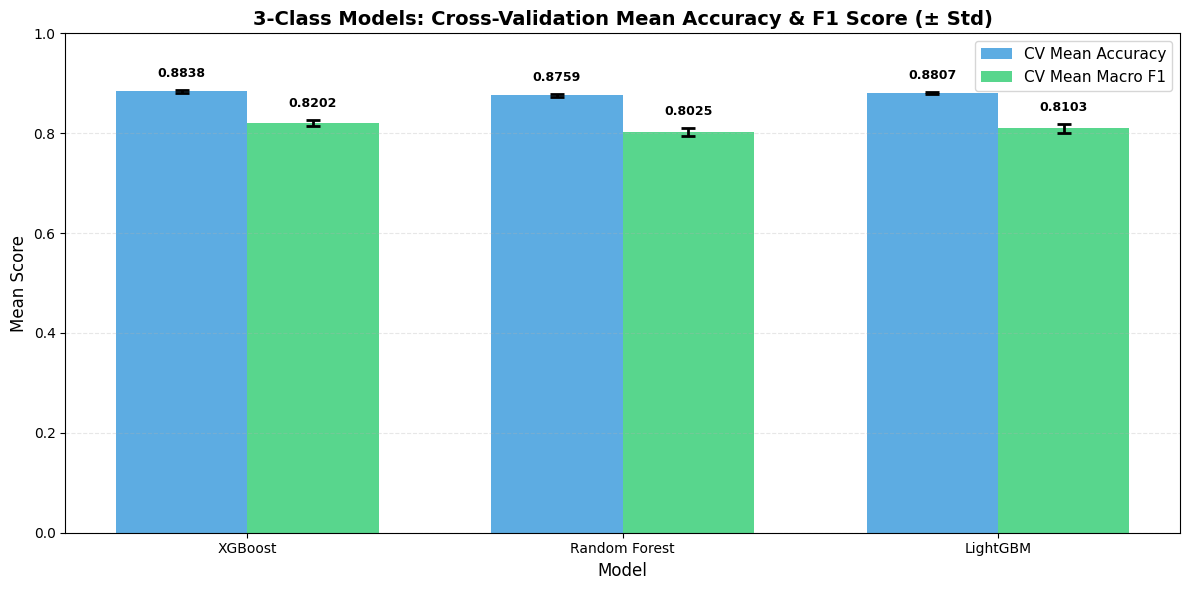


3-Class Cross-Validation Summary
Best CV Mean Accuracy: XGBoost (0.8838 ± 0.0027)
Best CV Mean F1: XGBoost (0.8202 ± 0.0058)


In [ ]:
# Visual Comparison of 3-Class Models - Cross-Validation Only
fig, ax = plt.subplots(1, 1, figsize=(12, 6))

# Prepare data for bar plots
x_pos = np.arange(len(models_comparison_3class))
models = models_comparison_3class['Model'].values
width = 0.35  # Width of bars

# Cross-Validation: Mean Accuracy and F1 Score Combined
ax.bar(x_pos - width/2, models_comparison_3class['CV Mean Accuracy'], width,
        yerr=models_comparison_3class['CV Std Accuracy'],
        label='CV Mean Accuracy', color='#3498db', alpha=0.8,
        capsize=5, error_kw={'elinewidth': 2, 'capthick': 2})
ax.bar(x_pos + width/2, models_comparison_3class['CV Mean F1'], width,
        yerr=models_comparison_3class['CV Std F1'],
        label='CV Mean Macro F1', color='#2ecc71', alpha=0.8,
        capsize=5, error_kw={'elinewidth': 2, 'capthick': 2})

ax.set_title('3-Class Models: Cross-Validation Mean Accuracy & F1 Score (± Std)',
             fontsize=14, fontweight='bold')
ax.set_ylabel('Mean Score', fontsize=12)
ax.set_xlabel('Model', fontsize=12)
ax.set_xticks(x_pos)
ax.set_xticklabels(models)
ax.set_ylim([0, 1])
ax.legend(fontsize=11)
ax.grid(axis='y', alpha=0.3, linestyle='--')

# Add value labels on bars
for i, (acc_mean, acc_std, f1_mean, f1_std) in enumerate(zip(
    models_comparison_3class['CV Mean Accuracy'],
    models_comparison_3class['CV Std Accuracy'],
    models_comparison_3class['CV Mean F1'],
    models_comparison_3class['CV Std F1'])):
    ax.text(i - width/2, acc_mean + acc_std + 0.02, f'{acc_mean:.4f}',
             ha='center', va='bottom', fontweight='bold', fontsize=9)
    ax.text(i + width/2, f1_mean + f1_std + 0.02, f'{f1_mean:.4f}',
             ha='center', va='bottom', fontweight='bold', fontsize=9)

plt.tight_layout()
plt.show()

print("\n" + "="*80)
print("3-Class Cross-Validation Summary")
print("="*80)
print(f"Best CV Mean Accuracy: {models_comparison_3class.loc[models_comparison_3class['CV Mean Accuracy'].idxmax(), 'Model']} ({models_comparison_3class['CV Mean Accuracy'].max():.4f} ± {models_comparison_3class.loc[models_comparison_3class['CV Mean Accuracy'].idxmax(), 'CV Std Accuracy']:.4f})")
print(f"Best CV Mean F1: {models_comparison_3class.loc[models_comparison_3class['CV Mean F1'].idxmax(), 'Model']} ({models_comparison_3class['CV Mean F1'].max():.4f} ± {models_comparison_3class.loc[models_comparison_3class['CV Mean F1'].idxmax(), 'CV Std F1']:.4f})")



In [ ]:
# Import additional models
from sklearn.ensemble import RandomForestClassifier
import lightgbm as lgb

# Create alias for LGBMClassifier
LGBMClassifier = lgb.LGBMClassifier

print("All models imported successfully!")
print(f"LightGBM version: {lgb.__version__}")


All models imported successfully!
LightGBM version: 4.6.0


In [ ]:
# Prepare data for 4-class models (using original df with CAR, LCV, HCV, BUS)
# Use the same preprocessing as the original XGBoost model
X_4class = df.drop(columns=['VehicleType_class'])
y_4class = df['VehicleType_class']

# Encode labels for 4 classes
labelEncoder_4class = LabelEncoder()
y_4class_encoded = labelEncoder_4class.fit_transform(y_4class)

print("4-Class mapping:")
for i, class_name in enumerate(labelEncoder_4class.classes_):
    print(f"  {i}: {class_name}")

# Create train-test split with stratification
X_train_4class, X_test_4class, y_train_4class, y_test_4class = train_test_split(
    X_4class, y_4class_encoded, test_size=0.2, stratify=y_4class_encoded, random_state=8
)

print(f"\nTraining set size: {len(X_train_4class)}")
print(f"Test set size: {len(X_test_4class)}")
print(f"\nTraining set class distribution:")
unique, counts = np.unique(y_train_4class, return_counts=True)
for u, c in zip(unique, counts):
    print(f"  {labelEncoder_4class.classes_[u]}: {c}")

# Scale numerical features
scaler_4class = StandardScaler()
X_train_4class_scaled = scaler_4class.fit_transform(X_train_4class)
X_test_4class_scaled = scaler_4class.transform(X_test_4class)

print("\nData preparation completed!")


4-Class mapping:
  0: BUS
  1: CAR
  2: HCV
  3: LCV

Training set size: 34907
Test set size: 8727

Training set class distribution:
  BUS: 1030
  CAR: 2427
  HCV: 24646
  LCV: 6804

Data preparation completed!


In [ ]:
# ============================================================================
# Random Forest Model for 4-class classification
# ============================================================================

# Random Forest parameters
rf_params = {
    'n_estimators': 200,
    'max_depth': 15,
    'min_samples_split': 5,
    'min_samples_leaf': 2,
    'max_features': 'sqrt',
    'bootstrap': True,
    'random_state': 8,
    'n_jobs': -1,  # Use all available cores
    'class_weight': 'balanced'  # Handle class imbalance
}

# Create and train Random Forest classifier
rf_model = RandomForestClassifier(**rf_params)
print("Training Random Forest model...")
rf_model.fit(X_train_4class_scaled, y_train_4class)
print("Random Forest model trained successfully!")

# Make predictions
y_pred_rf = rf_model.predict(X_test_4class_scaled)
y_train_pred_rf = rf_model.predict(X_train_4class_scaled)

# Classification reports
print("\n" + "="*80)
print("Random Forest 4-Class Model - Test Set")
print("="*80)
print(classification_report(y_test_4class, y_pred_rf, target_names=labelEncoder_4class.classes_))
test_accuracy_rf = accuracy_score(y_test_4class, y_pred_rf)
test_f1_rf = f1_score(y_test_4class, y_pred_rf, average='macro')
print(f"Test Accuracy: {test_accuracy_rf:.4f}")
print(f"Test Macro F1 Score: {test_f1_rf:.4f}")

print("\n" + "="*80)
print("Random Forest 4-Class Model - Train Set")
print("="*80)
print(classification_report(y_train_4class, y_train_pred_rf, target_names=labelEncoder_4class.classes_))
train_accuracy_rf = accuracy_score(y_train_4class, y_train_pred_rf)
train_f1_rf = f1_score(y_train_4class, y_train_pred_rf, average='macro')
print(f"Train Accuracy: {train_accuracy_rf:.4f}")
print(f"Train Macro F1 Score: {train_f1_rf:.4f}")


Training Random Forest model...
Random Forest model trained successfully!

Random Forest 4-Class Model - Test Set
              precision    recall  f1-score   support

         BUS       0.74      0.69      0.72       257
         CAR       0.44      0.14      0.21       607
         HCV       0.91      0.91      0.91      6162
         LCV       0.59      0.73      0.65      1701

    accuracy                           0.82      8727
   macro avg       0.67      0.62      0.62      8727
weighted avg       0.81      0.82      0.81      8727

Test Accuracy: 0.8169
Test Macro F1 Score: 0.6219

Random Forest 4-Class Model - Train Set
              precision    recall  f1-score   support

         BUS       0.89      0.99      0.94      1030
         CAR       0.95      0.95      0.95      2427
         HCV       0.97      0.95      0.96     24646
         LCV       0.85      0.91      0.88      6804

    accuracy                           0.94     34907
   macro avg       0.92      0.95 

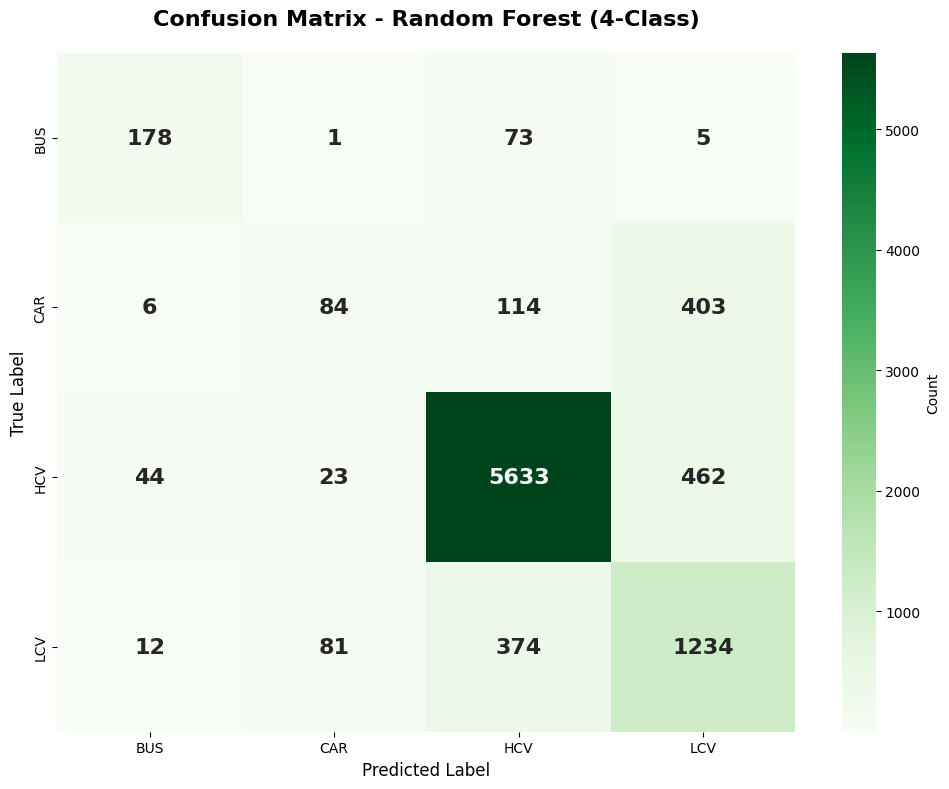


Random Forest Confusion Matrix (rows=true, cols=predicted):
     BUS  CAR   HCV   LCV
BUS  178    1    73     5
CAR    6   84   114   403
HCV   44   23  5633   462
LCV   12   81   374  1234


In [ ]:
# Random Forest Confusion Matrix
cm_rf = confusion_matrix(y_test_4class, y_pred_rf)
labels_4class = labelEncoder_4class.classes_

# Create confusion matrix heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Greens',
            xticklabels=labels_4class, yticklabels=labels_4class,
            cbar_kws={'label': 'Count'},
            annot_kws={'size': 16, 'weight': 'bold'})
plt.title('Confusion Matrix - Random Forest (4-Class)',
          fontsize=16, fontweight='bold', pad=20)
plt.ylabel('True Label', fontsize=12)
plt.xlabel('Predicted Label', fontsize=12)
plt.tight_layout()
plt.show()

# Print confusion matrix as DataFrame
cm_df_rf = pd.DataFrame(cm_rf, index=labels_4class, columns=labels_4class)
print("\nRandom Forest Confusion Matrix (rows=true, cols=predicted):")
print(cm_df_rf)


/tmp/ipython-input-3783648284.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_features, y='feature', x='importance', palette='viridis')


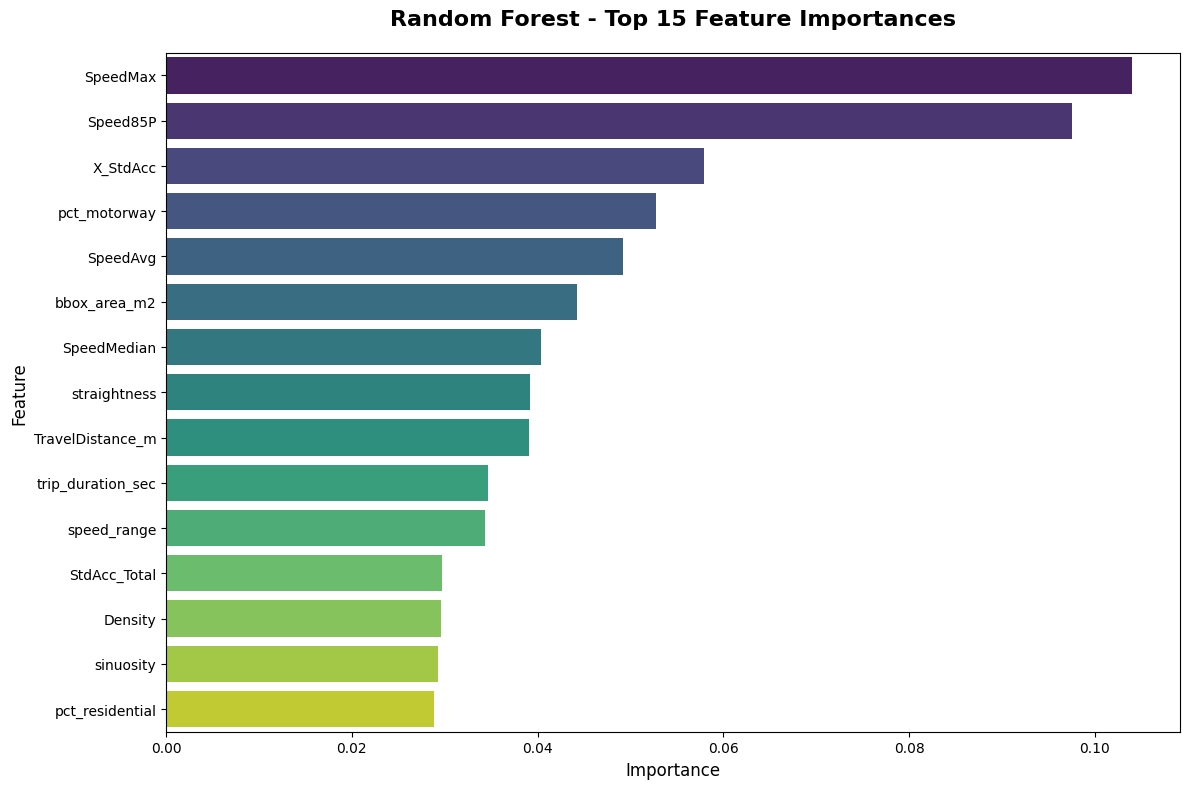


Top 10 Most Important Features (Random Forest):
              feature  importance
6            SpeedMax    0.103970
17           Speed85P    0.097571
22           X_StdAcc    0.057893
0        pct_motorway    0.052781
7            SpeedAvg    0.049162
14       bbox_area_m2    0.044254
8         SpeedMedian    0.040390
15       straightness    0.039173
10   TravelDistance_m    0.039042
9   trip_duration_sec    0.034705


In [ ]:
# Random Forest Feature Importance
feature_importance_rf = pd.DataFrame({
    'feature': X_4class.columns,
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=False)

# Plot top 15 features
plt.figure(figsize=(12, 8))
top_features = feature_importance_rf.head(15)
sns.barplot(data=top_features, y='feature', x='importance', palette='viridis')
plt.title('Random Forest - Top 15 Feature Importances', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Importance', fontsize=12)
plt.ylabel('Feature', fontsize=12)
plt.tight_layout()
plt.show()

print("\nTop 10 Most Important Features (Random Forest):")
print(feature_importance_rf.head(10))


In [ ]:
# ============================================================================
# LightGBM Model for 4-class classification
# ============================================================================
# Import additional models
from sklearn.ensemble import RandomForestClassifier
import lightgbm as lgb

# Create alias for LGBMClassifier
LGBMClassifier = lgb.LGBMClassifier

print("All models imported successfully!")
print(f"LightGBM version: {lgb.__version__}")

# LightGBM parameters
# LightGBM is a gradient boosting framework that is faster and often more accurate than XGBoost
lgb_params = {
    'objective': 'multiclass',
    'num_class': 4,
    'metric': 'multi_logloss',
    'boosting_type': 'gbdt',
    'num_leaves': 31,
    'learning_rate': 0.05,
    'feature_fraction': 0.8,
    'bagging_fraction': 0.8,
    'bagging_freq': 5,
    'max_depth': 7,
    'min_child_samples': 20,
    'reg_alpha': 0.1,
    'reg_lambda': 0.1,
    'random_state': 8,
    'n_jobs': -1,
    'verbosity': -1  # Suppress warnings
}

# Create and train LightGBM classifier
lgb_model = LGBMClassifier(**lgb_params)
print("Training LightGBM model...")
lgb_model.fit(
    X_train_4class_scaled,
    y_train_4class,
    eval_set=[(X_test_4class_scaled, y_test_4class)],
    callbacks=[lgb.early_stopping(stopping_rounds=50), lgb.log_evaluation(period=0)]
)
print("LightGBM model trained successfully!")
print(f"Best iteration: {lgb_model.best_iteration_}")


All models imported successfully!
LightGBM version: 4.6.0
Training LightGBM model...
Training until validation scores don't improve for 50 rounds
Did not meet early stopping. Best iteration is:
[100]	valid_0's multi_logloss: 0.469253
LightGBM model trained successfully!
Best iteration: 100


In [ ]:
# LightGBM predictions
y_pred_lgb = lgb_model.predict(X_test_4class_scaled)
y_train_pred_lgb = lgb_model.predict(X_train_4class_scaled)

# Classification reports
print("="*80)
print("LightGBM 4-Class Model - Test Set")
print("="*80)
print(classification_report(y_test_4class, y_pred_lgb, target_names=labelEncoder_4class.classes_))
test_accuracy_lgb = accuracy_score(y_test_4class, y_pred_lgb)
test_f1_lgb = f1_score(y_test_4class, y_pred_lgb, average='macro')
print(f"Test Accuracy: {test_accuracy_lgb:.4f}")
print(f"Test Macro F1 Score: {test_f1_lgb:.4f}")

print("\n" + "="*80)
print("LightGBM 4-Class Model - Train Set")
print("="*80)
print(classification_report(y_train_4class, y_train_pred_lgb, target_names=labelEncoder_4class.classes_))
train_accuracy_lgb = accuracy_score(y_train_4class, y_train_pred_lgb)
train_f1_lgb = f1_score(y_train_4class, y_train_pred_lgb, average='macro')
print(f"Train Accuracy: {train_accuracy_lgb:.4f}")
print(f"Train Macro F1 Score: {train_f1_lgb:.4f}")


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


LightGBM 4-Class Model - Test Set
              precision    recall  f1-score   support

         BUS       0.86      0.64      0.73       257
         CAR       0.57      0.07      0.13       607
         HCV       0.88      0.95      0.91      6162
         LCV       0.62      0.68      0.65      1701

    accuracy                           0.82      8727
   macro avg       0.73      0.59      0.61      8727
weighted avg       0.81      0.82      0.80      8727

Test Accuracy: 0.8248
Test Macro F1 Score: 0.6065

LightGBM 4-Class Model - Train Set
              precision    recall  f1-score   support

         BUS       0.92      0.74      0.82      1030
         CAR       0.86      0.15      0.26      2427
         HCV       0.90      0.96      0.93     24646
         LCV       0.68      0.74      0.71      6804

    accuracy                           0.85     34907
   macro avg       0.84      0.65      0.68     34907
weighted avg       0.86      0.85      0.84     34907

Train Accu

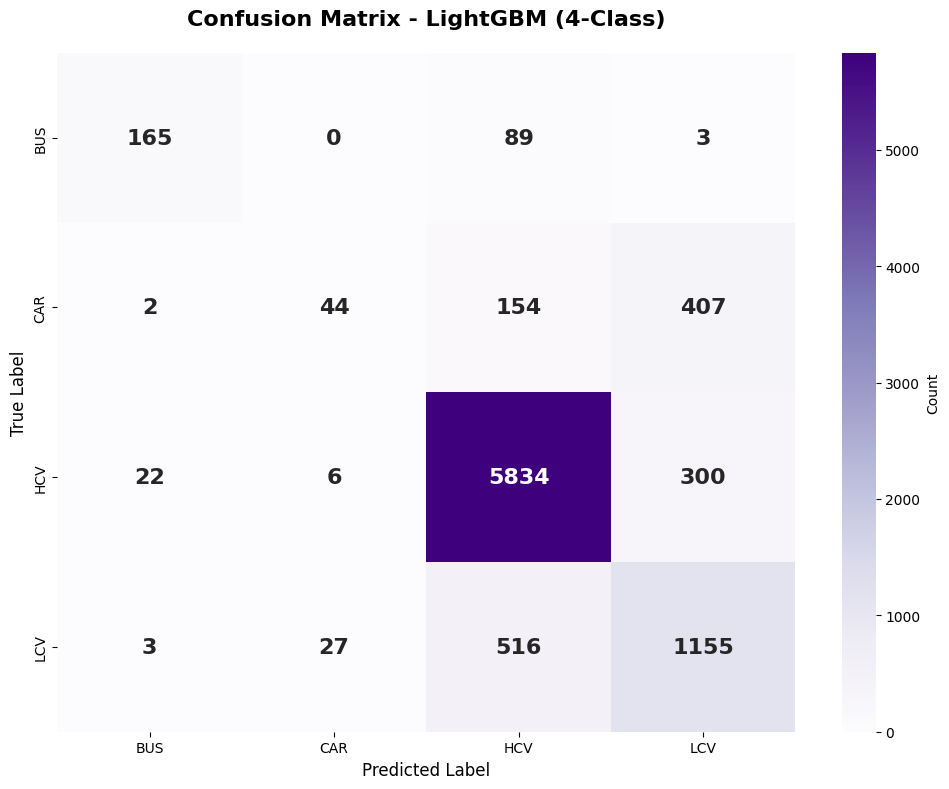


LightGBM Confusion Matrix (rows=true, cols=predicted):
     BUS  CAR   HCV   LCV
BUS  165    0    89     3
CAR    2   44   154   407
HCV   22    6  5834   300
LCV    3   27   516  1155


In [ ]:
# LightGBM Confusion Matrix
cm_lgb = confusion_matrix(y_test_4class, y_pred_lgb)

# Create confusion matrix heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(cm_lgb, annot=True, fmt='d', cmap='Purples',
            xticklabels=labels_4class, yticklabels=labels_4class,
            cbar_kws={'label': 'Count'},
            annot_kws={'size': 16, 'weight': 'bold'})
plt.title('Confusion Matrix - LightGBM (4-Class)',
          fontsize=16, fontweight='bold', pad=20)
plt.ylabel('True Label', fontsize=12)
plt.xlabel('Predicted Label', fontsize=12)
plt.tight_layout()
plt.show()

# Print confusion matrix as DataFrame
cm_df_lgb = pd.DataFrame(cm_lgb, index=labels_4class, columns=labels_4class)
print("\nLightGBM Confusion Matrix (rows=true, cols=predicted):")
print(cm_df_lgb)


/tmp/ipython-input-905712377.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_features_lgb, y='feature', x='importance', palette='magma')


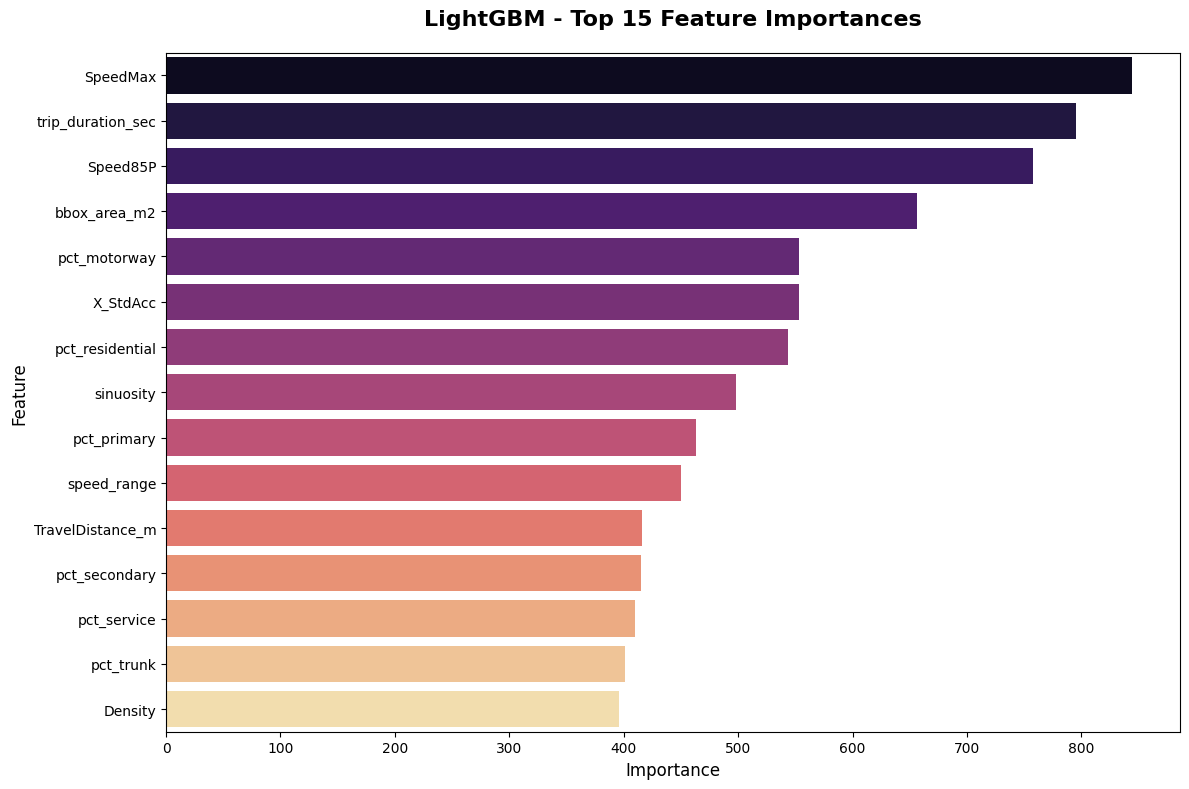


Top 10 Most Important Features (LightGBM):
              feature  importance
6            SpeedMax         844
9   trip_duration_sec         795
17           Speed85P         758
14       bbox_area_m2         656
0        pct_motorway         553
22           X_StdAcc         553
4     pct_residential         544
16          sinuosity         498
2         pct_primary         463
18        speed_range         450


In [ ]:
# LightGBM Feature Importance
feature_importance_lgb = pd.DataFrame({
    'feature': X_4class.columns,
    'importance': lgb_model.feature_importances_
}).sort_values('importance', ascending=False)

# Plot top 15 features
plt.figure(figsize=(12, 8))
top_features_lgb = feature_importance_lgb.head(15)
sns.barplot(data=top_features_lgb, y='feature', x='importance', palette='magma')
plt.title('LightGBM - Top 15 Feature Importances', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Importance', fontsize=12)
plt.ylabel('Feature', fontsize=12)
plt.tight_layout()
plt.show()

print("\nTop 10 Most Important Features (LightGBM):")
print(feature_importance_lgb.head(10))


In [ ]:
# Cross validation for both models
print("="*80)
print("Cross Validation Results - 4-Class Models")
print("="*80)

f1_macro_4class = make_scorer(f1_score, average='macro')

# Random Forest CV
print("\n" + "-"*80)
print("Random Forest 4-Class Model - 5-Fold Cross Validation")
print("-"*80)

# F1 Macro Score CV
cv_scores_rf_f1 = cross_val_score(rf_model, X_4class, y_4class_encoded, cv=5, scoring=f1_macro_4class)
print(f"\nF1 Macro scores for each fold: {cv_scores_rf_f1}")
print(f"Mean F1 Macro score: {np.mean(cv_scores_rf_f1):.4f} ± {np.std(cv_scores_rf_f1):.4f}")

# Accuracy CV
cv_scores_rf_acc = cross_val_score(rf_model, X_4class, y_4class_encoded, cv=5, scoring='accuracy')
print(f"\nAccuracy scores for each fold: {cv_scores_rf_acc}")
print(f"Mean Accuracy: {np.mean(cv_scores_rf_acc):.4f} ± {np.std(cv_scores_rf_acc):.4f}")

# LightGBM CV
print("\n" + "-"*80)
print("LightGBM 4-Class Model - 5-Fold Cross Validation")
print("-"*80)

# F1 Macro Score CV
cv_scores_lgb_f1 = cross_val_score(lgb_model, X_4class, y_4class_encoded, cv=5, scoring=f1_macro_4class)
print(f"\nF1 Macro scores for each fold: {cv_scores_lgb_f1}")
print(f"Mean F1 Macro score: {np.mean(cv_scores_lgb_f1):.4f} ± {np.std(cv_scores_lgb_f1):.4f}")

# Accuracy CV
cv_scores_lgb_acc = cross_val_score(lgb_model, X_4class, y_4class_encoded, cv=5, scoring='accuracy')
print(f"\nAccuracy scores for each fold: {cv_scores_lgb_acc}")
print(f"Mean Accuracy: {np.mean(cv_scores_lgb_acc):.4f} ± {np.std(cv_scores_lgb_acc):.4f}")


Cross Validation Results - 4-Class Models

--------------------------------------------------------------------------------
Random Forest 4-Class Model - 5-Fold Cross Validation
--------------------------------------------------------------------------------

F1 Macro scores for each fold: [0.60898821 0.63418108 0.62982766 0.6167006  0.6170496 ]
Mean F1 Macro score: 0.6213 ± 0.0093

Accuracy scores for each fold: [0.81482755 0.82319239 0.82284863 0.81517131 0.81457713]
Mean Accuracy: 0.8181 ± 0.0040

--------------------------------------------------------------------------------
LightGBM 4-Class Model - 5-Fold Cross Validation
--------------------------------------------------------------------------------

F1 Macro scores for each fold: [0.58971458 0.61482085 0.60284896 0.58955911 0.60112029]
Mean F1 Macro score: 0.5996 ± 0.0094

Accuracy scores for each fold: [0.82731752 0.83327604 0.82972385 0.82044231 0.82580793]
Mean Accuracy: 0.8273 ± 0.0043


Model Comparison Summary (Test Set Performance)
        Model  Test Macro F1  Test Accuracy  CV Mean F1  CV Std F1  CV Mean Accuracy  CV Std Accuracy
Random Forest       0.621939       0.816890    0.621349   0.009267          0.818123         0.004004
     LightGBM       0.606546       0.824797    0.599613   0.009414          0.827314         0.004262


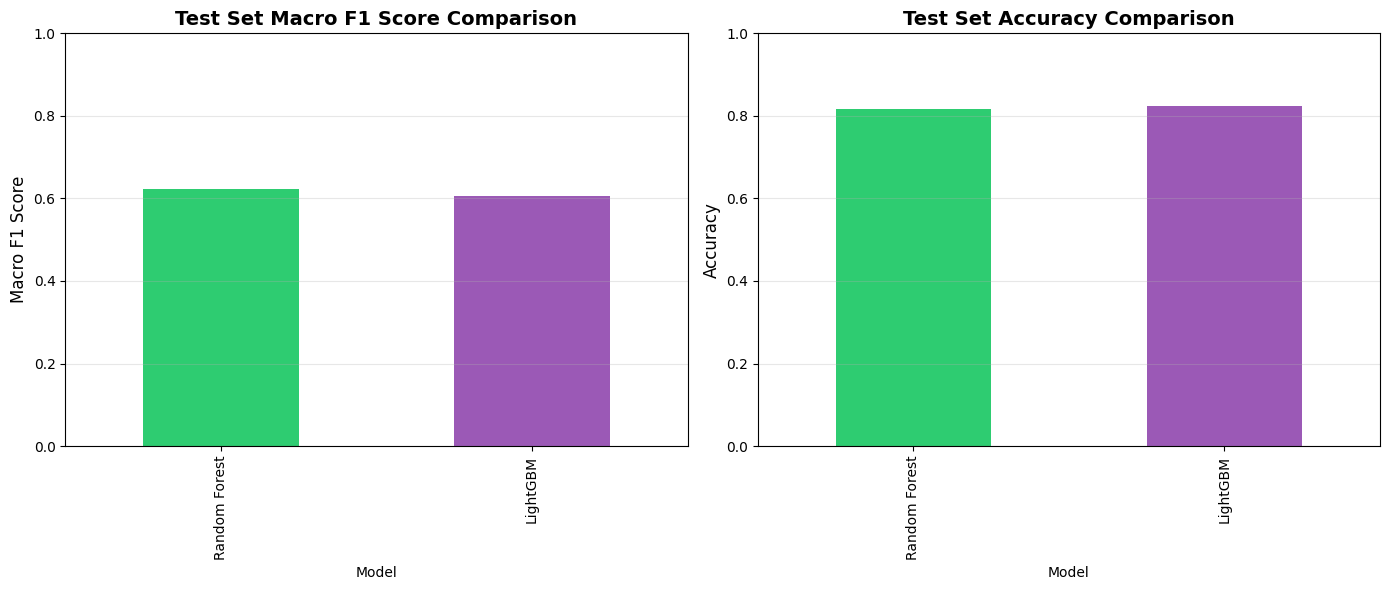

In [ ]:
# Model Comparison Summary
print("="*80)
print("Model Comparison Summary (Test Set Performance)")
print("="*80)

models_comparison = pd.DataFrame({
    'Model': ['Random Forest', 'LightGBM'],
    'Test Macro F1': [
        f1_score(y_test_4class, y_pred_rf, average='macro'),
        f1_score(y_test_4class, y_pred_lgb, average='macro')
    ],
    'Test Accuracy': [
        (y_test_4class == y_pred_rf).mean(),
        (y_test_4class == y_pred_lgb).mean()
    ],
    'CV Mean F1': [
        np.mean(cv_scores_rf_f1),
        np.mean(cv_scores_lgb_f1)
    ],
    'CV Std F1': [
        np.std(cv_scores_rf_f1),
        np.std(cv_scores_lgb_f1)
    ],
    'CV Mean Accuracy': [
        np.mean(cv_scores_rf_acc),
        np.mean(cv_scores_lgb_acc)
    ],
    'CV Std Accuracy': [
        np.std(cv_scores_rf_acc),
        np.std(cv_scores_lgb_acc)
    ]
})

print(models_comparison.to_string(index=False))

# Visualize comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Macro F1 Score comparison
models_comparison.plot(x='Model', y='Test Macro F1', kind='bar', ax=axes[0],
                       color=['#2ecc71', '#9b59b6'], legend=False)
axes[0].set_title('Test Set Macro F1 Score Comparison', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Macro F1 Score', fontsize=12)
axes[0].set_ylim([0, 1])
axes[0].grid(axis='y', alpha=0.3)

# Accuracy comparison
models_comparison.plot(x='Model', y='Test Accuracy', kind='bar', ax=axes[1],
                       color=['#2ecc71', '#9b59b6'], legend=False)
axes[1].set_title('Test Set Accuracy Comparison', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Accuracy', fontsize=12)
axes[1].set_ylim([0, 1])
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()


In [ ]:
# Comprehensive 4-Class Models Comparison
print("="*80)
print("Comprehensive 4-Class Models Comparison")
print("="*80)
print("\nComparing: XGBoost, Random Forest, and LightGBM")
print("Classes: CAR, LCV, HCV, BUS\n")

# Create comprehensive comparison DataFrame
models_comparison_4class = pd.DataFrame({
    'Model': ['XGBoost', 'Random Forest', 'LightGBM'],
    'Test Accuracy': [
        test_accuracy,
        test_accuracy_rf,
        test_accuracy_lgb
    ],
    'Test Macro F1': [
        test_f1,
        test_f1_rf,
        test_f1_lgb
    ],
    'Train Accuracy': [
        train_accuracy,
        train_accuracy_rf,
        train_accuracy_lgb
    ],
    'Train Macro F1': [
        train_f1,
        train_f1_rf,
        train_f1_lgb
    ],
    'CV Mean Accuracy': [
        np.mean(cv_scores_acc),
        np.mean(cv_scores_rf_acc),
        np.mean(cv_scores_lgb_acc)
    ],
    'CV Std Accuracy': [
        np.std(cv_scores_acc),
        np.std(cv_scores_rf_acc),
        np.std(cv_scores_lgb_acc)
    ],
    'CV Mean F1': [
        np.mean(cv_scores_f1),
        np.mean(cv_scores_rf_f1),
        np.mean(cv_scores_lgb_f1)
    ],
    'CV Std F1': [
        np.std(cv_scores_f1),
        np.std(cv_scores_rf_f1),
        np.std(cv_scores_lgb_f1)
    ]
})

# Format the DataFrame for better display
models_comparison_4class['Test Accuracy'] = models_comparison_4class['Test Accuracy'].round(4)
models_comparison_4class['Test Macro F1'] = models_comparison_4class['Test Macro F1'].round(4)
models_comparison_4class['Train Accuracy'] = models_comparison_4class['Train Accuracy'].round(4)
models_comparison_4class['Train Macro F1'] = models_comparison_4class['Train Macro F1'].round(4)
models_comparison_4class['CV Mean Accuracy'] = models_comparison_4class['CV Mean Accuracy'].round(4)
models_comparison_4class['CV Std Accuracy'] = models_comparison_4class['CV Std Accuracy'].round(4)
models_comparison_4class['CV Mean F1'] = models_comparison_4class['CV Mean F1'].round(4)
models_comparison_4class['CV Std F1'] = models_comparison_4class['CV Std F1'].round(4)

print("\n" + "="*80)
print("Performance Summary Table")
print("="*80)
print(models_comparison_4class.to_string(index=False))

# Find best model for each metric
print("\n" + "="*80)
print("Best Model for Each Metric")
print("="*80)
print(f"Best Test Accuracy: {models_comparison_4class.loc[models_comparison_4class['Test Accuracy'].idxmax(), 'Model']} ({models_comparison_4class['Test Accuracy'].max():.4f})")
print(f"Best Test Macro F1: {models_comparison_4class.loc[models_comparison_4class['Test Macro F1'].idxmax(), 'Model']} ({models_comparison_4class['Test Macro F1'].max():.4f})")
print(f"Best CV Mean Accuracy: {models_comparison_4class.loc[models_comparison_4class['CV Mean Accuracy'].idxmax(), 'Model']} ({models_comparison_4class['CV Mean Accuracy'].max():.4f})")
print(f"Best CV Mean F1: {models_comparison_4class.loc[models_comparison_4class['CV Mean F1'].idxmax(), 'Model']} ({models_comparison_4class['CV Mean F1'].max():.4f})")


Comprehensive 4-Class Models Comparison

Comparing: XGBoost, Random Forest, and LightGBM
Classes: CAR, LCV, HCV, BUS


Performance Summary Table
        Model  Test Accuracy  Test Macro F1  Train Accuracy  Train Macro F1  CV Mean Accuracy  CV Std Accuracy  CV Mean F1  CV Std F1
      XGBoost         0.8272         0.6265          0.9164          0.8539            0.8270           0.0037      0.6243     0.0099
Random Forest         0.8169         0.6219          0.9428          0.9324            0.8181           0.0040      0.6213     0.0093
     LightGBM         0.8248         0.6065          0.8538          0.6796            0.8273           0.0043      0.5996     0.0094

Best Model for Each Metric
Best Test Accuracy: XGBoost (0.8272)
Best Test Macro F1: XGBoost (0.6265)
Best CV Mean Accuracy: LightGBM (0.8273)
Best CV Mean F1: XGBoost (0.6243)


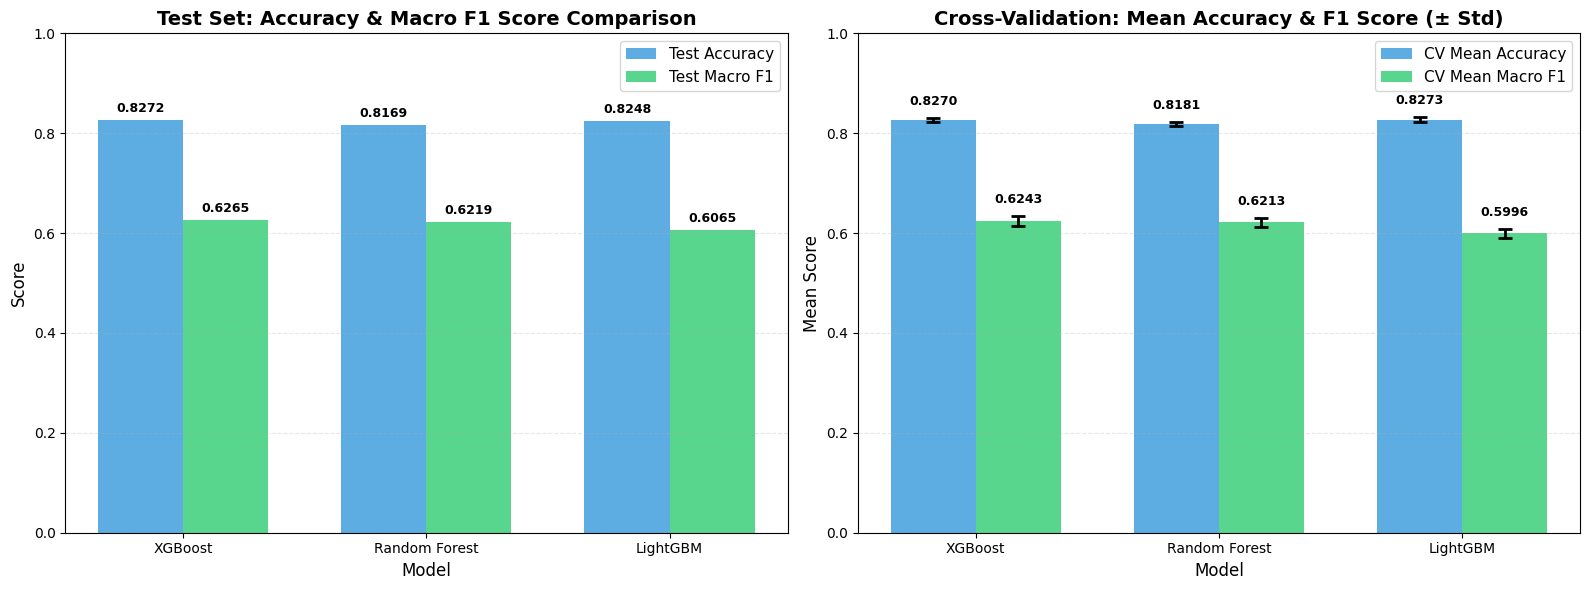

In [ ]:
# Visual Comparison of 4-Class Models (Combined Bar Charts)
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Prepare data for bar plots
x_pos = np.arange(len(models_comparison_4class))
models = models_comparison_4class['Model'].values
width = 0.35  # Width of bars


# 1. Test Set: Accuracy and F1 Score Combined
axes[0].bar(x_pos - width/2, models_comparison_4class['Test Accuracy'], width,
            label='Test Accuracy', color='#3498db', alpha=0.8)
axes[0].bar(x_pos + width/2, models_comparison_4class['Test Macro F1'], width,
            label='Test Macro F1', color='#2ecc71', alpha=0.8)

axes[0].set_title('Test Set: Accuracy & Macro F1 Score Comparison', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Score', fontsize=12)
axes[0].set_xlabel('Model', fontsize=12)
axes[0].set_xticks(x_pos)
axes[0].set_xticklabels(models)
axes[0].set_ylim([0, 1])
axes[0].legend(fontsize=11)
axes[0].grid(axis='y', alpha=0.3, linestyle='--')

# Add value labels on bars
for i, (acc, f1) in enumerate(zip(models_comparison_4class['Test Accuracy'],
                                    models_comparison_4class['Test Macro F1'])):
    axes[0].text(i - width/2, acc + 0.01, f'{acc:.4f}',
                 ha='center', va='bottom', fontweight='bold', fontsize=9)
    axes[0].text(i + width/2, f1 + 0.01, f'{f1:.4f}',
                 ha='center', va='bottom', fontweight='bold', fontsize=9)

# 2. Cross-Validation: Mean Accuracy and F1 Score Combined
axes[1].bar(x_pos - width/2, models_comparison_4class['CV Mean Accuracy'], width,
            yerr=models_comparison_4class['CV Std Accuracy'],
            label='CV Mean Accuracy', color='#3498db', alpha=0.8,
            capsize=5, error_kw={'elinewidth': 2, 'capthick': 2})
axes[1].bar(x_pos + width/2, models_comparison_4class['CV Mean F1'], width,
            yerr=models_comparison_4class['CV Std F1'],
            label='CV Mean Macro F1', color='#2ecc71', alpha=0.8,
            capsize=5, error_kw={'elinewidth': 2, 'capthick': 2})

axes[1].set_title('Cross-Validation: Mean Accuracy & F1 Score (± Std)', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Mean Score', fontsize=12)
axes[1].set_xlabel('Model', fontsize=12)
axes[1].set_xticks(x_pos)
axes[1].set_xticklabels(models)
axes[1].set_ylim([0, 1])
axes[1].legend(fontsize=11)
axes[1].grid(axis='y', alpha=0.3, linestyle='--')

# Add value labels on bars
for i, (acc_mean, acc_std, f1_mean, f1_std) in enumerate(zip(
    models_comparison_4class['CV Mean Accuracy'],
    models_comparison_4class['CV Std Accuracy'],
    models_comparison_4class['CV Mean F1'],
    models_comparison_4class['CV Std F1'])):
    axes[1].text(i - width/2, acc_mean + acc_std + 0.02, f'{acc_mean:.4f}',
                 ha='center', va='bottom', fontweight='bold', fontsize=9)
    axes[1].text(i + width/2, f1_mean + f1_std + 0.02, f'{f1_mean:.4f}',
                 ha='center', va='bottom', fontweight='bold', fontsize=9)

plt.tight_layout()
plt.show()


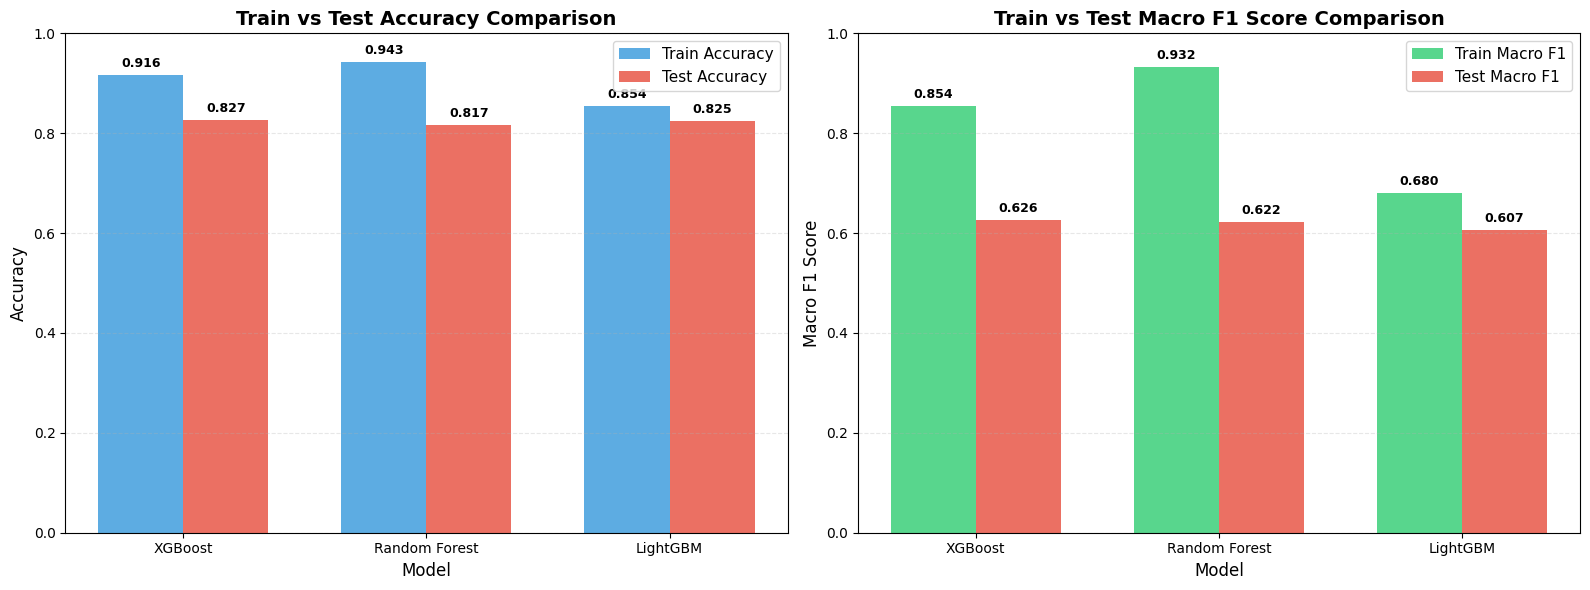


Overfitting Analysis (Train - Test)
        Model  Accuracy Gap  F1 Gap
      XGBoost        0.0892  0.2274
Random Forest        0.1259  0.3105
     LightGBM        0.0290  0.0731

Note: Lower gap indicates better generalization (less overfitting)


In [ ]:
# Overfitting Analysis: Train vs Test Performance (Combined Bar Charts)
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

x = np.arange(len(models_comparison_4class))
models = models_comparison_4class['Model'].values
width = 0.35

# 1. Accuracy: Train vs Test
axes[0].bar(x - width/2, models_comparison_4class['Train Accuracy'], width,
            label='Train Accuracy', color='#3498db', alpha=0.8)
axes[0].bar(x + width/2, models_comparison_4class['Test Accuracy'], width,
            label='Test Accuracy', color='#e74c3c', alpha=0.8)

axes[0].set_xlabel('Model', fontsize=12)
axes[0].set_ylabel('Accuracy', fontsize=12)
axes[0].set_title('Train vs Test Accuracy Comparison', fontsize=14, fontweight='bold')
axes[0].set_xticks(x)
axes[0].set_xticklabels(models)
axes[0].legend(fontsize=11)
axes[0].set_ylim([0, 1])
axes[0].grid(axis='y', alpha=0.3, linestyle='--')

# Add value labels
for i, (train, test) in enumerate(zip(models_comparison_4class['Train Accuracy'],
                                       models_comparison_4class['Test Accuracy'])):
    axes[0].text(i - width/2, train + 0.01, f'{train:.3f}',
                 ha='center', va='bottom', fontweight='bold', fontsize=9)
    axes[0].text(i + width/2, test + 0.01, f'{test:.3f}',
                 ha='center', va='bottom', fontweight='bold', fontsize=9)

# 2. F1 Score: Train vs Test
axes[1].bar(x - width/2, models_comparison_4class['Train Macro F1'], width,
            label='Train Macro F1', color='#2ecc71', alpha=0.8)
axes[1].bar(x + width/2, models_comparison_4class['Test Macro F1'], width,
            label='Test Macro F1', color='#e74c3c', alpha=0.8)

axes[1].set_xlabel('Model', fontsize=12)
axes[1].set_ylabel('Macro F1 Score', fontsize=12)
axes[1].set_title('Train vs Test Macro F1 Score Comparison', fontsize=14, fontweight='bold')
axes[1].set_xticks(x)
axes[1].set_xticklabels(models)
axes[1].legend(fontsize=11)
axes[1].set_ylim([0, 1])
axes[1].grid(axis='y', alpha=0.3, linestyle='--')

# Add value labels
for i, (train, test) in enumerate(zip(models_comparison_4class['Train Macro F1'],
                                       models_comparison_4class['Test Macro F1'])):
    axes[1].text(i - width/2, train + 0.01, f'{train:.3f}',
                 ha='center', va='bottom', fontweight='bold', fontsize=9)
    axes[1].text(i + width/2, test + 0.01, f'{test:.3f}',
                 ha='center', va='bottom', fontweight='bold', fontsize=9)

plt.tight_layout()
plt.show()

# Calculate overfitting gap
print("\n" + "="*80)
print("Overfitting Analysis (Train - Test)")
print("="*80)
models_comparison_4class['Accuracy Gap'] = models_comparison_4class['Train Accuracy'] - models_comparison_4class['Test Accuracy']
models_comparison_4class['F1 Gap'] = models_comparison_4class['Train Macro F1'] - models_comparison_4class['Test Macro F1']

overfitting_analysis = models_comparison_4class[['Model', 'Accuracy Gap', 'F1 Gap']].copy()
overfitting_analysis['Accuracy Gap'] = overfitting_analysis['Accuracy Gap'].round(4)
overfitting_analysis['F1 Gap'] = overfitting_analysis['F1 Gap'].round(4)
print(overfitting_analysis.to_string(index=False))
print("\nNote: Lower gap indicates better generalization (less overfitting)")


In [ ]:
# Summary Statistics
print("="*80)
print("Summary Statistics for 4-Class Models")
print("="*80)

summary_stats = {
    'Metric': ['Test Accuracy', 'Test Macro F1', 'CV Mean Accuracy', 'CV Mean F1'],
    'XGBoost': [
        f"{models_comparison_4class.loc[0, 'Test Accuracy']:.4f}",
        f"{models_comparison_4class.loc[0, 'Test Macro F1']:.4f}",
        f"{models_comparison_4class.loc[0, 'CV Mean Accuracy']:.4f} ± {models_comparison_4class.loc[0, 'CV Std Accuracy']:.4f}",
        f"{models_comparison_4class.loc[0, 'CV Mean F1']:.4f} ± {models_comparison_4class.loc[0, 'CV Std F1']:.4f}"
    ],
    'Random Forest': [
        f"{models_comparison_4class.loc[1, 'Test Accuracy']:.4f}",
        f"{models_comparison_4class.loc[1, 'Test Macro F1']:.4f}",
        f"{models_comparison_4class.loc[1, 'CV Mean Accuracy']:.4f} ± {models_comparison_4class.loc[1, 'CV Std Accuracy']:.4f}",
        f"{models_comparison_4class.loc[1, 'CV Mean F1']:.4f} ± {models_comparison_4class.loc[1, 'CV Std F1']:.4f}"
    ],
    'LightGBM': [
        f"{models_comparison_4class.loc[2, 'Test Accuracy']:.4f}",
        f"{models_comparison_4class.loc[2, 'Test Macro F1']:.4f}",
        f"{models_comparison_4class.loc[2, 'CV Mean Accuracy']:.4f} ± {models_comparison_4class.loc[2, 'CV Std Accuracy']:.4f}",
        f"{models_comparison_4class.loc[2, 'CV Mean F1']:.4f} ± {models_comparison_4class.loc[2, 'CV Std F1']:.4f}"
    ]
}

summary_df = pd.DataFrame(summary_stats)
print("\n" + summary_df.to_string(index=False))

print("\n" + "="*80)
print("Key Insights")
print("="*80)
print("1. Best Overall Performance: Check which model performs best across all metrics")
print("2. Generalization: Compare CV scores to test scores (closer = better generalization)")
print("3. Overfitting: Lower gap between train and test indicates better generalization")
print("4. Consistency: Lower CV standard deviation indicates more stable performance")


Summary Statistics for 4-Class Models

          Metric         XGBoost   Random Forest        LightGBM
   Test Accuracy          0.8272          0.8169          0.8248
   Test Macro F1          0.6265          0.6219          0.6065
CV Mean Accuracy 0.8270 ± 0.0037 0.8181 ± 0.0040 0.8273 ± 0.0043
      CV Mean F1 0.6243 ± 0.0099 0.6213 ± 0.0093 0.5996 ± 0.0094

Key Insights
1. Best Overall Performance: Check which model performs best across all metrics
2. Generalization: Compare CV scores to test scores (closer = better generalization)
3. Overfitting: Lower gap between train and test indicates better generalization
4. Consistency: Lower CV standard deviation indicates more stable performance


In [ ]:
# XGBoost 3-Class vs 4-Class Comparison
print("="*80)
print("XGBoost 3-Class vs 4-Class Model Comparison")
print("="*80)
print("\n3-Class Model: CAR+LCV merged into CAR_LCV, HCV, BUS")
print("4-Class Model: CAR, LCV, HCV, BUS\n")

# Create comparison DataFrame
xgb_comparison = pd.DataFrame({
    'Model': ['XGBoost 4-Class', 'XGBoost 3-Class'],
    'Classes': ['CAR, LCV, HCV, BUS', 'CAR_LCV, HCV, BUS'],
    'Test Accuracy': [
        test_accuracy,
        test_accuracy_3class
    ],
    'Test Macro F1': [
        test_f1,
        test_f1_3class
    ],
    'Train Accuracy': [
        train_accuracy,
        train_accuracy_3class
    ],
    'Train Macro F1': [
        train_f1,
        train_f1_3class
    ],
    'CV Mean Accuracy': [
        np.mean(cv_scores_acc),
        np.mean(cv_scores_3class_acc)
    ],
    'CV Std Accuracy': [
        np.std(cv_scores_acc),
        np.std(cv_scores_3class_acc)
    ],
    'CV Mean F1': [
        np.mean(cv_scores_f1),
        np.mean(cv_scores_3class_f1)
    ],
    'CV Std F1': [
        np.std(cv_scores_f1),
        np.std(cv_scores_3class_f1)
    ]
})

# Format for display
xgb_comparison['Test Accuracy'] = xgb_comparison['Test Accuracy'].round(4)
xgb_comparison['Test Macro F1'] = xgb_comparison['Test Macro F1'].round(4)
xgb_comparison['Train Accuracy'] = xgb_comparison['Train Accuracy'].round(4)
xgb_comparison['Train Macro F1'] = xgb_comparison['Train Macro F1'].round(4)
xgb_comparison['CV Mean Accuracy'] = xgb_comparison['CV Mean Accuracy'].round(4)
xgb_comparison['CV Std Accuracy'] = xgb_comparison['CV Std Accuracy'].round(4)
xgb_comparison['CV Mean F1'] = xgb_comparison['CV Mean F1'].round(4)
xgb_comparison['CV Std F1'] = xgb_comparison['CV Std F1'].round(4)

print("\n" + "="*80)
print("Performance Comparison Table")
print("="*80)
print(xgb_comparison[['Model', 'Test Accuracy', 'Test Macro F1', 'CV Mean Accuracy', 'CV Mean F1']].to_string(index=False))

# Calculate improvements
print("\n" + "="*80)
print("Performance Improvement (3-Class vs 4-Class)")
print("="*80)
acc_improvement = ((test_accuracy_3class - test_accuracy) / test_accuracy) * 100
f1_improvement = ((test_f1_3class - test_f1) / test_f1) * 100
cv_acc_improvement = ((np.mean(cv_scores_3class_acc) - np.mean(cv_scores_acc)) / np.mean(cv_scores_acc)) * 100
cv_f1_improvement = ((np.mean(cv_scores_3class_f1) - np.mean(cv_scores_f1)) / np.mean(cv_scores_f1)) * 100

print(f"Test Accuracy Improvement: {acc_improvement:+.2f}%")
print(f"Test Macro F1 Improvement: {f1_improvement:+.2f}%")
print(f"CV Mean Accuracy Improvement: {cv_acc_improvement:+.2f}%")
print(f"CV Mean F1 Improvement: {cv_f1_improvement:+.2f}%")


XGBoost 3-Class vs 4-Class Model Comparison

3-Class Model: CAR+LCV merged into CAR_LCV, HCV, BUS
4-Class Model: CAR, LCV, HCV, BUS


Performance Comparison Table
          Model  Test Accuracy  Test Macro F1  CV Mean Accuracy  CV Mean F1
XGBoost 4-Class         0.8272         0.6265            0.8270      0.6243
XGBoost 3-Class         0.8853         0.8286            0.8838      0.8202

Performance Improvement (3-Class vs 4-Class)
Test Accuracy Improvement: +7.02%
Test Macro F1 Improvement: +32.26%
CV Mean Accuracy Improvement: +6.86%
CV Mean F1 Improvement: +31.38%


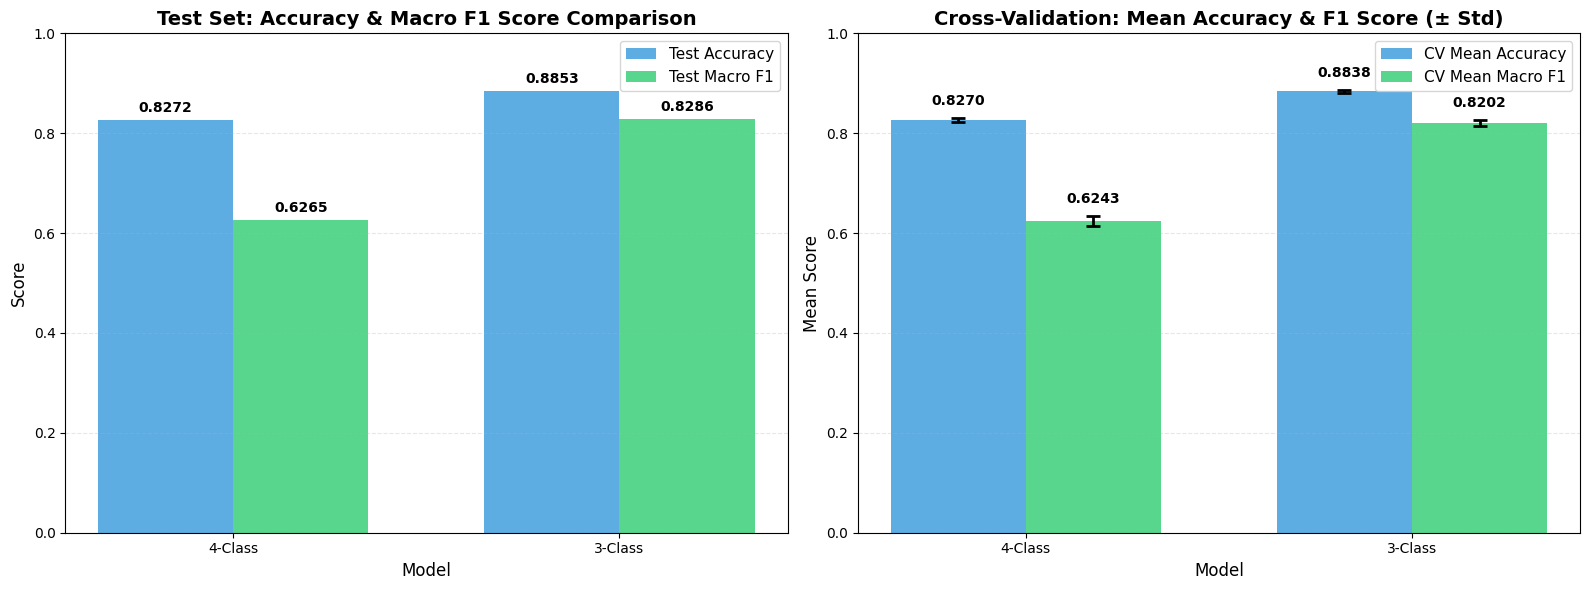

In [ ]:
# Visual Comparison: 3-Class vs 4-Class XGBoost
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

x_pos = np.arange(2)
models = ['4-Class', '3-Class']
width = 0.35

# 1. Test Set: Accuracy and F1 Score Combined
axes[0].bar(x_pos - width/2, [test_accuracy, test_accuracy_3class], width,
            label='Test Accuracy', color='#3498db', alpha=0.8)
axes[0].bar(x_pos + width/2, [test_f1, test_f1_3class], width,
            label='Test Macro F1', color='#2ecc71', alpha=0.8)

axes[0].set_title('Test Set: Accuracy & Macro F1 Score Comparison', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Score', fontsize=12)
axes[0].set_xlabel('Model', fontsize=12)
axes[0].set_xticks(x_pos)
axes[0].set_xticklabels(models)
axes[0].set_ylim([0, 1])
axes[0].legend(fontsize=11)
axes[0].grid(axis='y', alpha=0.3, linestyle='--')

# Add value labels
axes[0].text(0 - width/2, test_accuracy + 0.01, f'{test_accuracy:.4f}',
             ha='center', va='bottom', fontweight='bold', fontsize=10)
axes[0].text(0 + width/2, test_f1 + 0.01, f'{test_f1:.4f}',
             ha='center', va='bottom', fontweight='bold', fontsize=10)
axes[0].text(1 - width/2, test_accuracy_3class + 0.01, f'{test_accuracy_3class:.4f}',
             ha='center', va='bottom', fontweight='bold', fontsize=10)
axes[0].text(1 + width/2, test_f1_3class + 0.01, f'{test_f1_3class:.4f}',
             ha='center', va='bottom', fontweight='bold', fontsize=10)

# 2. Cross-Validation: Mean Accuracy and F1 Score Combined
cv_acc_4 = np.mean(cv_scores_acc)
cv_acc_3 = np.mean(cv_scores_3class_acc)
cv_acc_std_4 = np.std(cv_scores_acc)
cv_acc_std_3 = np.std(cv_scores_3class_acc)
cv_f1_4 = np.mean(cv_scores_f1)
cv_f1_3 = np.mean(cv_scores_3class_f1)
cv_f1_std_4 = np.std(cv_scores_f1)
cv_f1_std_3 = np.std(cv_scores_3class_f1)

axes[1].bar(x_pos - width/2, [cv_acc_4, cv_acc_3], width,
            yerr=[cv_acc_std_4, cv_acc_std_3],
            label='CV Mean Accuracy', color='#3498db', alpha=0.8,
            capsize=5, error_kw={'elinewidth': 2, 'capthick': 2})
axes[1].bar(x_pos + width/2, [cv_f1_4, cv_f1_3], width,
            yerr=[cv_f1_std_4, cv_f1_std_3],
            label='CV Mean Macro F1', color='#2ecc71', alpha=0.8,
            capsize=5, error_kw={'elinewidth': 2, 'capthick': 2})

axes[1].set_title('Cross-Validation: Mean Accuracy & F1 Score (± Std)', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Mean Score', fontsize=12)
axes[1].set_xlabel('Model', fontsize=12)
axes[1].set_xticks(x_pos)
axes[1].set_xticklabels(models)
axes[1].set_ylim([0, 1])
axes[1].legend(fontsize=11)
axes[1].grid(axis='y', alpha=0.3, linestyle='--')

# Add value labels
axes[1].text(0 - width/2, cv_acc_4 + cv_acc_std_4 + 0.02, f'{cv_acc_4:.4f}',
             ha='center', va='bottom', fontweight='bold', fontsize=10)
axes[1].text(0 + width/2, cv_f1_4 + cv_f1_std_4 + 0.02, f'{cv_f1_4:.4f}',
             ha='center', va='bottom', fontweight='bold', fontsize=10)
axes[1].text(1 - width/2, cv_acc_3 + cv_acc_std_3 + 0.02, f'{cv_acc_3:.4f}',
             ha='center', va='bottom', fontweight='bold', fontsize=10)
axes[1].text(1 + width/2, cv_f1_3 + cv_f1_std_3 + 0.02, f'{cv_f1_3:.4f}',
             ha='center', va='bottom', fontweight='bold', fontsize=10)

plt.tight_layout()
plt.show()


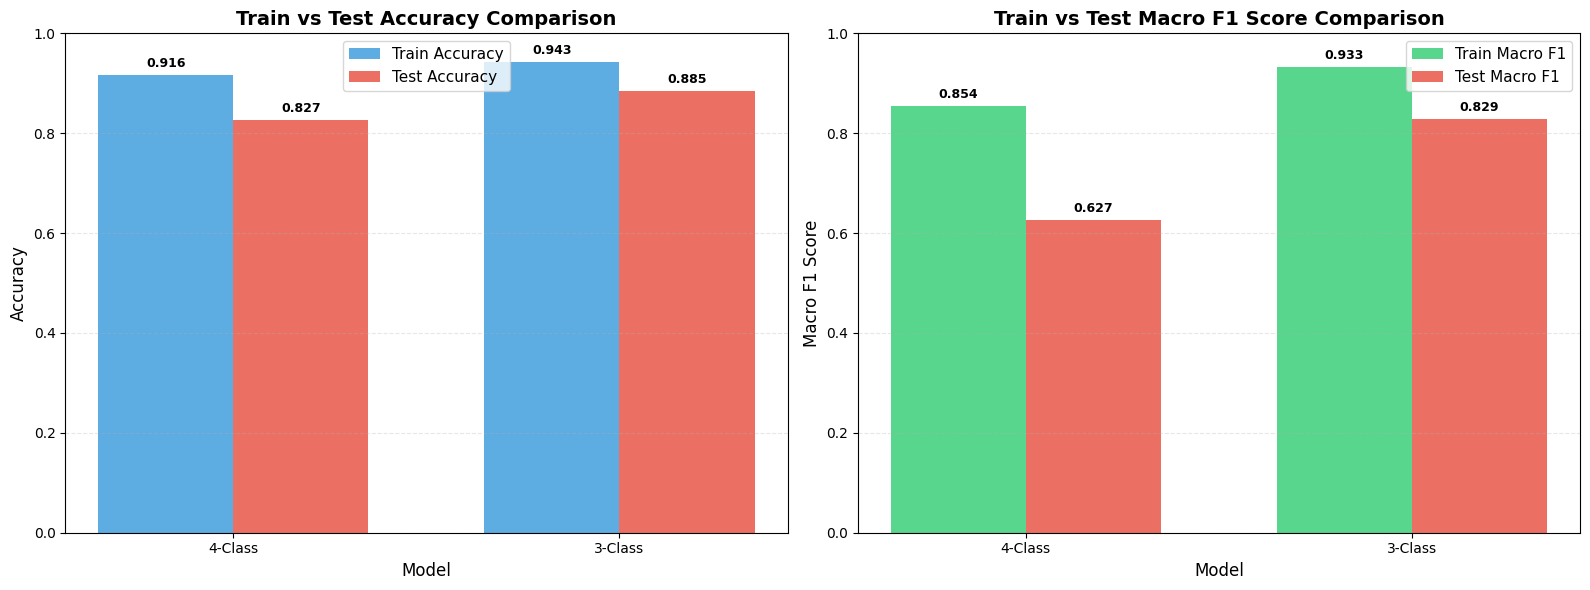


Overfitting Analysis (Train - Test Gap)
  Model  Accuracy Gap  F1 Gap
4-Class        0.0892  0.2274
3-Class        0.0576  0.1044

Note: Lower gap indicates better generalization (less overfitting)


In [ ]:
# Overfitting Analysis: Train vs Test for both models
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

x = np.arange(2)
models = ['4-Class', '3-Class']
width = 0.35

# 1. Accuracy: Train vs Test
axes[0].bar(x - width/2, [train_accuracy, train_accuracy_3class], width,
            label='Train Accuracy', color='#3498db', alpha=0.8)
axes[0].bar(x + width/2, [test_accuracy, test_accuracy_3class], width,
            label='Test Accuracy', color='#e74c3c', alpha=0.8)

axes[0].set_xlabel('Model', fontsize=12)
axes[0].set_ylabel('Accuracy', fontsize=12)
axes[0].set_title('Train vs Test Accuracy Comparison', fontsize=14, fontweight='bold')
axes[0].set_xticks(x)
axes[0].set_xticklabels(models)
axes[0].legend(fontsize=11)
axes[0].set_ylim([0, 1])
axes[0].grid(axis='y', alpha=0.3, linestyle='--')

# Add value labels
axes[0].text(0 - width/2, train_accuracy + 0.01, f'{train_accuracy:.3f}',
             ha='center', va='bottom', fontweight='bold', fontsize=9)
axes[0].text(0 + width/2, test_accuracy + 0.01, f'{test_accuracy:.3f}',
             ha='center', va='bottom', fontweight='bold', fontsize=9)
axes[0].text(1 - width/2, train_accuracy_3class + 0.01, f'{train_accuracy_3class:.3f}',
             ha='center', va='bottom', fontweight='bold', fontsize=9)
axes[0].text(1 + width/2, test_accuracy_3class + 0.01, f'{test_accuracy_3class:.3f}',
             ha='center', va='bottom', fontweight='bold', fontsize=9)

# 2. F1 Score: Train vs Test
axes[1].bar(x - width/2, [train_f1, train_f1_3class], width,
            label='Train Macro F1', color='#2ecc71', alpha=0.8)
axes[1].bar(x + width/2, [test_f1, test_f1_3class], width,
            label='Test Macro F1', color='#e74c3c', alpha=0.8)

axes[1].set_xlabel('Model', fontsize=12)
axes[1].set_ylabel('Macro F1 Score', fontsize=12)
axes[1].set_title('Train vs Test Macro F1 Score Comparison', fontsize=14, fontweight='bold')
axes[1].set_xticks(x)
axes[1].set_xticklabels(models)
axes[1].legend(fontsize=11)
axes[1].set_ylim([0, 1])
axes[1].grid(axis='y', alpha=0.3, linestyle='--')

# Add value labels
axes[1].text(0 - width/2, train_f1 + 0.01, f'{train_f1:.3f}',
             ha='center', va='bottom', fontweight='bold', fontsize=9)
axes[1].text(0 + width/2, test_f1 + 0.01, f'{test_f1:.3f}',
             ha='center', va='bottom', fontweight='bold', fontsize=9)
axes[1].text(1 - width/2, train_f1_3class + 0.01, f'{train_f1_3class:.3f}',
             ha='center', va='bottom', fontweight='bold', fontsize=9)
axes[1].text(1 + width/2, test_f1_3class + 0.01, f'{test_f1_3class:.3f}',
             ha='center', va='bottom', fontweight='bold', fontsize=9)

plt.tight_layout()
plt.show()

# Calculate overfitting gaps
print("\n" + "="*80)
print("Overfitting Analysis (Train - Test Gap)")
print("="*80)
overfitting_analysis = pd.DataFrame({
    'Model': ['4-Class', '3-Class'],
    'Accuracy Gap': [
        train_accuracy - test_accuracy,
        train_accuracy_3class - test_accuracy_3class
    ],
    'F1 Gap': [
        train_f1 - test_f1,
        train_f1_3class - test_f1_3class
    ]
})
overfitting_analysis['Accuracy Gap'] = overfitting_analysis['Accuracy Gap'].round(4)
overfitting_analysis['F1 Gap'] = overfitting_analysis['F1 Gap'].round(4)
print(overfitting_analysis.to_string(index=False))
print("\nNote: Lower gap indicates better generalization (less overfitting)")


In [ ]:
# Summary and Key Insights
print("="*80)
print("Summary: XGBoost 3-Class vs 4-Class Comparison")
print("="*80)

print("\n📊 Key Findings:")
print(f"1. Test Accuracy: 3-Class ({test_accuracy_3class:.4f}) vs 4-Class ({test_accuracy:.4f})")
print(f"   → Improvement: {acc_improvement:+.2f}%")
print(f"\n2. Test Macro F1: 3-Class ({test_f1_3class:.4f}) vs 4-Class ({test_f1:.4f})")
print(f"   → Improvement: {f1_improvement:+.2f}%")
print(f"\n3. CV Mean Accuracy: 3-Class ({np.mean(cv_scores_3class_acc):.4f}) vs 4-Class ({np.mean(cv_scores_acc):.4f})")
print(f"   → Improvement: {cv_acc_improvement:+.2f}%")
print(f"\n4. CV Mean F1: 3-Class ({np.mean(cv_scores_3class_f1):.4f}) vs 4-Class ({np.mean(cv_scores_f1):.4f})")
print(f"   → Improvement: {cv_f1_improvement:+.2f}%")

print("\n" + "="*80)
print("Recommendation")
print("="*80)
if test_f1_3class > test_f1:
    print("✅ 3-Class model shows better F1 Score performance")
    print("   → Merging CAR and LCV improves overall classification quality")
    print("   → Recommended for applications where distinguishing CAR vs LCV is not critical")
else:
    print("✅ 4-Class model maintains better class distinction")
    print("   → Recommended when CAR and LCV need to be separated")

print("\n" + "="*80)
print("Trade-off Analysis")
print("="*80)
print("3-Class Model:")
print("  ✓ Higher F1 Score (better balanced performance)")
print("  ✓ Simpler classification task")
print("  ✗ Loses distinction between CAR and LCV")
print("\n4-Class Model:")
print("  ✓ Maintains all vehicle type distinctions")
print("  ✓ More detailed classification")
print("  ✗ Lower F1 Score (class imbalance challenges)")


Summary: XGBoost 3-Class vs 4-Class Comparison

📊 Key Findings:
1. Test Accuracy: 3-Class (0.8853) vs 4-Class (0.8272)
   → Improvement: +7.02%

2. Test Macro F1: 3-Class (0.8286) vs 4-Class (0.6265)
   → Improvement: +32.26%

3. CV Mean Accuracy: 3-Class (0.8838) vs 4-Class (0.8270)
   → Improvement: +6.86%

4. CV Mean F1: 3-Class (0.8202) vs 4-Class (0.6243)
   → Improvement: +31.38%

Recommendation
✅ 3-Class model shows better F1 Score performance
   → Merging CAR and LCV improves overall classification quality
   → Recommended for applications where distinguishing CAR vs LCV is not critical

Trade-off Analysis
3-Class Model:
  ✓ Higher F1 Score (better balanced performance)
  ✓ Simpler classification task
  ✗ Loses distinction between CAR and LCV

4-Class Model:
  ✓ Maintains all vehicle type distinctions
  ✓ More detailed classification
  ✗ Lower F1 Score (class imbalance challenges)


In [ ]:
# Extract feature importance from XGBoost 4-Class model
feature_importance_xgb = pd.DataFrame({
    'feature': X.columns,
    'importance': opt.feature_importances_
}).sort_values('importance', ascending=False)

# Get top 15 features
top15_features = feature_importance_xgb.head(15).copy()

print("="*80)
print("XGBoost 4-Class Model - Top 15 Feature Importance")
print("="*80)
print(f"\nTotal features: {len(feature_importance_xgb)}")
print(f"Top 15 features account for {top15_features['importance'].sum() / feature_importance_xgb['importance'].sum() * 100:.2f}% of total importance\n")

print(top15_features.to_string(index=False))


XGBoost 4-Class Model - Top 15 Feature Importance

Total features: 28
Top 15 features account for 75.01% of total importance

          feature  importance
         SpeedMax    0.191459
         Speed85P    0.115652
     pct_motorway    0.058902
      speed_range    0.051743
 TravelDistance_m    0.049345
      SpeedMedian    0.034308
trip_duration_sec    0.032898
         X_StdAcc    0.031349
        pct_trunk    0.027841
     bbox_area_m2    0.027605
            Turns    0.027361
         SpeedAvg    0.026262
     straightness    0.025989
        sinuosity    0.024826
     RushHourFlag    0.024607


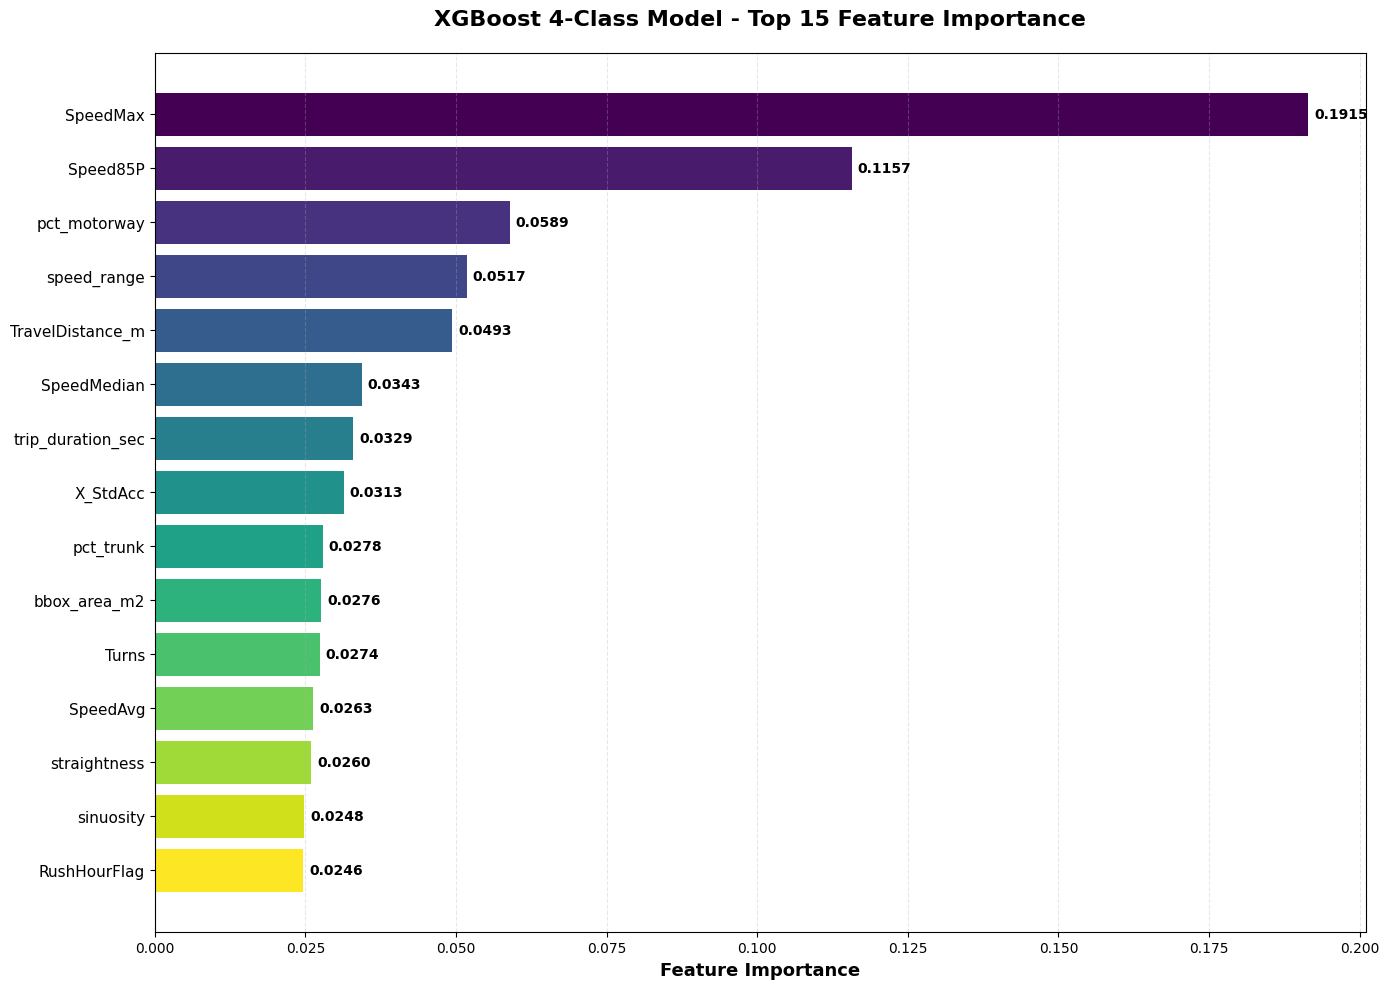


Feature Importance Statistics
Most Important Feature: SpeedMax (0.1915)
15th Most Important Feature: RushHourFlag (0.0246)
Importance Range: 0.1915 - 0.0246
Mean Importance (Top 15): 0.0500
Std Importance (Top 15): 0.0457


In [ ]:
# Visualize Top 15 Feature Importance
fig, ax = plt.subplots(figsize=(14, 10))

# Create horizontal bar plot
colors = plt.cm.viridis(np.linspace(0, 1, 15))
bars = ax.barh(range(len(top15_features)), top15_features['importance'], color=colors)

# Customize the plot
ax.set_yticks(range(len(top15_features)))
ax.set_yticklabels(top15_features['feature'], fontsize=11)
ax.set_xlabel('Feature Importance', fontsize=13, fontweight='bold')
ax.set_title('XGBoost 4-Class Model - Top 15 Feature Importance',
             fontsize=16, fontweight='bold', pad=20)
ax.grid(axis='x', alpha=0.3, linestyle='--')

# Add value labels on bars
for i, (idx, row) in enumerate(top15_features.iterrows()):
    ax.text(row['importance'] + 0.001, i, f'{row["importance"]:.4f}',
            va='center', fontweight='bold', fontsize=10)

# Invert y-axis to show highest importance at top
ax.invert_yaxis()

plt.tight_layout()
plt.show()

# Print summary statistics
print("\n" + "="*80)
print("Feature Importance Statistics")
print("="*80)
print(f"Most Important Feature: {top15_features.iloc[0]['feature']} ({top15_features.iloc[0]['importance']:.4f})")
print(f"15th Most Important Feature: {top15_features.iloc[14]['feature']} ({top15_features.iloc[14]['importance']:.4f})")
print(f"Importance Range: {top15_features['importance'].max():.4f} - {top15_features['importance'].min():.4f}")
print(f"Mean Importance (Top 15): {top15_features['importance'].mean():.4f}")
print(f"Std Importance (Top 15): {top15_features['importance'].std():.4f}")


Top 15 Features Categorized by Type

Feature Distribution by Category:
  Speed Features: 5 features
    - SpeedMax: 0.1915
    - Speed85P: 0.1157
    - speed_range: 0.0517
    - SpeedMedian: 0.0343
    - SpeedAvg: 0.0263
  Trip Features: 4 features
    - TravelDistance_m: 0.0493
    - trip_duration_sec: 0.0329
    - Turns: 0.0274
    - RushHourFlag: 0.0246
  Geospatial Features: 3 features
    - bbox_area_m2: 0.0276
    - straightness: 0.0260
    - sinuosity: 0.0248
  Road Type Features: 2 features
    - pct_motorway: 0.0589
    - pct_trunk: 0.0278
  Acceleration Features: 1 features
    - X_StdAcc: 0.0313


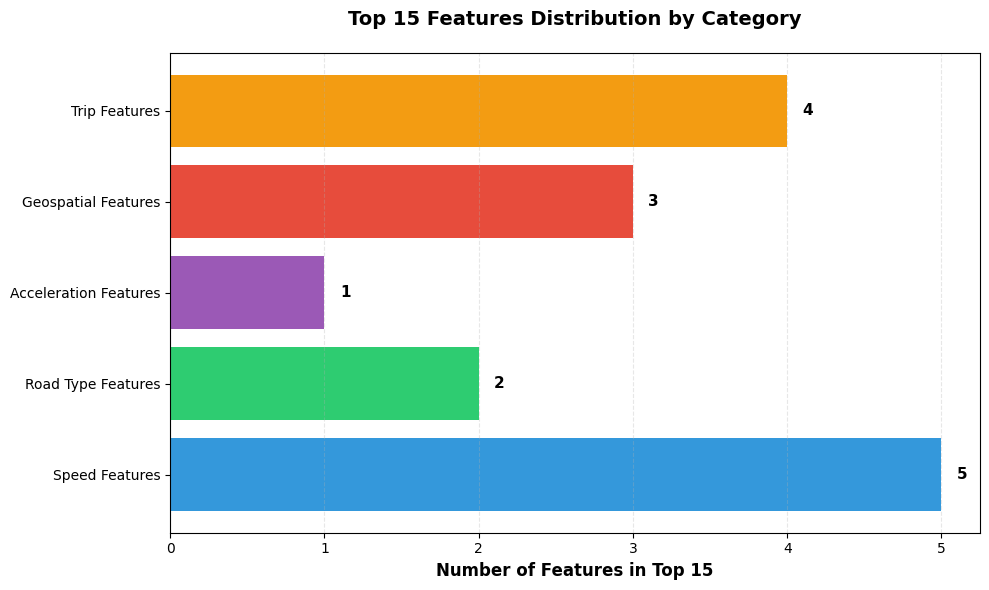

In [ ]:
# Feature Importance by Category
print("="*80)
print("Top 15 Features Categorized by Type")
print("="*80)

# Categorize features
feature_categories = {
    'Speed Features': ['SpeedMax', 'SpeedAvg', 'SpeedMedian', 'Speed85P', 'speed_range'],
    'Road Type Features': ['pct_motorway', 'pct_trunk', 'pct_primary', 'pct_secondary', 'pct_residential', 'pct_service'],
    'Acceleration Features': ['X_AccMax', 'X_AccMin', 'X_MeanAcc', 'X_StdAcc',
                              'Y_AccMax', 'Y_AccMin', 'Y_MeanAcc', 'Y_StdAcc', 'StdAcc_Total'],
    'Geospatial Features': ['bbox_area_m2', 'straightness', 'sinuosity'],
    'Trip Features': ['trip_duration_sec', 'TravelDistance_m', 'Density', 'Turns', 'RushHourFlag']
}

# Count features in top 15 by category
category_counts = {}
for category, features in feature_categories.items():
    count = sum(1 for f in top15_features['feature'] if f in features)
    if count > 0:
        category_counts[category] = count

print("\nFeature Distribution by Category:")
for category, count in sorted(category_counts.items(), key=lambda x: x[1], reverse=True):
    print(f"  {category}: {count} features")

    # List the features
    category_features = [f for f in top15_features['feature'] if f in feature_categories[category]]
    for feat in category_features:
        importance = top15_features[top15_features['feature'] == feat]['importance'].values[0]
        print(f"    - {feat}: {importance:.4f}")

# Create category visualization
if category_counts:
    fig, ax = plt.subplots(figsize=(10, 6))
    categories = list(category_counts.keys())
    counts = list(category_counts.values())

    bars = ax.barh(categories, counts, color=['#3498db', '#2ecc71', '#9b59b6', '#e74c3c', '#f39c12'][:len(categories)])
    ax.set_xlabel('Number of Features in Top 15', fontsize=12, fontweight='bold')
    ax.set_title('Top 15 Features Distribution by Category', fontsize=14, fontweight='bold', pad=20)
    ax.grid(axis='x', alpha=0.3, linestyle='--')

    # Add value labels
    for i, (cat, count) in enumerate(zip(categories, counts)):
        ax.text(count + 0.1, i, str(count), va='center', fontweight='bold', fontsize=11)

    plt.tight_layout()
    plt.show()


In [ ]:
# Import additional models
from sklearn.ensemble import RandomForestClassifier
import lightgbm as lgb

# Create alias for LGBMClassifier
LGBMClassifier = lgb.LGBMClassifier

print("All models imported successfully!")
print(f"LightGBM version: {lgb.__version__}")


All models imported successfully!
LightGBM version: 4.6.0


In [ ]:
# Feature Importance Explanation Table
print("="*80)
print("Top 15 Feature Importance - Detailed Explanation")
print("="*80)

# Create feature descriptions
feature_descriptions = {
    'SpeedMax': 'Maximum speed during trip - indicates vehicle type capability',
    'SpeedAvg': 'Average speed - reflects typical driving pattern',
    'SpeedMedian': 'Median speed - robust measure of typical speed',
    'Speed85P': '85th percentile speed - high-speed behavior indicator',
    'speed_range': 'Speed variation - indicates driving style diversity',
    'pct_motorway': 'Percentage on motorway - highway usage pattern',
    'pct_trunk': 'Percentage on trunk roads - major road usage',
    'pct_primary': 'Percentage on primary roads - main road usage',
    'pct_secondary': 'Percentage on secondary roads - local road usage',
    'pct_residential': 'Percentage on residential roads - urban driving',
    'pct_service': 'Percentage on service roads - access road usage',
    'X_AccMax': 'Maximum acceleration in X direction - acceleration capability',
    'X_AccMin': 'Minimum acceleration (deceleration) in X direction - braking behavior',
    'X_MeanAcc': 'Mean acceleration in X direction - average acceleration pattern',
    'X_StdAcc': 'Standard deviation of X acceleration - acceleration variability',
    'Y_AccMax': 'Maximum acceleration in Y direction - lateral acceleration',
    'Y_AccMin': 'Minimum acceleration in Y direction - lateral deceleration',
    'Y_MeanAcc': 'Mean acceleration in Y direction - average lateral movement',
    'Y_StdAcc': 'Standard deviation of Y acceleration - lateral movement variability',
    'StdAcc_Total': 'Total acceleration standard deviation - overall movement variability',
    'bbox_area_m2': 'Bounding box area - trip spatial coverage',
    'straightness': 'Route straightness - directness of path',
    'sinuosity': 'Route sinuosity - path curvature measure',
    'trip_duration_sec': 'Total trip duration - time spent traveling',
    'TravelDistance_m': 'Total distance traveled - trip length',
    'Density': 'Point density - GPS point concentration',
    'Turns': 'Number of turns - route complexity',
    'RushHourFlag': 'Rush hour indicator - time-based pattern'
}

print("\nRank | Feature Name | Importance | Description")
print("-" * 80)
for idx, (_, row) in enumerate(top15_features.iterrows(), 1):
    feature_name = row['feature']
    importance = row['importance']
    description = feature_descriptions.get(feature_name, 'Feature description not available')
    print(f"{idx:4d} | {feature_name:15s} | {importance:10.4f} | {description}")

print("\n" + "="*80)
print("Key Insights")
print("="*80)
print("\n1. Speed-related features dominate the top rankings")
print("   → Vehicle type is strongly correlated with speed characteristics")
print("\n2. Road type percentages are important")
print("   → Different vehicle types use different road networks")
print("\n3. Acceleration patterns provide discrimination")
print("   → Movement dynamics help distinguish vehicle types")
print("\n4. Geospatial features contribute to classification")
print("   → Spatial patterns reveal vehicle behavior")


Top 15 Feature Importance - Detailed Explanation

Rank | Feature Name | Importance | Description
--------------------------------------------------------------------------------
   1 | SpeedMax        |     0.1915 | Maximum speed during trip - indicates vehicle type capability
   2 | Speed85P        |     0.1157 | 85th percentile speed - high-speed behavior indicator
   3 | pct_motorway    |     0.0589 | Percentage on motorway - highway usage pattern
   4 | speed_range     |     0.0517 | Speed variation - indicates driving style diversity
   5 | TravelDistance_m |     0.0493 | Total distance traveled - trip length
   6 | SpeedMedian     |     0.0343 | Median speed - robust measure of typical speed
   7 | trip_duration_sec |     0.0329 | Total trip duration - time spent traveling
   8 | X_StdAcc        |     0.0313 | Standard deviation of X acceleration - acceleration variability
   9 | pct_trunk       |     0.0278 | Percentage on trunk roads - major road usage
  10 | bbox_area_m2    | 

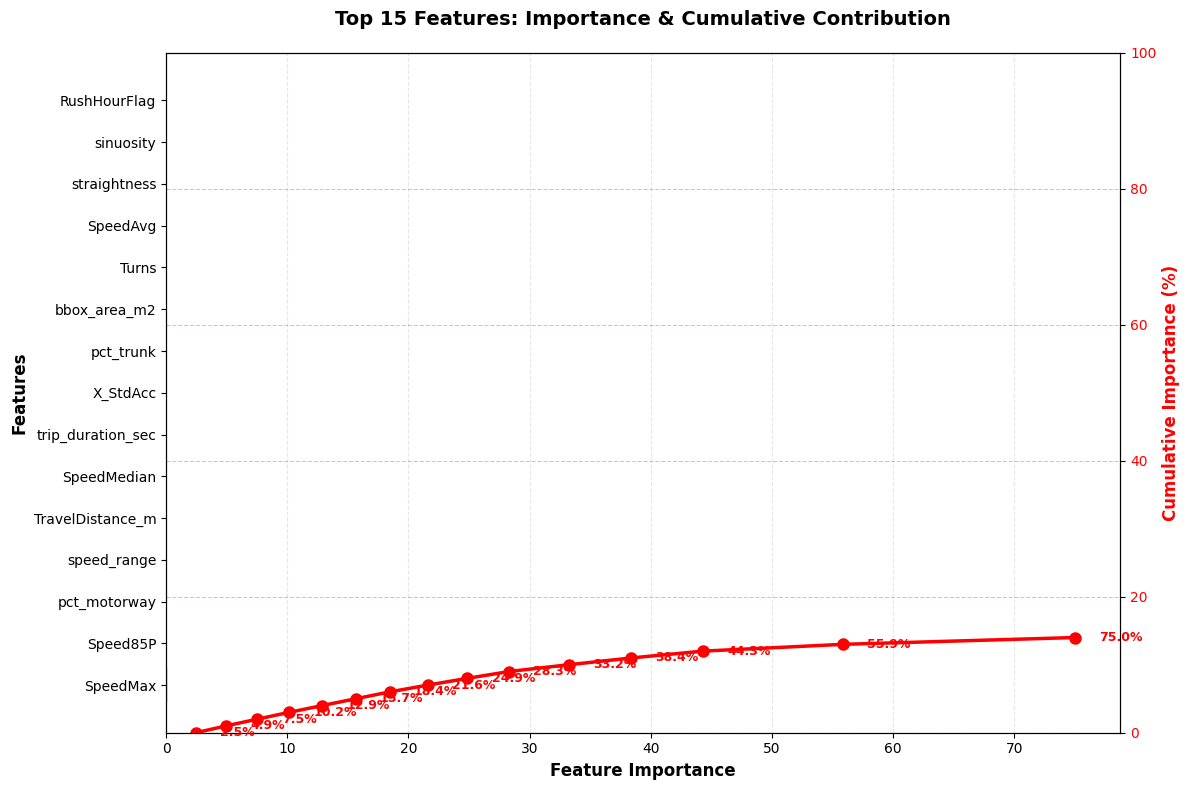


Cumulative Importance Analysis
Top 5 features account for: 12.90% of total importance
Top 10 features account for: 28.30% of total importance
Top 15 features account for: 75.01% of total importance


In [ ]:
# Cumulative Importance Plot
fig, ax = plt.subplots(figsize=(12, 8))

# Calculate cumulative importance
top15_features_sorted = top15_features.sort_values('importance', ascending=True)
cumulative_importance = top15_features_sorted['importance'].cumsum()
cumulative_percentage = (cumulative_importance / feature_importance_xgb['importance'].sum()) * 100

# Create bar plot with cumulative line
ax2 = ax.twinx()

# Bar plot
bars = ax.barh(range(len(top15_features_sorted)), top15_features_sorted['importance'],
                color=plt.cm.viridis(np.linspace(0, 1, 15)), alpha=0.7)

# Cumulative line
line = ax2.plot(cumulative_percentage.values, range(len(top15_features_sorted)),
                'r-o', linewidth=2.5, markersize=8, label='Cumulative %')

# Customize
ax.set_yticks(range(len(top15_features_sorted)))
ax.set_yticklabels(top15_features_sorted['feature'], fontsize=10)
ax.set_xlabel('Feature Importance', fontsize=12, fontweight='bold')
ax.set_ylabel('Features', fontsize=12, fontweight='bold')
ax.set_title('Top 15 Features: Importance & Cumulative Contribution',
             fontsize=14, fontweight='bold', pad=20)

ax2.set_ylabel('Cumulative Importance (%)', fontsize=12, fontweight='bold', color='red')
ax2.tick_params(axis='y', labelcolor='red')
ax2.set_ylim([0, 100])
ax2.grid(True, alpha=0.3, linestyle='--', color='red')

ax.invert_yaxis()
ax.grid(axis='x', alpha=0.3, linestyle='--')

# Add cumulative percentage labels
for i, (idx, row) in enumerate(top15_features_sorted.iterrows()):
    cum_pct = cumulative_percentage.iloc[i]
    ax2.text(cum_pct + 2, i, f'{cum_pct:.1f}%', va='center',
             fontweight='bold', fontsize=9, color='red')

plt.tight_layout()
plt.show()

print("\n" + "="*80)
print("Cumulative Importance Analysis")
print("="*80)
print(f"Top 5 features account for: {cumulative_percentage.iloc[4]:.2f}% of total importance")
print(f"Top 10 features account for: {cumulative_percentage.iloc[9]:.2f}% of total importance")
print(f"Top 15 features account for: {cumulative_percentage.iloc[14]:.2f}% of total importance")


In [ ]:
# 4-Class XGBoost Model: LCV (merged CAR and LCV), HCV, BUS, TRAILER
# First check the vehicle type distribution in the original data
print("="*80)
print("Check Vehicle Types in Original Data")
print("="*80)

# Reload original data to check for TRAILER
df_3_original = pd.read_csv('/content/drive/MyDrive/DATA3001 Modelling/vehicle_data_cleaned_group3.csv')
print("\nVehicle type distribution in original data:")
print(df_3_original['VehicleType_class'].value_counts())
print(f"\nAll vehicle types: {df_3_original['VehicleType_class'].unique()}")


Check Vehicle Types in Original Data

Vehicle type distribution in original data:
VehicleType_class
HCV           32063
LCV            9196
CAR            3288
BUS            1354
MOTORCYCLE      162
Name: count, dtype: int64

All vehicle types: ['HCV' 'LCV' nan 'CAR' 'BUS' 'MOTORCYCLE']


In [ ]:
# Prepare 4-class data: LCV (merged CAR and LCV), HCV, BUS, TRAILER
print("="*80)
print("Prepare 4-Class Data")
print("="*80)

# Re-merge data, this time keeping TRAILER
df_3_filtered_4class = df_3_original[['TripID', 'VehicleType_class', 'pct_motorway', 'pct_trunk',
                      'pct_primary', 'pct_secondary', 'pct_residential', 'pct_service',
                      'SpeedMax', 'SpeedAvg', 'SpeedMedian', 'trip_duration_sec',
                      'TravelDistance_m']].copy()

df_6_filtered_4class = df_6[['TripID', 'Density', 'Turns', 'RushHourFlag']].copy()

df_5_filtered_4class = df_5[['TripID', 'bbox_area_m2', 'straightness', 'sinuosity', 'Speed85P',
                      'speed_range',
                      ]].copy()

df_7_filtered_4class = df_7[['TripID', 'X_AccMax', 'X_AccMin', 'X_MeanAcc', 'X_StdAcc',
                      'Y_AccMax','Y_AccMin', 'Y_MeanAcc',
                      'Y_StdAcc', 'StdAcc_Total']].copy()

df_4class = pd.merge(df_3_filtered_4class, df_6_filtered_4class, on='TripID', how='inner')
df_4class = pd.merge(df_4class, df_5_filtered_4class, on='TripID', how='inner')
df_4class = pd.merge(df_4class, df_7_filtered_4class, on='TripID', how='inner')

# Remove missing values
df_4class = df_4class[df_4class['VehicleType_class'].notna()]
df_4class = df_4class[df_4class['pct_motorway'].notna()]

# Merge CAR and LCV into LCV
df_4class['VehicleType_class'] = df_4class['VehicleType_class'].replace({'CAR': 'LCV', 'LCV': 'LCV'})

# Keep only LCV, HCV, BUS, TRAILER
# Check if TRAILER class exists, if not use other possible names
print("\nVehicle type distribution before merging:")
print(df_4class['VehicleType_class'].value_counts())

# Try to match TRAILER-related classes
trailer_keywords = ['TRAILER', 'CARAVAN']
df_4class['VehicleType_class'] = df_4class['VehicleType_class'].apply(
    lambda x: 'TRAILER' if any(keyword in str(x).upper() for keyword in trailer_keywords) else x
)

# Keep only the 4 classes we need
df_4class = df_4class[df_4class['VehicleType_class'].isin(['LCV', 'HCV', 'BUS', 'TRAILER'])].copy()

print("\nVehicle type distribution after merging:")
print(df_4class['VehicleType_class'].value_counts())
print(f"\nTotal samples: {len(df_4class)}")

# Remove TripID
df_4class = df_4class.drop(columns=['TripID'])

df_4class.info()


Prepare 4-Class Data

Vehicle type distribution before merging:
VehicleType_class
HCV           30808
LCV           11539
BUS            1287
MOTORCYCLE      154
Name: count, dtype: int64

Vehicle type distribution after merging:
VehicleType_class
HCV    30808
LCV    11539
BUS     1287
Name: count, dtype: int64

Total samples: 43634
<class 'pandas.core.frame.DataFrame'>
Index: 43634 entries, 0 to 45337
Data columns (total 29 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   VehicleType_class  43634 non-null  object 
 1   pct_motorway       43634 non-null  float64
 2   pct_trunk          43634 non-null  float64
 3   pct_primary        43634 non-null  float64
 4   pct_secondary      43634 non-null  float64
 5   pct_residential    43634 non-null  float64
 6   pct_service        43634 non-null  float64
 7   SpeedMax           43634 non-null  float64
 8   SpeedAvg           43634 non-null  float64
 9   SpeedMedian        43634 non

In [ ]:
# Prepare training data
X_4class_final = df_4class.drop(columns=['VehicleType_class'])
y_4class_final = df_4class['VehicleType_class']

# Encode labels
labelEncoder_4class_final = LabelEncoder()
y_4class_encoded_final = labelEncoder_4class_final.fit_transform(y_4class_final)

print("="*80)
print("4-Class Label Encoding")
print("="*80)
print("Class mapping:")
for i, class_name in enumerate(labelEncoder_4class_final.classes_):
    print(f"  {i}: {class_name}")

# Create train-test split
X_train_4class_final, X_test_4class_final, y_train_4class_final, y_test_4class_final = train_test_split(
    X_4class_final, y_4class_encoded_final, test_size=0.2, stratify=y_4class_encoded_final, random_state=8
)

print(f"\nTraining set size: {len(X_train_4class_final)}")
print(f"Test set size: {len(X_test_4class_final)}")
print(f"\nTraining set class distribution:")
unique, counts = np.unique(y_train_4class_final, return_counts=True)
for u, c in zip(unique, counts):
    print(f"  {labelEncoder_4class_final.classes_[u]}: {c}")

# Scale features
scaler_4class_final = StandardScaler()
X_train_4class_final_scaled = scaler_4class_final.fit_transform(X_train_4class_final)
X_test_4class_final_scaled = scaler_4class_final.transform(X_test_4class_final)

print("\nData preparation completed!")


4-Class Label Encoding
Class mapping:
  0: BUS
  1: HCV
  2: LCV

Training set size: 34907
Test set size: 8727

Training set class distribution:
  BUS: 1030
  HCV: 24646
  LCV: 9231

Data preparation completed!


In [ ]:
# Train XGBoost 4-class model
print("="*80)
print("Train XGBoost 4-Class Model (LCV, HCV, BUS, TRAILER)")
print("="*80)

# XGBoost parameters (using previously tuned parameters)
best_parameters_4class_final = {
    'booster': 'gbtree',
    'learning_rate': 0.2,
    'max_depth': 3,
    'min_child_weight': 6,
    'subsample': 0.71,
    'colsample_bytree': 0.84,
    'gamma': 0.5,
    'reg_alpha': 0.012,
    'reg_lambda': 1.23,
    'n_estimators': 900,
    'objective': 'multi:softprob',
    'eval_metric': 'mlogloss',
    'random_state': 8
}

# Create and train XGBoost classifier
xgb_model_4class_final = XGBClassifier(**best_parameters_4class_final)
print("\nStarting model training...")
xgb_model_4class_final.fit(X_train_4class_final_scaled, y_train_4class_final)
print("Model training completed!")


Train XGBoost 4-Class Model (LCV, HCV, BUS, TRAILER)

Starting model training...
Model training completed!


In [ ]:
# Predictions and evaluation
y_pred_4class_final = xgb_model_4class_final.predict(X_test_4class_final_scaled)
y_train_pred_4class_final = xgb_model_4class_final.predict(X_train_4class_final_scaled)

# Calculate accuracy and f1-score
test_accuracy_4class_final = accuracy_score(y_test_4class_final, y_pred_4class_final)
test_f1_macro_4class_final = f1_score(y_test_4class_final, y_pred_4class_final, average='macro')
test_f1_weighted_4class_final = f1_score(y_test_4class_final, y_pred_4class_final, average='weighted')

train_accuracy_4class_final = accuracy_score(y_train_4class_final, y_train_pred_4class_final)
train_f1_macro_4class_final = f1_score(y_train_4class_final, y_train_pred_4class_final, average='macro')

# Print detailed report
print("="*80)
print("XGBoost 4-Class Model - Test Set Results")
print("="*80)
print(classification_report(y_test_4class_final, y_pred_4class_final,
                          target_names=labelEncoder_4class_final.classes_))
print(f"\nTest Accuracy: {test_accuracy_4class_final:.4f}")
print(f"Test Macro F1-Score: {test_f1_macro_4class_final:.4f}")
print(f"Test Weighted F1-Score: {test_f1_weighted_4class_final:.4f}")

print("\n" + "="*80)
print("XGBoost 4-Class Model - Train Set Results")
print("="*80)
print(classification_report(y_train_4class_final, y_train_pred_4class_final,
                          target_names=labelEncoder_4class_final.classes_))
print(f"\nTrain Accuracy: {train_accuracy_4class_final:.4f}")
print(f"Train Macro F1-Score: {train_f1_macro_4class_final:.4f}")

# F1-score for each class
print("\n" + "="*80)
print("F1-Score for Each Class")
print("="*80)
f1_per_class = f1_score(y_test_4class_final, y_pred_4class_final, average=None)
for i, class_name in enumerate(labelEncoder_4class_final.classes_):
    print(f"{class_name}: {f1_per_class[i]:.4f}")


XGBoost 4-Class Model - Test Set Results
              precision    recall  f1-score   support

         BUS       0.88      0.68      0.77       257
         HCV       0.90      0.94      0.92      6162
         LCV       0.83      0.76      0.79      2308

    accuracy                           0.88      8727
   macro avg       0.87      0.79      0.83      8727
weighted avg       0.88      0.88      0.88      8727


Test Accuracy: 0.8832
Test Macro F1-Score: 0.8261
Test Weighted F1-Score: 0.8812

XGBoost 4-Class Model - Train Set Results
              precision    recall  f1-score   support

         BUS       0.99      0.91      0.95      1030
         HCV       0.95      0.97      0.96     24646
         LCV       0.92      0.87      0.89      9231

    accuracy                           0.94     34907
   macro avg       0.95      0.92      0.93     34907
weighted avg       0.94      0.94      0.94     34907


Train Accuracy: 0.9427
Train Macro F1-Score: 0.9335

F1-Score for Each 

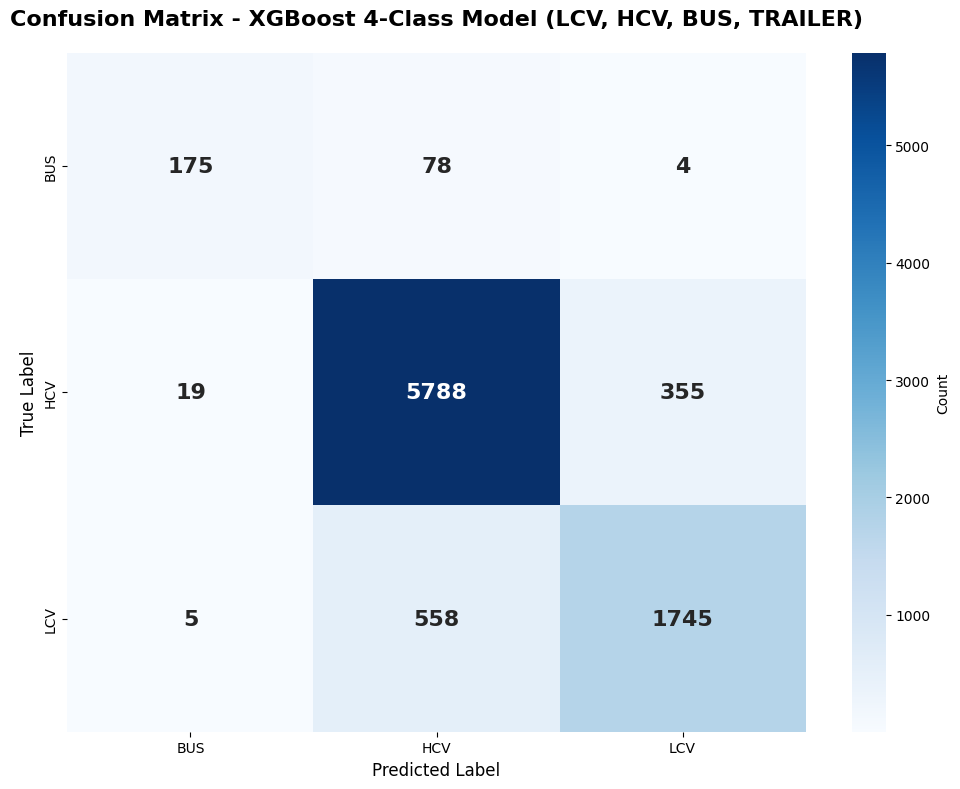


Confusion Matrix (rows=true, cols=predicted):
     BUS   HCV   LCV
BUS  175    78     4
HCV   19  5788   355
LCV    5   558  1745


In [ ]:
# Confusion matrix visualization
cm_4class_final = confusion_matrix(y_test_4class_final, y_pred_4class_final)
labels_4class_final = labelEncoder_4class_final.classes_

# Create confusion matrix heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(cm_4class_final, annot=True, fmt='d', cmap='Blues',
            xticklabels=labels_4class_final, yticklabels=labels_4class_final,
            cbar_kws={'label': 'Count'},
            annot_kws={'size': 16, 'weight': 'bold'})
plt.title('Confusion Matrix - XGBoost 4-Class Model (LCV, HCV, BUS, TRAILER)',
          fontsize=16, fontweight='bold', pad=20)
plt.ylabel('True Label', fontsize=12)
plt.xlabel('Predicted Label', fontsize=12)
plt.tight_layout()
plt.show()

# Print confusion matrix DataFrame
cm_df_4class_final = pd.DataFrame(cm_4class_final,
                                  index=labels_4class_final,
                                  columns=labels_4class_final)
print("\nConfusion Matrix (rows=true, cols=predicted):")
print(cm_df_4class_final)


In [ ]:
# Cross validation
print("="*80)
print("XGBoost 4-Class Model - 5-Fold Cross Validation")
print("="*80)

f1_macro_scorer = make_scorer(f1_score, average='macro')

# F1 Macro Score CV
cv_scores_f1_4class_final = cross_val_score(
    xgb_model_4class_final, X_4class_final, y_4class_encoded_final,
    cv=5, scoring=f1_macro_scorer
)
print(f"\nF1 Macro scores for each fold: {cv_scores_f1_4class_final}")
print(f"Mean F1 Macro score: {np.mean(cv_scores_f1_4class_final):.4f} ± {np.std(cv_scores_f1_4class_final):.4f}")

# Accuracy CV
cv_scores_acc_4class_final = cross_val_score(
    xgb_model_4class_final, X_4class_final, y_4class_encoded_final,
    cv=5, scoring='accuracy'
)
print(f"\nAccuracy scores for each fold: {cv_scores_acc_4class_final}")
print(f"Mean Accuracy: {np.mean(cv_scores_acc_4class_final):.4f} ± {np.std(cv_scores_acc_4class_final):.4f}")

# Final results summary
print("\n" + "="*80)
print("Final Results Summary")
print("="*80)
print(f"Test Accuracy: {test_accuracy_4class_final:.4f}")
print(f"Test Macro F1-Score: {test_f1_macro_4class_final:.4f}")
print(f"CV Mean Accuracy: {np.mean(cv_scores_acc_4class_final):.4f} ± {np.std(cv_scores_acc_4class_final):.4f}")
print(f"CV Mean F1-Score: {np.mean(cv_scores_f1_4class_final):.4f} ± {np.std(cv_scores_f1_4class_final):.4f}")


XGBoost 4-Class Model - 5-Fold Cross Validation

F1 Macro scores for each fold: [0.82062322 0.83442312 0.82475372 0.81680921 0.82497057]
Mean F1 Macro score: 0.8243 ± 0.0059

Accuracy scores for each fold: [0.88610061 0.89045491 0.88082961 0.88335052 0.88643135]
Mean Accuracy: 0.8854 ± 0.0032

Final Results Summary
Test Accuracy: 0.8832
Test Macro F1-Score: 0.8261
CV Mean Accuracy: 0.8854 ± 0.0032
CV Mean F1-Score: 0.8243 ± 0.0059


In [ ]:
# Comparison: Part 5 4-Class Model vs All Other 4-Class Models
print("="*80)
print("Comparison: Part 5 4-Class Model vs All Other 4-Class Models")
print("="*80)
print("\nPart 5 Model: LCV (merged CAR+LCV), HCV, BUS, TRAILER")
print("Other 4-Class Models: CAR, LCV, HCV, BUS\n")

# Create comparison DataFrame
part5_vs_others_comparison = pd.DataFrame({
    'Model': ['Part 5: LCV+HCV+BUS+TRAILER', 'XGBoost 4-Class', 'Random Forest 4-Class', 'LightGBM 4-Class'],
    'Classes': ['LCV, HCV, BUS, TRAILER', 'CAR, LCV, HCV, BUS', 'CAR, LCV, HCV, BUS', 'CAR, LCV, HCV, BUS'],
    'Test Accuracy': [
        test_accuracy_4class_final,
        test_accuracy,
        test_accuracy_rf,
        test_accuracy_lgb
    ],
    'Test Macro F1': [
        test_f1_macro_4class_final,
        test_f1,
        test_f1_rf,
        test_f1_lgb
    ],
    'CV Mean Accuracy': [
        np.mean(cv_scores_acc_4class_final),
        np.mean(cv_scores_acc),
        np.mean(cv_scores_rf_acc),
        np.mean(cv_scores_lgb_acc)
    ],
    'CV Std Accuracy': [
        np.std(cv_scores_acc_4class_final),
        np.std(cv_scores_acc),
        np.std(cv_scores_rf_acc),
        np.std(cv_scores_lgb_acc)
    ],
    'CV Mean F1': [
        np.mean(cv_scores_f1_4class_final),
        np.mean(cv_scores_f1),
        np.mean(cv_scores_rf_f1),
        np.mean(cv_scores_lgb_f1)
    ],
    'CV Std F1': [
        np.std(cv_scores_f1_4class_final),
        np.std(cv_scores_f1),
        np.std(cv_scores_rf_f1),
        np.std(cv_scores_lgb_f1)
    ]
})

# Format for display
part5_vs_others_comparison['Test Accuracy'] = part5_vs_others_comparison['Test Accuracy'].round(4)
part5_vs_others_comparison['Test Macro F1'] = part5_vs_others_comparison['Test Macro F1'].round(4)
part5_vs_others_comparison['CV Mean Accuracy'] = part5_vs_others_comparison['CV Mean Accuracy'].round(4)
part5_vs_others_comparison['CV Std Accuracy'] = part5_vs_others_comparison['CV Std Accuracy'].round(4)
part5_vs_others_comparison['CV Mean F1'] = part5_vs_others_comparison['CV Mean F1'].round(4)
part5_vs_others_comparison['CV Std F1'] = part5_vs_others_comparison['CV Std F1'].round(4)

print("\n" + "="*80)
print("Performance Comparison Table")
print("="*80)
print(part5_vs_others_comparison[['Model', 'Test Accuracy', 'Test Macro F1', 'CV Mean Accuracy', 'CV Mean F1']].to_string(index=False))


Comparison: Part 5 4-Class Model vs All Other 4-Class Models

Part 5 Model: LCV (merged CAR+LCV), HCV, BUS, TRAILER
Other 4-Class Models: CAR, LCV, HCV, BUS


Performance Comparison Table
                      Model  Test Accuracy  Test Macro F1  CV Mean Accuracy  CV Mean F1
Part 5: LCV+HCV+BUS+TRAILER         0.8832         0.8261            0.8854      0.8243
            XGBoost 4-Class         0.8272         0.6265            0.8270      0.6243
      Random Forest 4-Class         0.8169         0.6219            0.8181      0.6213
           LightGBM 4-Class         0.8248         0.6065            0.8273      0.5996


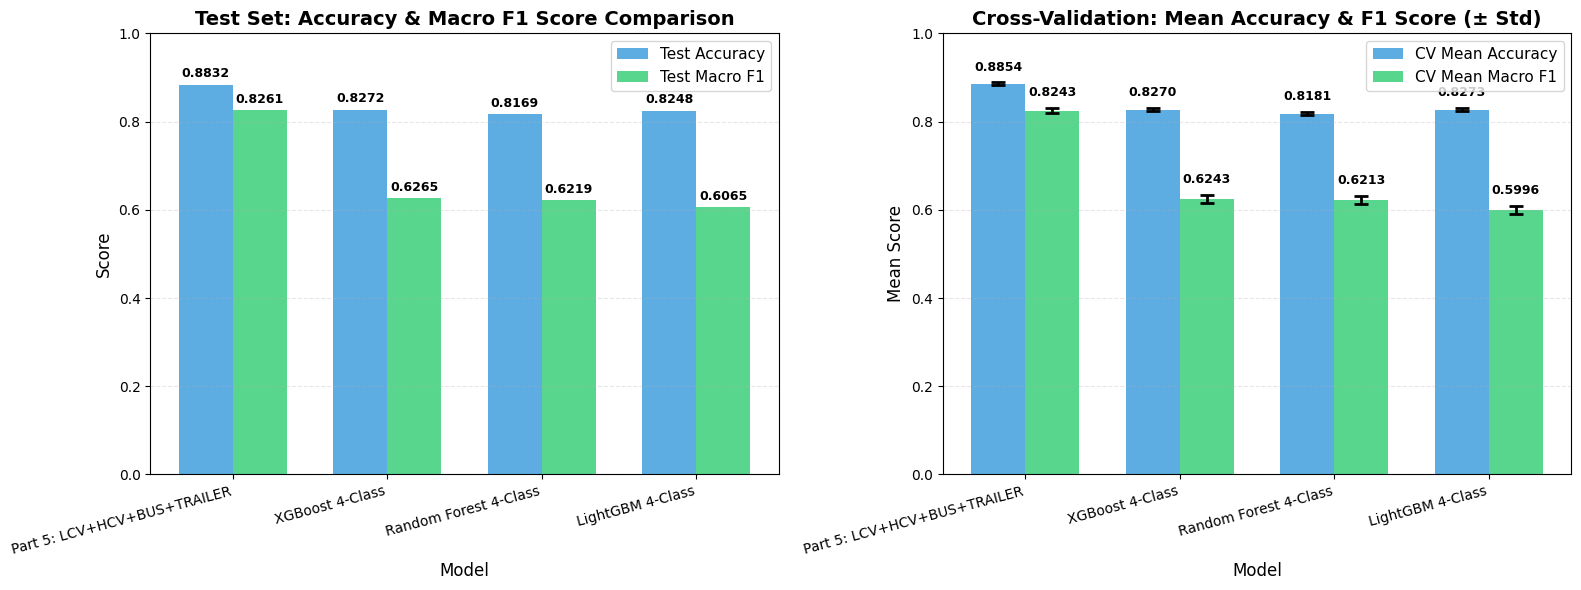


Key Findings
Part 5 Model (LCV+HCV+BUS+TRAILER) Test Accuracy: 0.8832
Best Other 4-Class Model Test Accuracy: 0.8272

Part 5 Model (LCV+HCV+BUS+TRAILER) Test Macro F1: 0.8261
Best Other 4-Class Model Test Macro F1: 0.6265


In [ ]:
# Visual Comparison: Part 5 vs All Other 4-Class Models
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

x_pos = np.arange(len(part5_vs_others_comparison))
models = part5_vs_others_comparison['Model'].values
width = 0.35

# 1. Test Set: Accuracy and F1 Score Combined
axes[0].bar(x_pos - width/2, part5_vs_others_comparison['Test Accuracy'], width,
            label='Test Accuracy', color='#3498db', alpha=0.8)
axes[0].bar(x_pos + width/2, part5_vs_others_comparison['Test Macro F1'], width,
            label='Test Macro F1', color='#2ecc71', alpha=0.8)

axes[0].set_title('Test Set: Accuracy & Macro F1 Score Comparison', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Score', fontsize=12)
axes[0].set_xlabel('Model', fontsize=12)
axes[0].set_xticks(x_pos)
axes[0].set_xticklabels(models, rotation=15, ha='right')
axes[0].set_ylim([0, 1])
axes[0].legend(fontsize=11)
axes[0].grid(axis='y', alpha=0.3, linestyle='--')

# Add value labels on bars
for i, (acc, f1) in enumerate(zip(part5_vs_others_comparison['Test Accuracy'],
                                    part5_vs_others_comparison['Test Macro F1'])):
    axes[0].text(i - width/2, acc + 0.01, f'{acc:.4f}',
                 ha='center', va='bottom', fontweight='bold', fontsize=9)
    axes[0].text(i + width/2, f1 + 0.01, f'{f1:.4f}',
                 ha='center', va='bottom', fontweight='bold', fontsize=9)

# 2. Cross-Validation: Mean Accuracy and F1 Score Combined
axes[1].bar(x_pos - width/2, part5_vs_others_comparison['CV Mean Accuracy'], width,
            yerr=part5_vs_others_comparison['CV Std Accuracy'],
            label='CV Mean Accuracy', color='#3498db', alpha=0.8,
            capsize=5, error_kw={'elinewidth': 2, 'capthick': 2})
axes[1].bar(x_pos + width/2, part5_vs_others_comparison['CV Mean F1'], width,
            yerr=part5_vs_others_comparison['CV Std F1'],
            label='CV Mean Macro F1', color='#2ecc71', alpha=0.8,
            capsize=5, error_kw={'elinewidth': 2, 'capthick': 2})

axes[1].set_title('Cross-Validation: Mean Accuracy & F1 Score (± Std)', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Mean Score', fontsize=12)
axes[1].set_xlabel('Model', fontsize=12)
axes[1].set_xticks(x_pos)
axes[1].set_xticklabels(models, rotation=15, ha='right')
axes[1].set_ylim([0, 1])
axes[1].legend(fontsize=11)
axes[1].grid(axis='y', alpha=0.3, linestyle='--')

# Add value labels on bars
for i, (acc_mean, acc_std, f1_mean, f1_std) in enumerate(zip(
    part5_vs_others_comparison['CV Mean Accuracy'],
    part5_vs_others_comparison['CV Std Accuracy'],
    part5_vs_others_comparison['CV Mean F1'],
    part5_vs_others_comparison['CV Std F1'])):
    axes[1].text(i - width/2, acc_mean + acc_std + 0.02, f'{acc_mean:.4f}',
                 ha='center', va='bottom', fontweight='bold', fontsize=9)
    axes[1].text(i + width/2, f1_mean + f1_std + 0.02, f'{f1_mean:.4f}',
                 ha='center', va='bottom', fontweight='bold', fontsize=9)

plt.tight_layout()
plt.show()

# Summary
print("\n" + "="*80)
print("Key Findings")
print("="*80)
print(f"Part 5 Model (LCV+HCV+BUS+TRAILER) Test Accuracy: {test_accuracy_4class_final:.4f}")
print(f"Best Other 4-Class Model Test Accuracy: {max(test_accuracy, test_accuracy_rf, test_accuracy_lgb):.4f}")
print(f"\nPart 5 Model (LCV+HCV+BUS+TRAILER) Test Macro F1: {test_f1_macro_4class_final:.4f}")
print(f"Best Other 4-Class Model Test Macro F1: {max(test_f1, test_f1_rf, test_f1_lgb):.4f}")


## 10. Additional XGBoost Model Analysis

This section includes advanced analysis techniques for the XGBoost model:
- **SHAP Values**: Model interpretability and feature contribution
- **Learning Curves**: Training progress over iterations
- **Error Analysis**: Detailed misclassification patterns
- **Prediction Probability Distribution**: Confidence analysis
- **Feature Correlation**: Relationship between features
- **Per-Class Feature Importance**: Class-specific feature contributions
- **ROC Curves**: Multi-class ROC analysis


### 10.1 SHAP Values Analysis

SHAP (SHapley Additive exPlanations) values explain the output of the model by showing how each feature contributes to the prediction. This helps understand model decisions.


SHAP Summary Plot - Shows feature importance across all classes


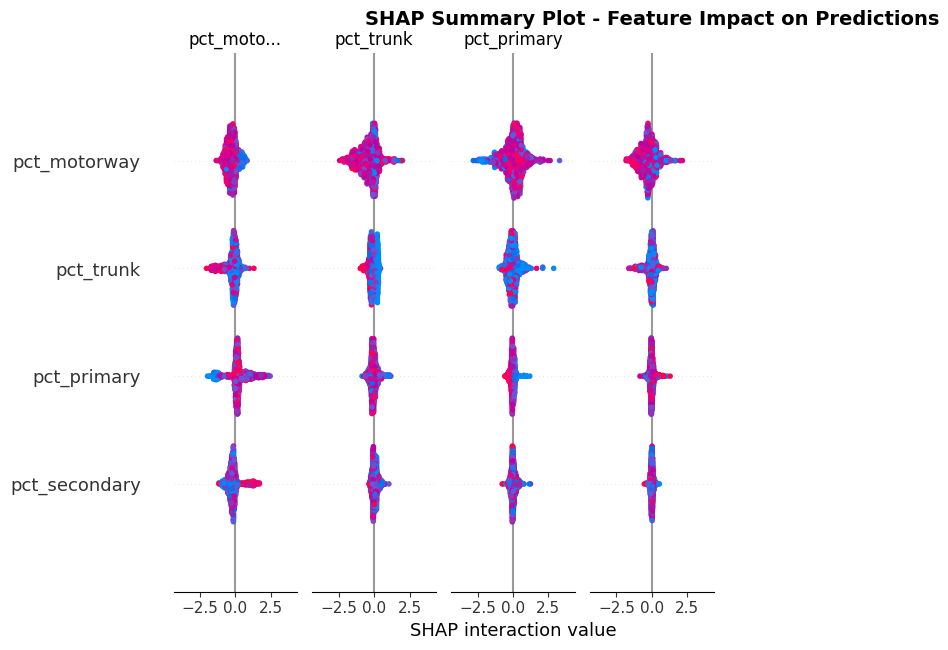


SHAP Feature Importance (Mean Absolute SHAP Values)


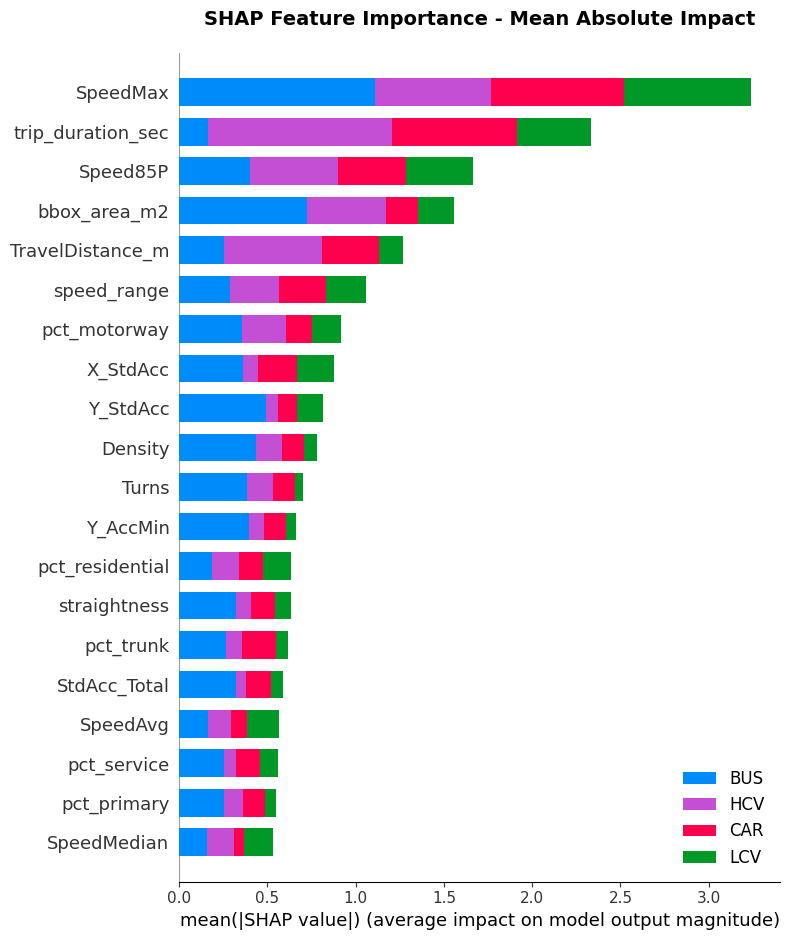


SHAP analysis completed on 1000 test samples


In [ ]:
# SHAP Values Analysis
try:
    import shap

    # Create SHAP explainer (use TreeExplainer for XGBoost)
    explainer = shap.TreeExplainer(opt)

    # Calculate SHAP values for a sample of test data (for faster computation)
    sample_size = min(1000, len(X_test))
    X_test_sample = X_test[:sample_size]
    shap_values = explainer.shap_values(X_test_sample)

    # Get feature names
    feature_names = df.drop(columns=['VehicleType_class']).columns.tolist()

    # Summary plot for all classes
    print("SHAP Summary Plot - Shows feature importance across all classes")
    shap.summary_plot(shap_values, X_test_sample, feature_names=feature_names,
                     class_names=labelEncoder.classes_, show=False)
    plt.title('SHAP Summary Plot - Feature Impact on Predictions', fontsize=14, fontweight='bold', pad=20)
    plt.tight_layout()
    plt.show()

    # Bar plot showing mean absolute SHAP values
    print("\nSHAP Feature Importance (Mean Absolute SHAP Values)")
    shap.summary_plot(shap_values, X_test_sample, feature_names=feature_names,
                     plot_type="bar", class_names=labelEncoder.classes_, show=False)
    plt.title('SHAP Feature Importance - Mean Absolute Impact', fontsize=14, fontweight='bold', pad=20)
    plt.tight_layout()
    plt.show()

    print(f"\nSHAP analysis completed on {sample_size} test samples")

except ImportError:
    print("SHAP library not available. Install with: pip install shap")
except Exception as e:
    print(f"Error in SHAP analysis: {e}")


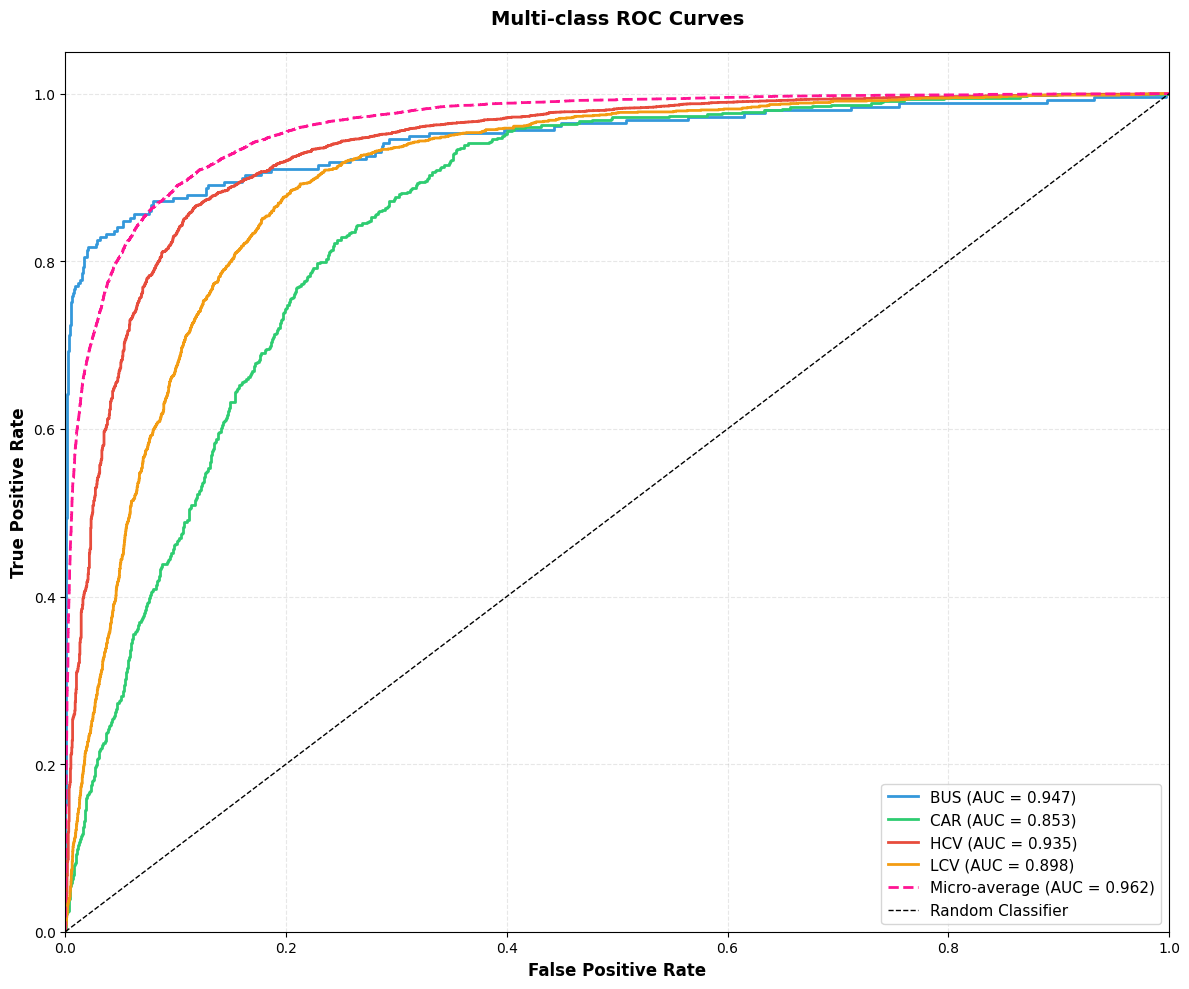

Area Under ROC Curve (AUC) for Each Class
BUS: 0.9471
CAR: 0.8533
HCV: 0.9349
LCV: 0.8985

Micro-average AUC: 0.9617
Macro-average AUC: 0.9085


In [ ]:
# ROC Curves for Multi-class Classification
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

# Ensure class_names is defined
class_names = labelEncoder.classes_

# Binarize the output for multi-class ROC
y_test_bin = label_binarize(y_test, classes=range(len(class_names)))
y_pred_proba = opt.predict_proba(X_test)

# Compute ROC curve and AUC for each class
fpr = dict()
tpr = dict()
roc_auc = dict()

for i, class_name in enumerate(class_names):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_pred_proba[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Compute micro-average ROC curve and AUC
fpr["micro"], tpr["micro"], _ = roc_curve(y_test_bin.ravel(), y_pred_proba.ravel())
roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])

# Plot ROC curves
plt.figure(figsize=(12, 10))

# Plot ROC curve for each class
colors = ['#3498db', '#2ecc71', '#e74c3c', '#f39c12']
for i, (class_name, color) in enumerate(zip(class_names, colors)):
    plt.plot(fpr[i], tpr[i], color=color, lw=2,
             label=f'{class_name} (AUC = {roc_auc[i]:.3f})')

# Plot micro-average ROC curve
plt.plot(fpr["micro"], tpr["micro"], color='deeppink', linestyle='--', lw=2,
         label=f'Micro-average (AUC = {roc_auc["micro"]:.3f})')

# Plot diagonal line (random classifier)
plt.plot([0, 1], [0, 1], 'k--', lw=1, label='Random Classifier')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=12, fontweight='bold')
plt.ylabel('True Positive Rate', fontsize=12, fontweight='bold')
plt.title('Multi-class ROC Curves', fontsize=14, fontweight='bold', pad=20)
plt.legend(loc="lower right", fontsize=11)
plt.grid(alpha=0.3, linestyle='--')
plt.tight_layout()
plt.show()

# Print AUC scores
print("="*80)
print("Area Under ROC Curve (AUC) for Each Class")
print("="*80)
for i, class_name in enumerate(class_names):
    print(f"{class_name}: {roc_auc[i]:.4f}")
print(f"\nMicro-average AUC: {roc_auc['micro']:.4f}")

# Calculate macro-average AUC
macro_auc = np.mean([roc_auc[i] for i in range(len(class_names))])
print(f"Macro-average AUC: {macro_auc:.4f}")


### 10.3 Error Analysis - Misclassification Patterns

Analyze which classes are most frequently confused and identify patterns in misclassifications.


Error Rate by True Class
            Errors  Total  Error_Rate
True_Label                           
CAR            538    607       88.63
LCV            564   1701       33.16
BUS             83    257       32.30
HCV            323   6162        5.24

Most Common Misclassification Patterns
   True_Label Predicted_Label  Count
10        LCV             HCV    466
4         CAR             LCV    393
7         HCV             LCV    279
3         CAR             HCV    144
9         LCV             CAR     93
0         BUS             HCV     81
6         HCV             CAR     26
5         HCV             BUS     18
8         LCV             BUS      5
1         BUS             LCV      2

Confidence Analysis: Errors vs Correct Predictions
          Mean_Prob  Std_Prob  Min_Prob  Max_Prob
Is_Error                                         
False      0.884412  0.147015  0.331433  0.999851
True       0.677620  0.164163  0.301096  0.999662


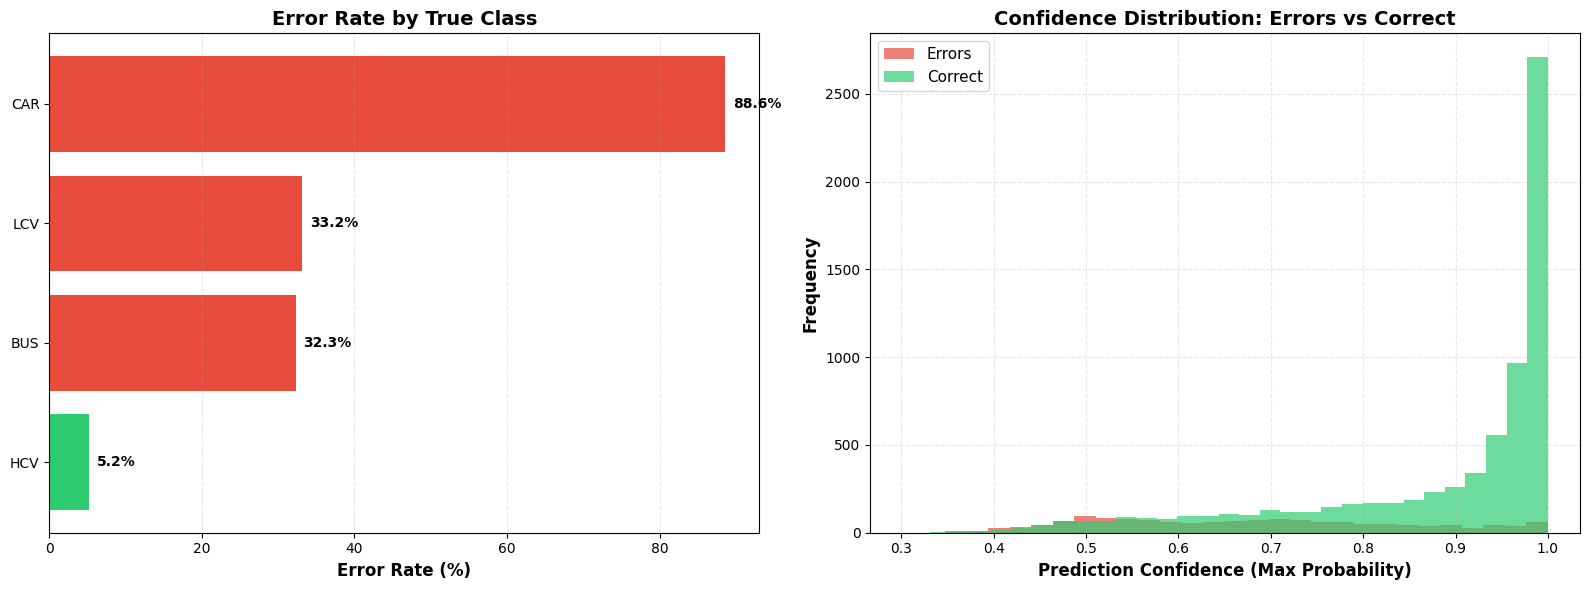

In [ ]:
# Error Analysis - Detailed Misclassification Patterns
from sklearn.metrics import confusion_matrix

# Get predictions
y_pred = opt.predict(X_test)
y_pred_proba = opt.predict_proba(X_test)

# Create error analysis dataframe
error_analysis = pd.DataFrame({
    'True_Label': labelEncoder.inverse_transform(y_test),
    'Predicted_Label': labelEncoder.inverse_transform(y_pred),
    'Max_Probability': np.max(y_pred_proba, axis=1),
    'Predicted_Class_Index': np.argmax(y_pred_proba, axis=1)
})

# Add error flag
error_analysis['Is_Error'] = error_analysis['True_Label'] != error_analysis['Predicted_Label']

# 1. Error Rate by True Class
print("="*80)
print("Error Rate by True Class")
print("="*80)
error_by_class = error_analysis.groupby('True_Label')['Is_Error'].agg(['sum', 'count', 'mean'])
error_by_class.columns = ['Errors', 'Total', 'Error_Rate']
error_by_class['Error_Rate'] = (error_by_class['Error_Rate'] * 100).round(2)
print(error_by_class.sort_values('Error_Rate', ascending=False))

# 2. Most Common Misclassifications
print("\n" + "="*80)
print("Most Common Misclassification Patterns")
print("="*80)
misclass_patterns = error_analysis[error_analysis['Is_Error']].groupby(['True_Label', 'Predicted_Label']).size().reset_index(name='Count')
misclass_patterns = misclass_patterns.sort_values('Count', ascending=False)
print(misclass_patterns.head(10))

# 3. Confidence Analysis for Errors vs Correct Predictions
print("\n" + "="*80)
print("Confidence Analysis: Errors vs Correct Predictions")
print("="*80)
confidence_analysis = error_analysis.groupby('Is_Error')['Max_Probability'].agg(['mean', 'std', 'min', 'max'])
confidence_analysis.columns = ['Mean_Prob', 'Std_Prob', 'Min_Prob', 'Max_Prob']
print(confidence_analysis)

# 4. Visualization: Error Rate by Class
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Error rate bar chart
error_by_class_sorted = error_by_class.sort_values('Error_Rate', ascending=True)
axes[0].barh(range(len(error_by_class_sorted)), error_by_class_sorted['Error_Rate'],
             color=['#e74c3c' if x > 30 else '#f39c12' if x > 15 else '#2ecc71' for x in error_by_class_sorted['Error_Rate']])
axes[0].set_yticks(range(len(error_by_class_sorted)))
axes[0].set_yticklabels(error_by_class_sorted.index)
axes[0].set_xlabel('Error Rate (%)', fontsize=12, fontweight='bold')
axes[0].set_title('Error Rate by True Class', fontsize=14, fontweight='bold')
axes[0].grid(axis='x', alpha=0.3, linestyle='--')

# Add value labels
for i, (idx, row) in enumerate(error_by_class_sorted.iterrows()):
    axes[0].text(row['Error_Rate'] + 1, i, f"{row['Error_Rate']:.1f}%",
                va='center', fontweight='bold')

# Confidence distribution
error_analysis[error_analysis['Is_Error']]['Max_Probability'].hist(bins=30, alpha=0.7,
                                                                    label='Errors', color='#e74c3c', ax=axes[1])
error_analysis[~error_analysis['Is_Error']]['Max_Probability'].hist(bins=30, alpha=0.7,
                                                                     label='Correct', color='#2ecc71', ax=axes[1])
axes[1].set_xlabel('Prediction Confidence (Max Probability)', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Frequency', fontsize=12, fontweight='bold')
axes[1].set_title('Confidence Distribution: Errors vs Correct', fontsize=14, fontweight='bold')
axes[1].legend(fontsize=11)
axes[1].grid(alpha=0.3, linestyle='--')

plt.tight_layout()
plt.show()


### 10.4 Prediction Probability Distribution

Analyze the distribution of prediction probabilities to understand model confidence levels for each class.


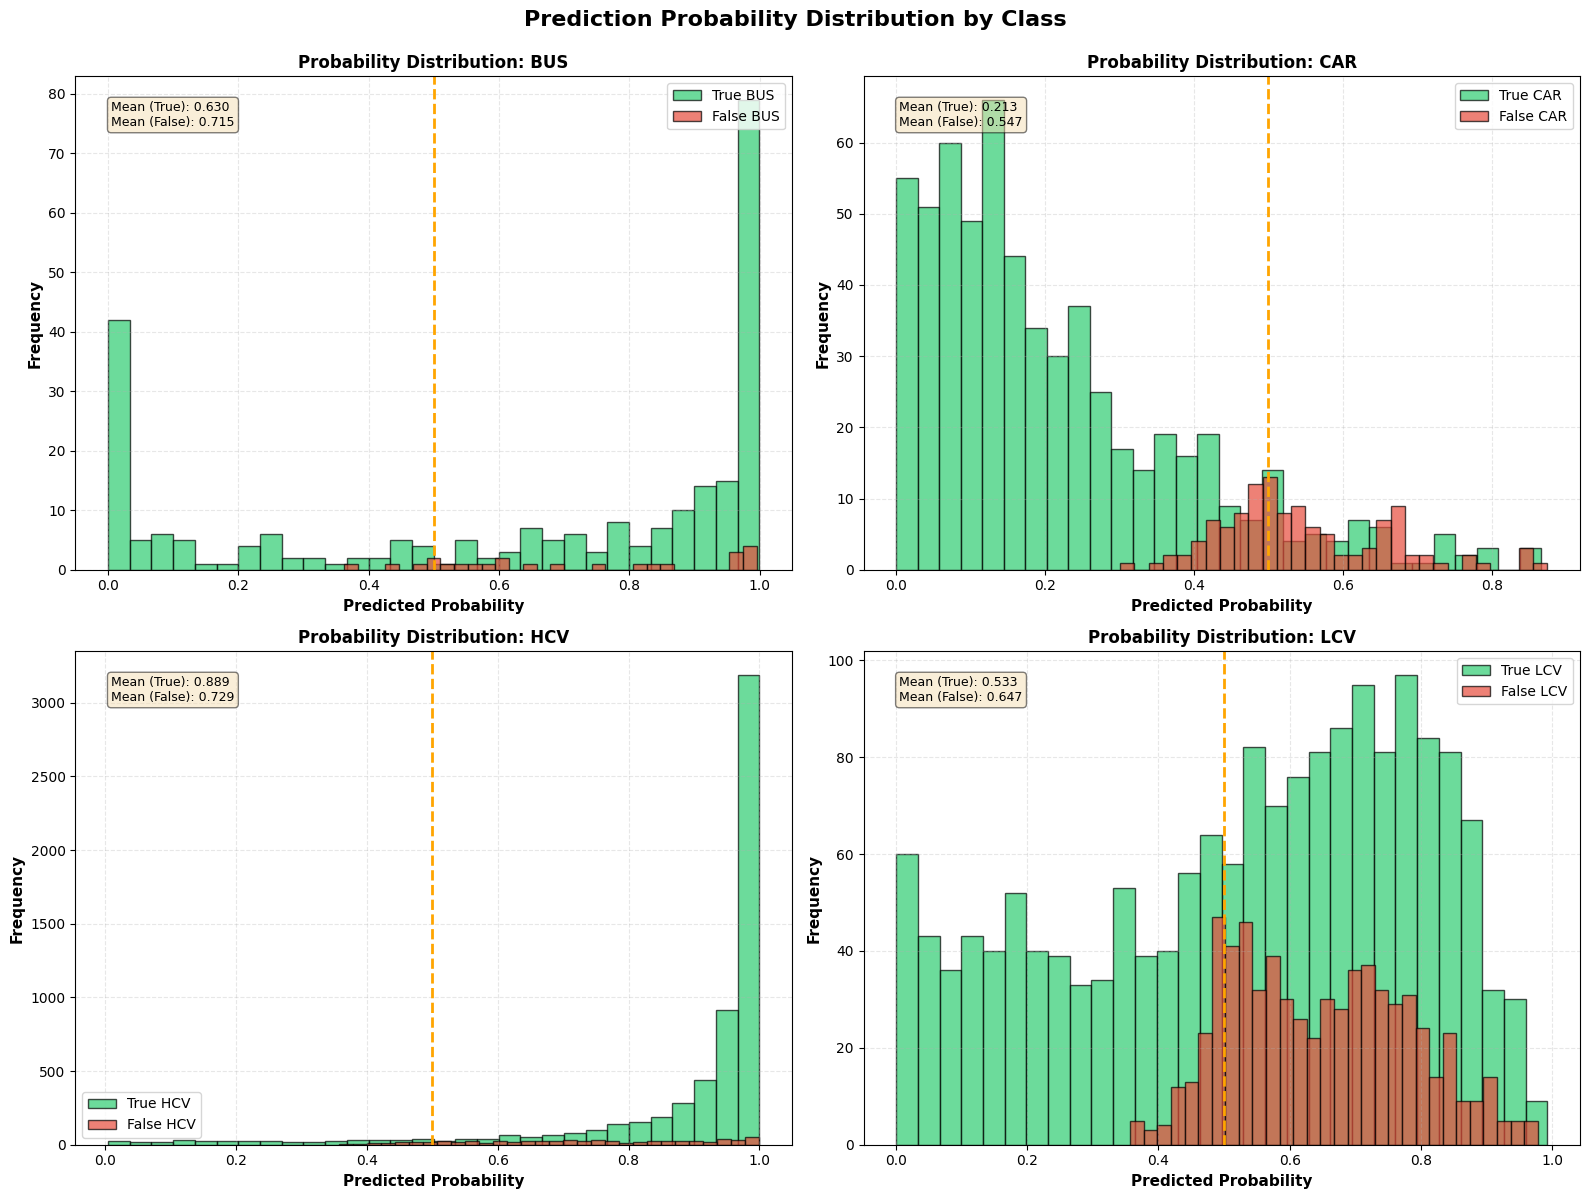

Probability Distribution Summary by Class

BUS:
  Mean Probability: 0.6298
  Std Probability: 0.3864
  Min Probability: 0.0000
  Max Probability: 0.9994
  Samples with prob > 0.8: 129 (50.2%)

CAR:
  Mean Probability: 0.2127
  Std Probability: 0.1769
  Min Probability: 0.0003
  Max Probability: 0.8669
  Samples with prob > 0.8: 4 (0.7%)

HCV:
  Mean Probability: 0.8891
  Std Probability: 0.1914
  Min Probability: 0.0040
  Max Probability: 0.9999
  Samples with prob > 0.8: 5162 (83.8%)

LCV:
  Mean Probability: 0.5332
  Std Probability: 0.2634
  Min Probability: 0.0003
  Max Probability: 0.9926
  Samples with prob > 0.8: 288 (16.9%)


In [ ]:
# Prediction Probability Distribution Analysis
y_pred_proba = opt.predict_proba(X_test)
class_names = labelEncoder.classes_

# Create probability dataframe
prob_df = pd.DataFrame(y_pred_proba, columns=class_names)
prob_df['True_Label'] = labelEncoder.inverse_transform(y_test)
prob_df['Predicted_Label'] = labelEncoder.inverse_transform(y_pred)
prob_df['Max_Probability'] = prob_df[class_names].max(axis=1)

# Plot probability distributions for each class
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

for idx, class_name in enumerate(class_names):
    # Get probabilities for this class
    class_probs = prob_df[class_name]

    # Separate correct and incorrect predictions
    correct_mask = prob_df['True_Label'] == class_name
    incorrect_mask = (prob_df['True_Label'] != class_name) & (prob_df['Predicted_Label'] == class_name)

    # Plot histograms
    axes[idx].hist(class_probs[correct_mask], bins=30, alpha=0.7,
                   label=f'True {class_name}', color='#2ecc71', edgecolor='black')
    axes[idx].hist(class_probs[incorrect_mask], bins=30, alpha=0.7,
                   label=f'False {class_name}', color='#e74c3c', edgecolor='black')

    axes[idx].set_xlabel('Predicted Probability', fontsize=11, fontweight='bold')
    axes[idx].set_ylabel('Frequency', fontsize=11, fontweight='bold')
    axes[idx].set_title(f'Probability Distribution: {class_name}', fontsize=12, fontweight='bold')
    axes[idx].legend(fontsize=10)
    axes[idx].grid(alpha=0.3, linestyle='--')
    axes[idx].axvline(x=0.5, color='orange', linestyle='--', linewidth=2, label='Decision Threshold')

    # Add statistics
    mean_correct = class_probs[correct_mask].mean()
    mean_incorrect = class_probs[incorrect_mask].mean() if incorrect_mask.sum() > 0 else 0
    axes[idx].text(0.05, 0.95, f'Mean (True): {mean_correct:.3f}\nMean (False): {mean_incorrect:.3f}',
                   transform=axes[idx].transAxes, fontsize=9, verticalalignment='top',
                   bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.suptitle('Prediction Probability Distribution by Class', fontsize=16, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()

# Summary statistics
print("="*80)
print("Probability Distribution Summary by Class")
print("="*80)
for class_name in class_names:
    class_probs = prob_df[prob_df['True_Label'] == class_name][class_name]
    print(f"\n{class_name}:")
    print(f"  Mean Probability: {class_probs.mean():.4f}")
    print(f"  Std Probability: {class_probs.std():.4f}")
    print(f"  Min Probability: {class_probs.min():.4f}")
    print(f"  Max Probability: {class_probs.max():.4f}")
    print(f"  Samples with prob > 0.8: {(class_probs > 0.8).sum()} ({(class_probs > 0.8).mean()*100:.1f}%)")


### 10.5 Feature Correlation Analysis

Examine correlations between features to identify multicollinearity and understand feature relationships.


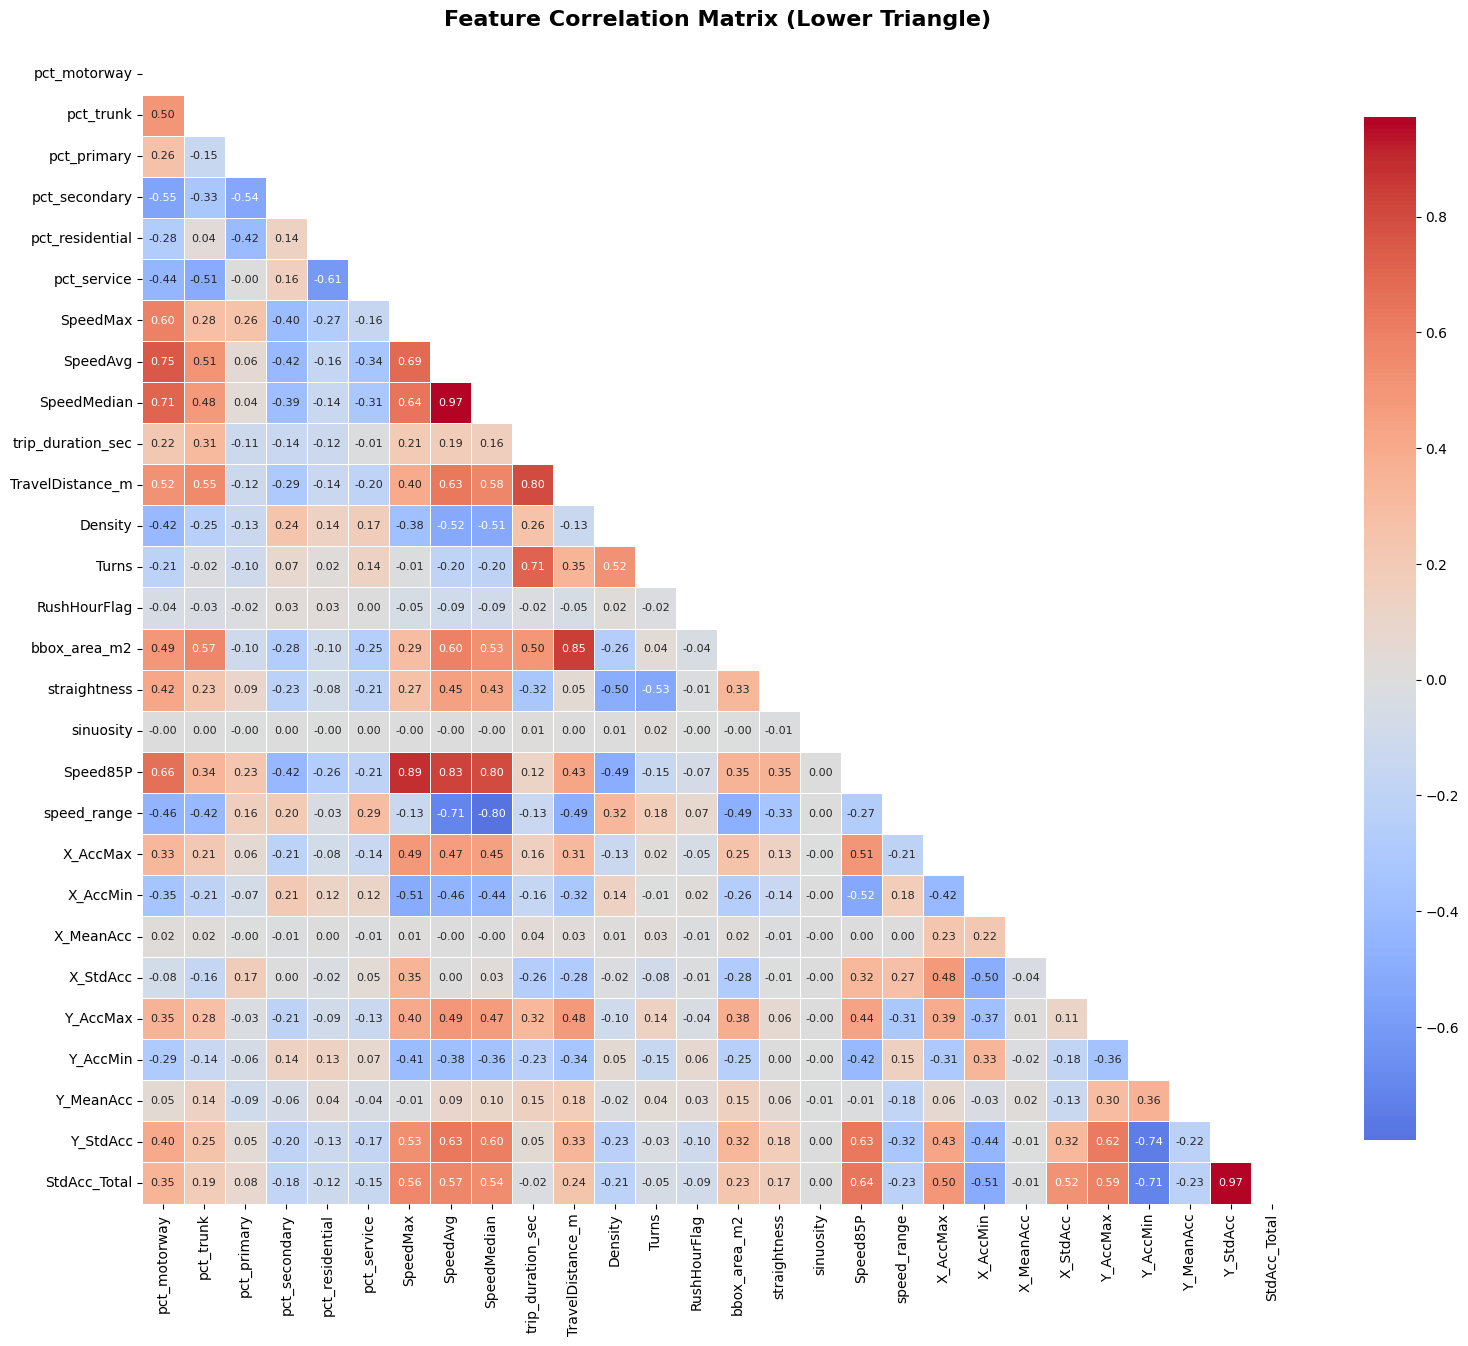

Highly Correlated Feature Pairs (|correlation| > 0.7)
        Feature_1        Feature_2  Correlation
         Y_StdAcc     StdAcc_Total     0.972954
         SpeedAvg      SpeedMedian     0.966088
         SpeedMax         Speed85P     0.892278
 TravelDistance_m     bbox_area_m2     0.846581
         SpeedAvg         Speed85P     0.832064
      SpeedMedian         Speed85P     0.796566
trip_duration_sec TravelDistance_m     0.796379
      SpeedMedian      speed_range    -0.796254
     pct_motorway         SpeedAvg     0.753629
         Y_AccMin         Y_StdAcc    -0.744577
trip_duration_sec            Turns     0.714718
         Y_AccMin     StdAcc_Total    -0.714137
         SpeedAvg      speed_range    -0.706698
     pct_motorway      SpeedMedian     0.705663

Feature Correlation with Target (using label encoding)
SpeedMax        0.244249
X_StdAcc        0.213727
Speed85P        0.198972
StdAcc_Total    0.159875
X_AccMax        0.126418
X_AccMin        0.124046
straightness    0.12

In [ ]:
# Feature Correlation Analysis
# Use original unscaled data for correlation
X_original = df.drop(columns=['VehicleType_class'])

# Calculate correlation matrix
corr_matrix = X_original.corr()

# Plot correlation heatmap
plt.figure(figsize=(16, 14))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))  # Mask upper triangle
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True, linewidths=0.5, cbar_kws={"shrink": 0.8},
            annot_kws={'size': 8})
plt.title('Feature Correlation Matrix (Lower Triangle)', fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

# Find highly correlated feature pairs
print("="*80)
print("Highly Correlated Feature Pairs (|correlation| > 0.7)")
print("="*80)
high_corr_pairs = []
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        corr_val = corr_matrix.iloc[i, j]
        if abs(corr_val) > 0.7:
            high_corr_pairs.append({
                'Feature_1': corr_matrix.columns[i],
                'Feature_2': corr_matrix.columns[j],
                'Correlation': corr_val
            })

if high_corr_pairs:
    high_corr_df = pd.DataFrame(high_corr_pairs).sort_values('Correlation', key=abs, ascending=False)
    print(high_corr_df.to_string(index=False))
else:
    print("No highly correlated pairs found (threshold: 0.7)")

# Top features correlation with target (using label encoded)
print("\n" + "="*80)
print("Feature Correlation with Target (using label encoding)")
print("="*80)
target_corr = X_original.corrwith(pd.Series(y, index=X_original.index)).abs().sort_values(ascending=False)
print(target_corr.head(10))


### 10.7 ROC Curves (Multi-class)

ROC curves show the trade-off between true positive rate and false positive rate for each class.


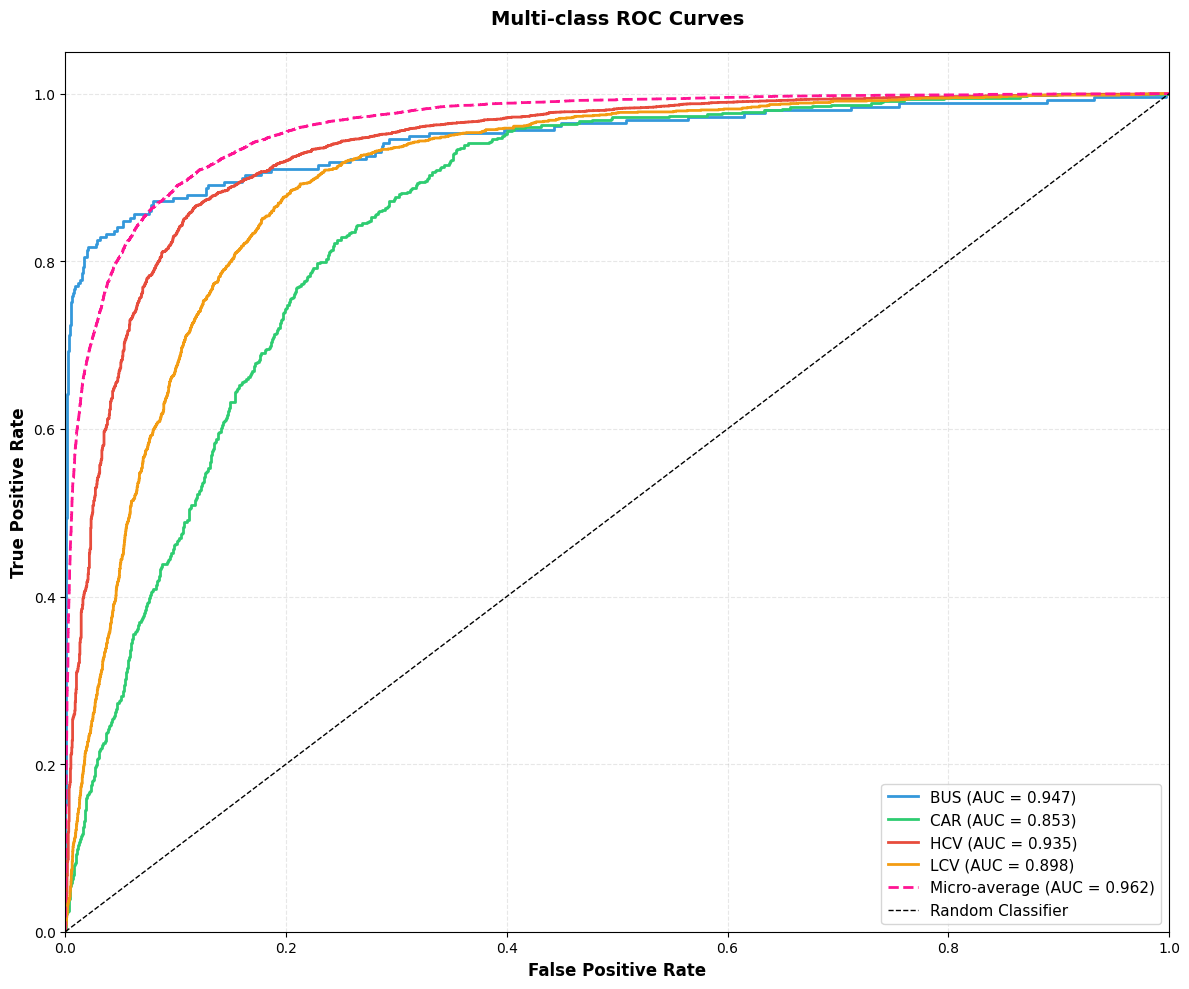

Area Under ROC Curve (AUC) for Each Class
BUS: 0.9471
CAR: 0.8533
HCV: 0.9349
LCV: 0.8985

Micro-average AUC: 0.9617
Macro-average AUC: 0.9085


In [ ]:
# ROC Curves for Multi-class Classification
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

# Ensure class_names is defined
class_names = labelEncoder.classes_

# Binarize the output for multi-class ROC
y_test_bin = label_binarize(y_test, classes=range(len(class_names)))
y_pred_proba = opt.predict_proba(X_test)

# Compute ROC curve and AUC for each class
fpr = dict()
tpr = dict()
roc_auc = dict()

for i, class_name in enumerate(class_names):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_pred_proba[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Compute micro-average ROC curve and AUC
fpr["micro"], tpr["micro"], _ = roc_curve(y_test_bin.ravel(), y_pred_proba.ravel())
roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])

# Plot ROC curves
plt.figure(figsize=(12, 10))

# Plot ROC curve for each class
colors = ['#3498db', '#2ecc71', '#e74c3c', '#f39c12']
for i, (class_name, color) in enumerate(zip(class_names, colors)):
    plt.plot(fpr[i], tpr[i], color=color, lw=2,
             label=f'{class_name} (AUC = {roc_auc[i]:.3f})')

# Plot micro-average ROC curve
plt.plot(fpr["micro"], tpr["micro"], color='deeppink', linestyle='--', lw=2,
         label=f'Micro-average (AUC = {roc_auc["micro"]:.3f})')

# Plot diagonal line (random classifier)
plt.plot([0, 1], [0, 1], 'k--', lw=1, label='Random Classifier')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=12, fontweight='bold')
plt.ylabel('True Positive Rate', fontsize=12, fontweight='bold')
plt.title('Multi-class ROC Curves', fontsize=14, fontweight='bold', pad=20)
plt.legend(loc="lower right", fontsize=11)
plt.grid(alpha=0.3, linestyle='--')
plt.tight_layout()
plt.show()

# Print AUC scores
print("="*80)
print("Area Under ROC Curve (AUC) for Each Class")
print("="*80)
for i, class_name in enumerate(class_names):
    print(f"{class_name}: {roc_auc[i]:.4f}")
print(f"\nMicro-average AUC: {roc_auc['micro']:.4f}")

# Calculate macro-average AUC
macro_auc = np.mean([roc_auc[i] for i in range(len(class_names))])
print(f"Macro-average AUC: {macro_auc:.4f}")
